In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *
import sciplotlib.style as spstyle
from matplotlib.lines import Line2D
plt.style.use('default')
plt.rcParams['font.weight'] = 'normal' 
plt.rcParams['font.family'] = 'Arial' 
plt.rcParams['pdf.fonttype'] = 42

L1 = read_parameters("/data1/DATA_Duplat/Brut/PDF/PD5n1")[0]
L2 = read_parameters("/data1/DATA_Duplat/Brut/PDF/PD5n1")[1]

lengthtab = L1 * L2
nbins = 100
Tnmin = np.array([5,8, 8,8,7,7,7, 8,8,8,8, 8, 8, 8,8])
Tnmax = np.array([80,45,50,50,50,50,50, 80,80,80,80,80,80,80])
fnb = np.arange(1,15)
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
Tvar = [read_parameters(folder)[2] for folder in folderpath]

print(Tvar)

color_list = ['#0072b2', '#009e73', '#e69f00', '#d55e00','#f0e442',
              '#cc79a7', '#56b4e9', '#000000']

[0.0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.06, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]


In [7]:
def powercutoff_fit(x, a, b, c, d):
    return a * x **(-b) * np.exp(-(x / c) ** d)


#  Figures pour papier OFC_PhysRev

#  Figure 1

##  Version Nature review

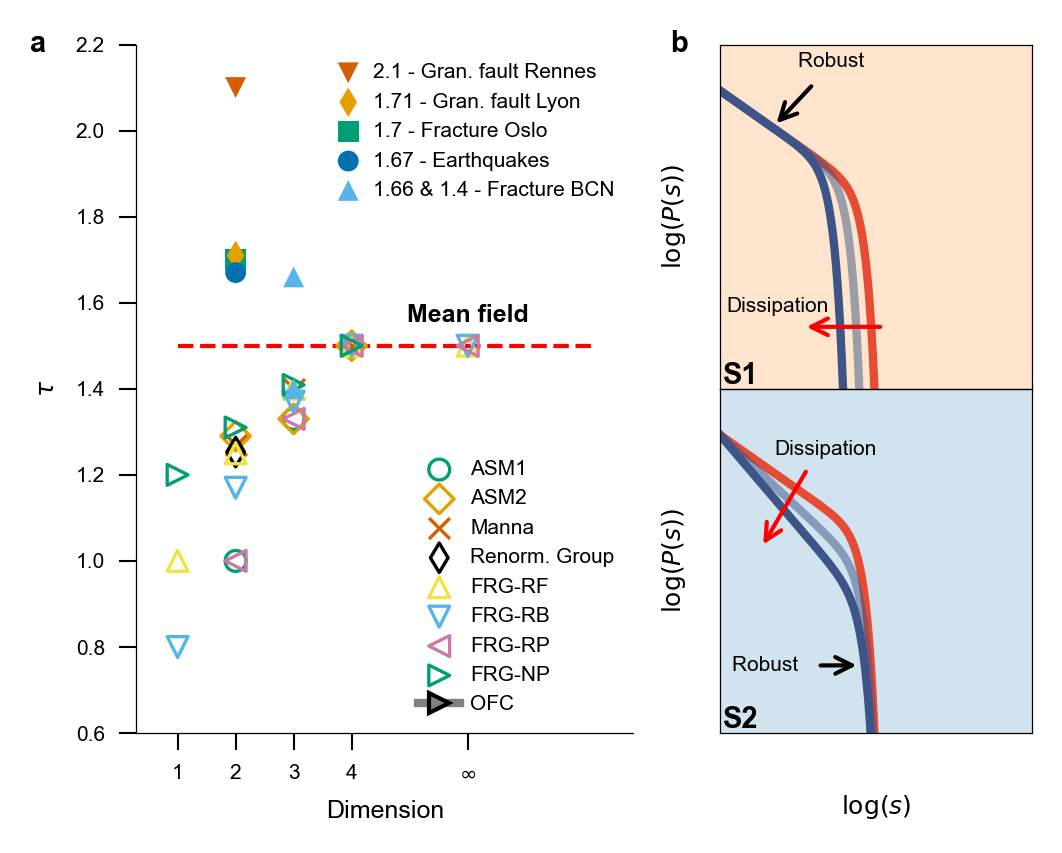

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import numpy as np
from scipy.interpolate import splprep, splev
from matplotlib.lines import Line2D

def transfo_x(x):
    return 1 + 0.7 * (np.array(x) - 1)



with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig = plt.figure(figsize=(3.5, 2.8))
    gs = gridspec.GridSpec(2, 2, width_ratios=[8.6, 5.4], hspace = 0.0)  # 2 lignes, 2 colonnes
    ################## Figure 1 ##################
    Zhang_tau = [1,1.33,3/2]
    Zhang_dim = [2,3,4]
    Vespigani_tau = [1.253]
    Vespigani_dim = [2]
    Chessa_tau = [1.27]
    Chessa_dim = [2]
    Lubeck_tau = [1.29, 1.33, 3/2]
    Lubeck2_tau = [1.27, 1.4, 3/2]
    Lubeck_dim = [2,3,4]
    DW_RF_tau = [1, 1.25, 1.4, 3/2, 3/2]
    DW_RB_tau = [0.8, 1.17, 1.37, 3/2, 3/2]
    DW_RP_tau = [0, 1, 1.33, 3/2, 3/2]
    DW_Dep_tau = [1.2, 1.31, 1.409, 3/2]
    DW_dim = [1,2,3,4,6]

    EQ_tau = [1.67]
    EQ_dim = [2]
    Rennes_tau = [2.1]
    Rennes_dim = [2]
    Lyon_tau = [1.71]
    Lyon_dim = [2]
    Oslo_tau = [1.7]
    Oslo_dim = [2]
    Barcelone_tau = [1.4, 1.66]
    Barcelone_dim = [3,3]

    positions_ticks = [1, 2, 3, 4, 6]
    labels_ticks = [1, 2, 3, 4, r'$\infty$']


    ms = 80
    ms2 = ms - 100
    lw = 0.8
    ts = 6

    color_list = ['#000000', '#e69f00', '#56b4e9', '#009e73',
                '#f0e442', '#0072b2', '#d55e00', '#cc79a7']

    ax1 = fig.add_subplot(gs[:, 0])  # La figure 1 prend toute la largeur (2 colonnes)
    pt_eq = ax1.scatter(transfo_x(EQ_dim), EQ_tau, label = r"1.67 - Earthquakes",
                        facecolor = color_list[5], edgecolors = 'None', marker = "o", zorder = 20)
    pt_rennes = ax1.scatter(transfo_x(Rennes_dim), Rennes_tau, label = r"2.1 - Gran. fault Rennes",
                            facecolor = color_list[6], edgecolors = 'None', marker = "v", zorder = 10) 
    pt_lyon = ax1.scatter(transfo_x(Lyon_dim), Lyon_tau, label = r"1.71 - Gran. fault Lyon",
                            facecolor = color_list[1], edgecolors = 'None', marker = "d", zorder = 11)
    pt_oslo = ax1.scatter(transfo_x(Oslo_dim), Oslo_tau, label = r"1.7 - Fracture Oslo",
                            facecolor = color_list[3], edgecolors = 'None', marker = "s", zorder = 10)
    pt_barcelone = ax1.scatter(transfo_x(Barcelone_dim), Barcelone_tau, label = r"1.66 & 1.4 - Fracture BCN",
                           facecolor = color_list[2], edgecolors = 'None', marker = "^",  zorder = 10)

    pt_zhang = ax1.scatter(transfo_x(Zhang_dim), Zhang_tau, label = "ASM1", facecolor = 'none', edgecolors=color_list[3], zorder = 5, marker = 'o', lw = lw)
    pt_lubeck = ax1.scatter(transfo_x(Lubeck_dim), Lubeck_tau, label = "ASM2", facecolor = 'none', edgecolors= color_list[1], marker = 'D', zorder = 5, lw = lw)
    pt_lubeck2 = ax1.scatter(transfo_x(Lubeck_dim), Lubeck2_tau, label = "Manna", facecolor = color_list[6], marker = 'x', zorder = 5, lw = lw)
    pt_vesp = ax1.scatter(transfo_x(Vespigani_dim), Vespigani_tau, label = "Renorm. Group", facecolor = 'none', edgecolors = color_list[0], marker = 'd', zorder = 5, lw = lw)
    pt_dwrf = ax1.scatter(transfo_x(DW_dim), DW_RF_tau, label = "FRG-RF", facecolor = 'none', edgecolors = color_list[4], marker = "^", zorder = 6, lw = lw)
    pt_dwrb = ax1.scatter(transfo_x(DW_dim), DW_RB_tau, label = "FRG-RB", facecolor = 'none', edgecolors = color_list[2], marker = "v", zorder = 6, lw = lw)
    pt_dwrp = ax1.scatter(transfo_x(DW_dim), DW_RP_tau, label = "FRG-RP", facecolor = 'none', edgecolors = color_list[7], marker = "<", zorder = 6, lw = lw)
    pt_dwdep = ax1.scatter(transfo_x(DW_dim[:-1]), DW_Dep_tau, label = "FRG-NP", facecolor = 'none', edgecolors = color_list[3], marker = ">", zorder = 6, lw = lw)

    #########REFERENCES###########
    # EQ: 
    # OSLO: Lherminier_PRL-2019
    # BCN: Baro_PRL-2013  
    # RENNES: Houdoux_cee-2021
    # LYON: Vehel_th-2021
    # ZHANG: Zhang_prl-1989
    # VESPIGANI: Vespignani_pre-1995
    # LUBECK: Lubeck_pre-1997
    # LUBECK2: Lubeck_pre-1997
    # CHESSA: Chessa_pre-1999
    # DW: Ledoussal_pre-2009

    ax1.annotate('Mean field', xy =(transfo_x([6]),1.57), xytext = (transfo_x([6]),1.57), ha = 'center', va = 'center',
                color = 'k', zorder = 100, fontweight = 'bold')
    ax1.hlines(1.5, 1, 6, color = 'red', linestyle = '--', zorder = 0)

    OFC = Line2D([0], [0], color='grey', lw=2, marker='>', label='OFC')

    ax1.set_xlabel('Dimension')
    ax1.set_ylabel(r"$\tau$")
    ax1.yaxis.labelpad = 4
    ax1.set_xticks(transfo_x(positions_ticks), labels_ticks)
    ax1.set_xlim(0.5,6.5)
    ax1.set_ylim(0.6, 2.2)
    legend1 = ax1.legend(handles=[pt_rennes, pt_lyon, pt_oslo, pt_eq, pt_barcelone],
                        loc='upper right', edgecolor = 'none', ncol = 1, handletextpad=0.2, fontsize = 5)
    ax1.set_facecolor((0., 0., 0., 0.))
    ax1.add_artist(legend1)
    for text in legend1.get_texts():
        if text.get_text() == "Earthquakes":
            text.set_fontweight("bold")
            
    ax1.legend(handles=[pt_zhang, pt_lubeck, pt_lubeck2, pt_vesp, pt_dwrf, pt_dwrb, pt_dwrp, pt_dwdep, OFC]
               , loc='lower right', edgecolor = 'none', ncol = 1, handletextpad=0.5, fontsize = 5)         


    ################## Figure 2 and 3 ##################
    x = np.arange(1,10000, 1, dtype= float)

    a = 1
    b = 1.2
    c = 2000
    d = 2
    c2 = 800
    d2 = 2
    c3 = 300
    d3 = 2

    a4 = 1
    b4 = 1.6
    a5 = 1
    b5 = 2.

    y = powercutoff_fit(x, a,b,c,d)
    y2 = powercutoff_fit(x, a,b,c2,d2)
    y3 = powercutoff_fit(x, a,b,c3,d3)

    y4 = powercutoff_fit(x, a4,b4,c,d)
    y5 = powercutoff_fit(x, a5,b5,c,d)

    #Arrow positions
    x_start, y_start = 2e4, 5e-11 
    x_end, y_end = 1e2, 5e-11  
    x_start2, y_start2 = 100, 10
    x_end2, y_end2 = 20, 2e-2 

    x_start3, y_start3 = 2e2, 5e-2
    x_end3, y_end3 = 1e1, 8e-6 
    x_start4, y_start4 = 2, 5e-11 
    x_end4, y_end4 = 5e3, 9e-11


    # inner_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[:, 1], hspace=0.1   )

    # Deux axes superposés dans la colonne de droite
    # ax2 = fig.add_subplot(inner_gs[0, 0])
    # ax3 = fig.add_subplot(inner_gs[1, 0])

    ax2 = fig.add_subplot(gs[0, 1]) #Fig top
    ax3 = fig.add_subplot(gs[1, 1], sharex = ax2) #Fig bottom

    ax2.plot(x, y, lw = 2, c = 'C0' )
    ax2.plot(x, y2, lw = 2, c = 'C3', alpha = 0.5 )
    ax2.plot(x, y3, lw = 2, c = 'C3')
    ax2.annotate("", xy=(x_end, y_end),  xytext=(x_start, y_start), fontsize = 10,  arrowprops=dict(arrowstyle="->", lw=1, color="red", mutation_scale = 10))
    ax2.text(3e1, 1.5e-10, "Dissipation", fontname = 'Arial', color="k", ha="center", va="bottom", fontsize = 5)
    ax2.annotate("Robust ", xy=(x_end2, y_end2),  xytext=(x_start2, y_start2), fontname = 'Arial', fontsize = 5, 
                arrowprops=dict(arrowstyle="->", lw=1, color="k", mutation_scale = 10))

    ax2.set_xlabel('')
    ax2.set_ylabel(r'$\log(P(s))$')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_facecolor((1.0, 0.498, 0.054, 0.2))
    ax2.set_xticklabels([])
    ax2.set_yticklabels([])
    ax2.tick_params(length = 0)
    ax2.set_ylim(1e-13,1e2)
    ax2.set_xlim(1,9e7)
    ax2.spines['top'].set_visible(True)
    ax2.spines['right'].set_visible(True)


    ax3.plot(x, y, lw = 2, c = 'C0' )
    ax3.plot(x, y4, lw =2, c = 'C3', alpha = 0.5 )
    ax3.plot(x, y5, lw = 2, c = 'C3')
    ax3.annotate("", xy=(x_end3, y_end3),  xytext=(x_start3, y_start3),
                arrowprops=dict(arrowstyle="->", lw=1, color="red", mutation_scale = 10))
    ax3.text(5e2, 9e-2, "Dissipation", fontname = 'Arial', color="k", ha="center", va="bottom", fontsize = 5)
    ax3.annotate("Robust ", xy=(x_end4, y_end4),  xytext=(x_start4, y_start4), fontname = 'Arial', fontsize = 5, 
                arrowprops=dict(arrowstyle="->", lw=1, color="k", mutation_scale = 10))
    

    

    ax3.set_ylim(1e-13,1e2)
    ax3.set_xlim(1,9e7)
    ax3.set_xlabel(r'$\log(s)$')
    ax3.set_ylabel(r'$\log(P(s))$')
    ax3.set_xscale('log')
    ax3.set_yscale('log')
    ax3.set_facecolor((0.121, 0.466, 0.705, 0.2))
    ax3.spines['top'].set_visible(True)
    ax3.spines['right'].set_visible(True)
    ax3.set_xticklabels([])
    ax3.set_yticklabels([])
    ax3.tick_params(length = 0)
    ax3.xaxis.set_label_coords(0.5, -.175) 
    
    
    fig.text(0.02, 0.95, "a", fontsize=7, fontweight="bold")  # "a" en haut à gauche
    fig.text(0.63, 0.95, "b", fontsize=7, fontweight="bold")   # "b" à côté de la deuxième ligne
    fig.text(0.68, 0.555, "S1", fontsize=7, fontweight="bold")
    fig.text(0.68, 0.145, "S2", fontsize=7, fontweight="bold")

    ################## Insert ##################
    def rect(x0,y0,w, h, lw = 1, c = 'k') : 
        rect = patches.Rectangle(
            (x0, y0),             # coin bas gauche en coord figure
            w,                    # largeur
            h,                   # hauteur
            linewidth=lw,
            edgecolor=c,
            facecolor='none',
            transform=fig.transFigure,    # <--- clé pour utiliser les coord figure
            zorder=10 
        )
        fig.patches.append(rect)


    fig.patch.set_alpha(0.0)
    plt.subplots_adjust(hspace=0) 
    plt.tight_layout()
    plt.savefig('Fig1_nature.pdf', bbox_inches='tight', dpi = 300)

    plt.show()


## Version, 2 colonnes

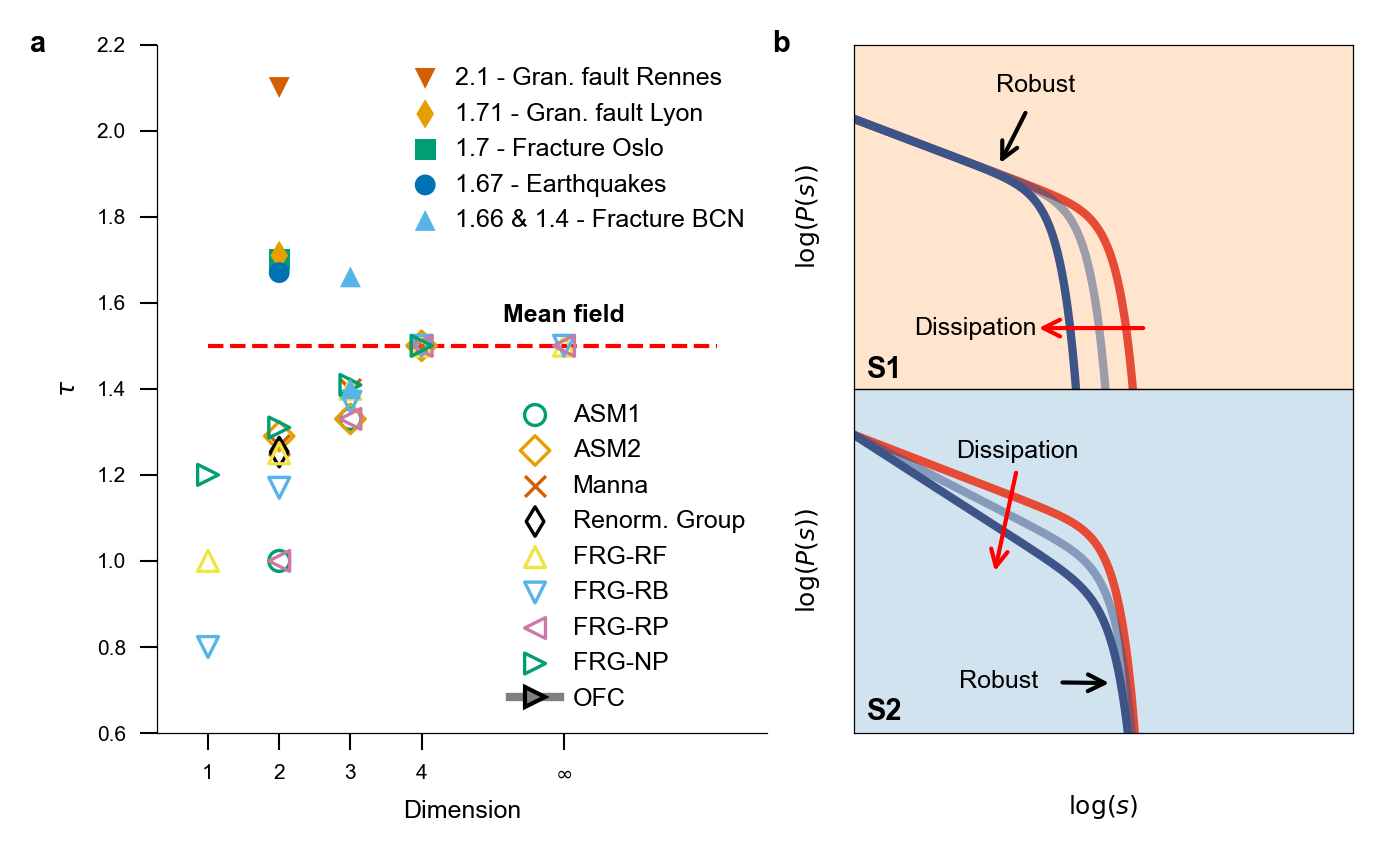

In [15]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import numpy as np
from scipy.interpolate import splprep, splev
from matplotlib.lines import Line2D

def transfo_x(x):
    return 1 + 0.7 * (np.array(x) - 1)



with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig = plt.figure(figsize=(4.5, 2.8))
    gs = gridspec.GridSpec(2, 2, width_ratios=[0.55, 0.45], hspace = 0.0)  # 2 lignes, 2 colonnes
    ################## Figure 1 ##################
    Zhang_tau = [1,1.33,3/2]
    Zhang_dim = [2,3,4]
    Vespigani_tau = [1.253]
    Vespigani_dim = [2]
    Chessa_tau = [1.27]
    Chessa_dim = [2]
    Lubeck_tau = [1.29, 1.33, 3/2]
    Lubeck2_tau = [1.27, 1.4, 3/2]
    Lubeck_dim = [2,3,4]
    DW_RF_tau = [1, 1.25, 1.4, 3/2, 3/2]
    DW_RB_tau = [0.8, 1.17, 1.37, 3/2, 3/2]
    DW_RP_tau = [0, 1, 1.33, 3/2, 3/2]
    DW_Dep_tau = [1.2, 1.31, 1.409, 3/2]
    DW_dim = [1,2,3,4,6]

    EQ_tau = [1.67]
    EQ_dim = [2]
    Rennes_tau = [2.1]
    Rennes_dim = [2]
    Lyon_tau = [1.71]
    Lyon_dim = [2]
    Oslo_tau = [1.7]
    Oslo_dim = [2]
    Barcelone_tau = [1.4, 1.66]
    Barcelone_dim = [3,3]

    positions_ticks = [1, 2, 3, 4, 6]
    labels_ticks = [1, 2, 3, 4, r'$\infty$']


    ms = 80
    ms2 = ms - 100
    lw = 0.8
    ts = 6

    color_list = ['#000000', '#e69f00', '#56b4e9', '#009e73',
                '#f0e442', '#0072b2', '#d55e00', '#cc79a7']

    ax1 = fig.add_subplot(gs[:, 0])  # La figure 1 prend toute la largeur (2 colonnes)
    pt_eq = ax1.scatter(transfo_x(EQ_dim), EQ_tau, label = r"1.67 - Earthquakes",
                        facecolor = color_list[5], edgecolors = 'None', marker = "o", zorder = 20)
    pt_rennes = ax1.scatter(transfo_x(Rennes_dim), Rennes_tau, label = r"2.1 - Gran. fault Rennes",
                            facecolor = color_list[6], edgecolors = 'None', marker = "v", zorder = 10) 
    pt_lyon = ax1.scatter(transfo_x(Lyon_dim), Lyon_tau, label = r"1.71 - Gran. fault Lyon",
                            facecolor = color_list[1], edgecolors = 'None', marker = "d", zorder = 11)
    pt_oslo = ax1.scatter(transfo_x(Oslo_dim), Oslo_tau, label = r"1.7 - Fracture Oslo",
                            facecolor = color_list[3], edgecolors = 'None', marker = "s", zorder = 10)
    pt_barcelone = ax1.scatter(transfo_x(Barcelone_dim), Barcelone_tau, label = r"1.66 & 1.4 - Fracture BCN",
                           facecolor = color_list[2], edgecolors = 'None', marker = "^",  zorder = 10)

    pt_zhang = ax1.scatter(transfo_x(Zhang_dim), Zhang_tau, label = "ASM1", facecolor = 'none', edgecolors=color_list[3], zorder = 5, marker = 'o', lw = lw)
    pt_lubeck = ax1.scatter(transfo_x(Lubeck_dim), Lubeck_tau, label = "ASM2", facecolor = 'none', edgecolors= color_list[1], marker = 'D', zorder = 5, lw = lw)
    pt_lubeck2 = ax1.scatter(transfo_x(Lubeck_dim), Lubeck2_tau, label = "Manna", facecolor = color_list[6], marker = 'x', zorder = 5, lw = lw)
    pt_vesp = ax1.scatter(transfo_x(Vespigani_dim), Vespigani_tau, label = "Renorm. Group", facecolor = 'none', edgecolors = color_list[0], marker = 'd', zorder = 5, lw = lw)
    pt_dwrf = ax1.scatter(transfo_x(DW_dim), DW_RF_tau, label = "FRG-RF", facecolor = 'none', edgecolors = color_list[4], marker = "^", zorder = 6, lw = lw)
    pt_dwrb = ax1.scatter(transfo_x(DW_dim), DW_RB_tau, label = "FRG-RB", facecolor = 'none', edgecolors = color_list[2], marker = "v", zorder = 6, lw = lw)
    pt_dwrp = ax1.scatter(transfo_x(DW_dim), DW_RP_tau, label = "FRG-RP", facecolor = 'none', edgecolors = color_list[7], marker = "<", zorder = 6, lw = lw)
    pt_dwdep = ax1.scatter(transfo_x(DW_dim[:-1]), DW_Dep_tau, label = "FRG-NP", facecolor = 'none', edgecolors = color_list[3], marker = ">", zorder = 6, lw = lw)

    #########REFERENCES###########
    # EQ: 
    # OSLO: Lherminier_PRL-2019
    # BCN: Baro_PRL-2013  
    # RENNES: Houdoux_cee-2021
    # LYON: Vehel_th-2021
    # ZHANG: Zhang_prl-1989
    # VESPIGANI: Vespignani_pre-1995
    # LUBECK: Lubeck_pre-1997
    # LUBECK2: Lubeck_pre-1997
    # CHESSA: Chessa_pre-1999
    # DW: Ledoussal_pre-2009

    ax1.annotate('Mean field', xy =(transfo_x([6]),1.57), xytext = (transfo_x([6]),1.57), ha = 'center', va = 'center',
                color = 'k', zorder = 100, fontweight = 'bold')
    ax1.hlines(1.5, 1, 6, color = 'red', linestyle = '--', zorder = 0)

    OFC = Line2D([0], [0], color='grey', lw=2, marker='>', label='OFC')

    ax1.set_xlabel('Dimension')
    ax1.set_ylabel(r"$\tau$")
    ax1.yaxis.labelpad = 4
    ax1.set_xticks(transfo_x(positions_ticks), labels_ticks)
    ax1.set_xlim(0.5,6.5)
    ax1.set_ylim(0.6, 2.2)
    legend1 = ax1.legend(handles=[pt_rennes, pt_lyon, pt_oslo, pt_eq, pt_barcelone],
                        loc='upper right', edgecolor = 'none', ncol = 1, handletextpad=0.2, fontsize = 6)
    ax1.set_facecolor((0., 0., 0., 0.))
    ax1.add_artist(legend1)
    for text in legend1.get_texts():
        if text.get_text() == "Earthquakes":
            text.set_fontweight("bold")
            
    ax1.legend(handles=[pt_zhang, pt_lubeck, pt_lubeck2, pt_vesp, pt_dwrf, pt_dwrb, pt_dwrp, pt_dwdep, OFC]
               , loc='lower right', edgecolor = 'none', ncol = 1, handletextpad=0.5, fontsize = 6)         


    ################## Figure 2 and 3 ##################
    x = np.arange(1,10000, 1, dtype= float)

    a = 1
    b = 1.2
    c = 2000
    d = 2
    c2 = 800
    d2 = 2
    c3 = 300
    d3 = 2

    a4 = 1
    b4 = 1.6
    a5 = 1
    b5 = 2.

    y = powercutoff_fit(x, a,b,c,d)
    y2 = powercutoff_fit(x, a,b,c2,d2)
    y3 = powercutoff_fit(x, a,b,c3,d3)

    y4 = powercutoff_fit(x, a4,b4,c,d)
    y5 = powercutoff_fit(x, a5,b5,c,d)

    #Arrow positions
    x_start, y_start = 1.5e4, 5e-10 
    x_end, y_end = 3e2, 5e-10  
    x_start2, y_start2 = 100, 20
    x_end2, y_end2 = 100, 5e-3 

    x_start3, y_start3 = 2e2, 5e-2
    x_end3, y_end3 = 9e1, 5e-7 
    x_start4, y_start4 = 3e1, 9e-12 
    x_end4, y_end4 = 5e3, 1.5e-11


    # inner_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[:, 1], hspace=0.1   )

    # Deux axes superposés dans la colonne de droite
    # ax2 = fig.add_subplot(inner_gs[0, 0])
    # ax3 = fig.add_subplot(inner_gs[1, 0])

    ax2 = fig.add_subplot(gs[0, 1]) #Fig top
    ax3 = fig.add_subplot(gs[1, 1], sharex = ax2) #Fig bottom

    ax2.plot(x, y, lw = 2, c = 'C0' )
    ax2.plot(x, y2, lw = 2, c = 'C3', alpha = 0.5 )
    ax2.plot(x, y3, lw = 2, c = 'C3')
    ax2.annotate("", xy=(x_end, y_end),  xytext=(x_start, y_start), fontsize = 10,  arrowprops=dict(arrowstyle="->", lw=1, color="red", mutation_scale = 10))
    ax2.text(5e1, 1.5e-10, "Dissipation", fontname = 'Arial', color="k", ha="center", va="bottom", fontsize = 6)
    ax2.annotate("Robust ", xy=(x_end2, y_end2),  xytext=(x_start2, y_start2-4), fontname = 'Arial', fontsize = 6, 
                arrowprops=dict(arrowstyle="->", lw=1, color="k", mutation_scale = 10))

    ax2.set_xlabel('')
    ax2.set_ylabel(r'$\log(P(s))$')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_facecolor((1.0, 0.498, 0.054, 0.2))
    ax2.set_xticklabels([])
    ax2.set_yticklabels([])
    ax2.tick_params(length = 0)
    ax2.set_ylim(1e-12,2e3)
    ax2.set_xlim(1e5)
    ax2.spines['top'].set_visible(True)
    ax2.spines['right'].set_visible(True)


    ax3.plot(x, y, lw = 2, c = 'C0' )
    ax3.plot(x, y4, lw =2, c = 'C3', alpha = 0.5 )
    ax3.plot(x, y5, lw = 2, c = 'C3')
    ax3.annotate("", xy=(x_end3, y_end3),  xytext=(x_start3, y_start3),
                arrowprops=dict(arrowstyle="->", lw=1, color="red", mutation_scale = 10))
    ax3.text(2e2, 6e-2, "Dissipation", fontname = 'Arial', color="k", ha="center", va="bottom", fontsize = 6)
    ax3.annotate("Robust ", xy=(x_end4, y_end4),  xytext=(x_start4, y_start4), fontname = 'Arial', fontsize = 6, 
                arrowprops=dict(arrowstyle="->", lw=1, color="k", mutation_scale = 10))
    

    

    ax3.set_ylim(1e-13,1e2)
    ax3.set_xlim(1,1e7)
    ax3.set_xlabel(r'$\log(s)$')
    ax3.set_ylabel(r'$\log(P(s))$')
    ax3.set_xscale('log')
    ax3.set_yscale('log')
    ax3.set_facecolor((0.121, 0.466, 0.705, 0.2))
    ax3.spines['top'].set_visible(True)
    ax3.spines['right'].set_visible(True)
    ax3.set_xticklabels([])
    ax3.set_yticklabels([])
    ax3.tick_params(length = 0)
    ax3.xaxis.set_label_coords(0.5, -.175) 
    
    # ax4 = fig.add_subplot(gs[0, 2]) #Fig top
    # ax5 = fig.add_subplot(gs[1, 2], sharex = ax4) #Fig bottom
    # ax4.set_facecolor((1.0, 0.498, 0.054, 0.2))
    # ax4.spines['top'].set_visible(True)
    # ax4.spines['right'].set_visible(True)
    # ax4.set_xticklabels([])
    # ax4.set_yticklabels([])
    # ax4.tick_params(length = 0)
    # ax5.set_facecolor((0.121, 0.466, 0.705, 0.2))
    # ax5.spines['top'].set_visible(True)
    # ax5.spines['right'].set_visible(True)
    # ax5.set_xticklabels([])
    # ax5.set_yticklabels([])
    # ax5.tick_params(length = 0)
    
    
    fig.text(0.00, 0.95, "a", fontsize=7, fontweight="bold")  # "a" en haut à gauche
    fig.text(0.55, 0.95, "b", fontsize=7, fontweight="bold")   # "b" à côté de la deuxième ligne
    fig.text(0.62, 0.562, "S1", fontsize=7, fontweight="bold")
    fig.text(0.62, 0.155, "S2", fontsize=7, fontweight="bold")

    fig.patch.set_alpha(0.0)
    plt.subplots_adjust(hspace=0) 
    plt.tight_layout()
    plt.savefig('Fig1_nature_2col.pdf', bbox_inches='tight', dpi = 300)

    plt.show()


#  Figure 2

## all in one

In [1]:
def process_memory_trace(folderpath, Tshapefile, smin, L1, L2, nblinemax = 100):
    
    # mean_ava = 0
    # mean_rest = 0
    mean_diff = 0
    i = 0
    for shapefile in Tshapefile:
        with open(f'{folderpath}/{shapefile}', 'r') as fshape:
            
            lines = fshape.readlines()[2:] #skip the first 2 lines
            for line in (lines):
                if line.startswith("#"):
                    continue
                
                coords = np.array(list(map(int, line.strip().split("  ")[3:])), dtype=int)
                iava = int(line.strip().split("  ")[0])
                x, y = np.unravel_index(coords, (L1, L2))
                
                if len(x) > smin  :

                    sys = np.loadtxt(f'{folderpath}/Snapshots/nav{iava}_outputB.txt', comments='#').reshape(L1, L2)
                    sys = sys.T
                    
                    mask = np.zeros(sys.shape, dtype = bool)
                    mask[y, x] = True
                    
                    #np.any verifie si il y a au moins un élément non nul dans le tableau
                    #np.isfinite verifie si il y a au moins un élément fini dans le tableau. Il est necessaire car un nan est considéré comme non nul
                    if not np.any(~mask) and not np.any(np.isfinite(sys[~mask])):
                        continue
                    
                    mean_diff += abs(np.mean(sys[mask]) - np.mean(sys[~mask]))
                    
                    i += 1
                    
                if i >= nblinemax:
                        break
                
    # return (mean_ava / i), (mean_rest / i)
    return (mean_diff / i)

def process_memory_trace2(folderpath, Tshapefile, smin, L1, L2, nblinemax = 100): #<a*s>
    
    mean_diff = 0
    i = 0
    for shapefile in Tshapefile:
        with open(f'{folderpath}/{shapefile}', 'r') as fshape:
            
            lines = fshape.readlines()[2:] #skip the first 2 lines
            for line in (lines):
                if line.startswith("#"):
                    continue
                
                coords = np.array(list(map(int, line.strip().split("  ")[3:])), dtype=int)
                iava = int(line.strip().split("  ")[0])
                x, y = np.unravel_index(coords, (L1, L2))
                
                if len(x) > smin  :

                    sys = np.loadtxt(f'{folderpath}/Snapshots/nav{iava}_outputB.txt', comments='#').reshape(L1, L2)
                    sys = sys.T
                    
                    mask = np.zeros(sys.shape, dtype = bool)
                    mask[y, x] = True
                    
                    #np.any verifie si il y a au moins un élément non nul dans le tableau
                    #np.isfinite verifie si il y a au moins un élément fini dans le tableau. Il est necessaire car un nan est considéré comme non nul
                    if not np.any(~mask) and not np.any(np.isfinite(sys[~mask])):
                        continue
                    
                    mean_diff += abs((np.mean(sys[mask])-np.mean(sys[~mask]))*np.sum(mask)) 
                    
                    i += 1
                    
                if i >= nblinemax:
                        break
                
    return (mean_diff / i)

def process_top_faster(folder, Lengthtab, nbins, nmin, nmax):
    data = np.loadtxt(f"{folder}/stat_histotop.txt", comments = "#")
    mean = np.sum(data * np.arange(len(data)))/np.sum(data)
    
    return mean

In [ ]:
###############################TO UPDATE#################################

#P(s)

results_s = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder))
                                                                    for  folder in folderpath)

Thisto_s64, Tbins_s64, Tnonzero_s64, _, _ = zip(*results_s)

Tstop_x = [4.e3, 1e-8, 7e-10,  1.1e-8, 1e-6,5e-5,5e-5,1e-7, 1e-8, 1e-9, 1e-10, 1e-9, 5e-11, 1e-11]
Tstart_x = [2,4,4,4,1,0,1,3,5,4,4,8,8,8]
Txfit_s, Tyfit_s, Ttau_s, Tperr_s = PDF_fitting(Thisto_s, Tbins_s, Tstart_x, Tstop_x, Tvar)

#Intertime
# nbins = 1000
# results_it = np.array(Parallel(n_jobs=-1)(delayed(process_time_from_histo)(folder, nbins + 1)
#                                   for folder in folderpath))

#Memory trace
Tfolderpath_memory = [f"/data1/DATA_Duplat/Brut/Ava_track/Av3n{nb}" for nb in fnb]
Tshapefile_memory = ['shape_outputB10.txt', 'shape_outputB100.txt', 'shape_outputB1000.txt']
smin_memory = 1
nblinemax_memory = 10000

results_memory = Parallel(n_jobs=-1)(delayed(process_memory_trace)(folder, Tshapefile_memory, smin_memory, L1, L2, nblinemax_memory)
                                  for folder in Tfolderpath_memory)
# results_memory = Parallel(n_jobs=-1)(delayed(process_memory_trace2)(folder, Tshapefile_memory, smin_memory, L1, L2, nblinemax_memory)
#                                   for folder in Tfolderpath_memory)
Tmean_diff = np.array(results_memory).T

#Toppling
lengthtab = L1 * L2 * 1000
results_t = Parallel(n_jobs=-1)(delayed(process_top_faster)(folder, lengthtab, nbins, nmin, nmax)
                                  for (folder, nmin, nmax) in zip(folderpath, Tnmin, Tnmax))
Tmean_t = np.array(results_t).T

<ipython-input-4-70059b394b50>:5: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  Thisto_s, Tbins_s, Tnonzero_s, Tmean_s,Tnbins_s = np.array(Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder))


0.9744781025796705
0.9976383971124009
0.9918982444042698
0.9980956394950128
0.9968334128614926
0.9920430763999138
0.9903896119141421
0.9250754294894042
0.91545662788679
0.9717307223219532
0.8960592077546272
0.9052499129178495
0.8708878533091065
0.8955955138959117


In [ ]:
###############################TO SAVE INFO#################################
np.savez("Figure2.npz", 
         Tvar=Tvar, 
         Ttau_s=Ttau_s, 
         Tbins_s=Tbins_s, 
         Thisto_s=Thisto_s, 
         Txfit_s=Txfit_s, 
         Tyfit_s=Tyfit_s, 
         Tnonzero_s=Tnonzero_s, 
         Tmean_s=Tmean_s,
         Tmean_t=Tmean_t,
         Tmean_diff=Tmean_diff)


In [12]:
###############################TO LOAD INFO#################################
data = np.load("Figure2.npz", allow_pickle=True)

Tvar = data["Tvar"]
Ttau_s = data["Ttau_s"]
Tbins_s = data["Tbins_s"]
Thisto_s = data["Thisto_s"]
Txfit_s = data["Txfit_s"]
Tyfit_s = data["Tyfit_s"]
Tnonzero_s= data["Tnonzero_s"] 
Tmean_s= data["Tmean_s"]
Tmean_t= data["Tmean_t"]
Tmean_diff= data["Tmean_diff"]

##  Version Nature reviews

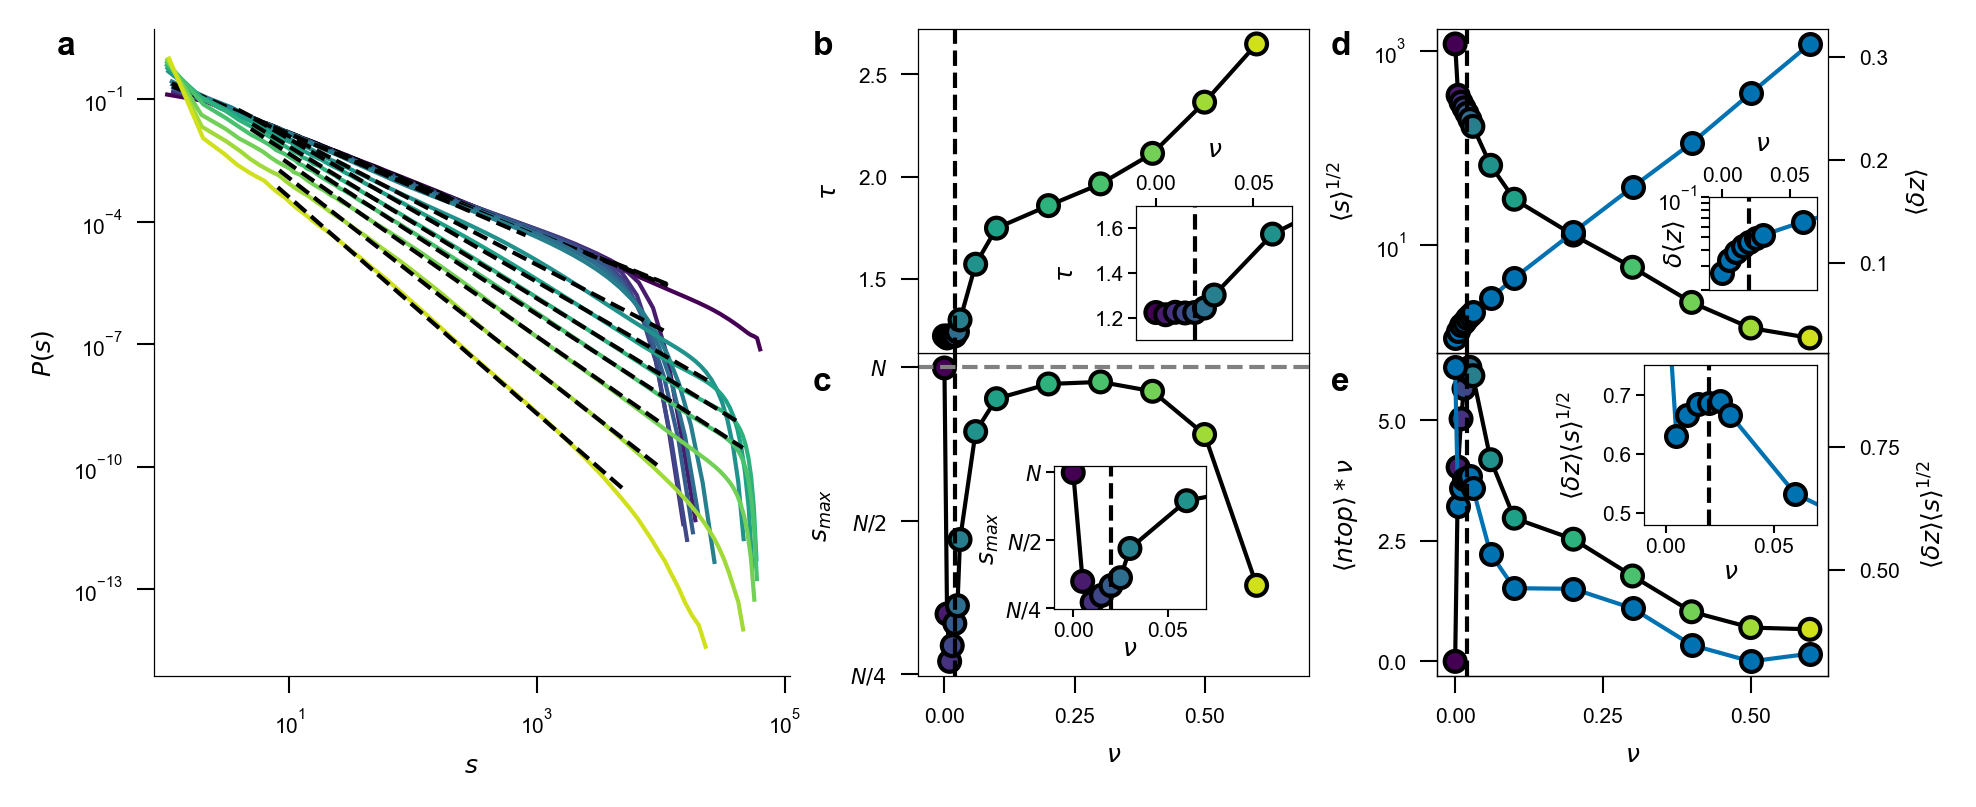

In [ ]:
from matplotlib.ticker import FixedLocator, NullLocator
NCURVES = len(Tvar)
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig = plt.figure(figsize=(7.2, 2.8))
    gs = gridspec.GridSpec(2, 4, width_ratios=[1.5, 5, 5, 5], wspace = 0.4, hspace = 0)  # 2 lignes, 2 colonnes
    colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

    ################## P(s) ##################
    ax1 = fig.add_subplot(gs[:, :2])  # La figure 1 prend toute la largeur (2 colonnes)

    for i, (histo, bins, xfit, yfit) in enumerate(zip(Thisto_s, Tbins_s, Txfit_s, Tyfit_s)):
        ax1.plot(bins,histo, color = colors[i])
        ax1.plot(xfit, yfit, 'k--')

    ax1.set_xticks([1e0, 1e1, 1e2, 1e3, 1e4, 1e5])
    ax1.set_xlim(0.8,1.1e5)
    ax1.set_xlabel(r'$s$')
    ax1.set_ylabel(r'$P(s)$')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    

    
    ################## Smax ##################
    ax2 = fig.add_subplot(gs[1, 2])
    ax2.scatter(Tvar, Tnonzero_s, c=colors, marker='o', zorder=2)  # s contrôle la taille des marqueurs
    ax2.plot(Tvar, Tnonzero_s, '-', c = 'k', zorder=1)  # s contrôle la taille des marqueurs
    ax2.axvline(Tvar[4], ls = '--', c = 'k', label = "{} = {}".format(macros['diss'], Tvar[2]))
    ax2.axhline(L1 * L2, c = "grey", ls = '--')
    ax2.xaxis.set_visible(True)
    ax2.set_xlabel(r'$\nu$')
    ax2.set_ylabel(r'$s_{max}$')
    ax2.set_yscale('log')
    
    N = L1*L2
    yticks = [N, N/2, N/4]
    ax2.yaxis.set_major_locator(FixedLocator(yticks))  # Supprime tous les autres ticks majeurs
    ax2.yaxis.set_minor_locator(NullLocator())  # Supprime les ticks mineurs
    ax2.set_yticklabels([r'$N$', r'$N / 2$', r'$N / 4$'])
    ax2.set_xlim(-0.05,0.7) 
    ax2.spines['top'].set_visible(True)
    ax2.spines['right'].set_visible(True)

    ax22 = fig.add_axes([0.542, 0.19, 0.07, 0.17])
    ax22.scatter(Tvar, Tnonzero_s, c=colors, marker='o', zorder=2)  # s contrôle la taille des marqueurs
    ax22.plot(Tvar, Tnonzero_s, '-', c = 'k', zorder=1)
    ax22.axvline(Tvar[4], ls = '--', c = 'k', label = "{} = {}".format(macros['diss'], Tvar[2]))
    ax22.set_xlim(-0.01,0.07)
    # para_fig(ax22, r'$\nu$', r'$s_{max}$',type = 'semilog', labelsize = medium_debug, tickssize= small_debug/1.5, width_M = 1, length_M = 5)
    ax22.set_xlabel(r'$\nu$')
    ax22.set_ylabel(r'$s_{max}$')
    ax22.set_yscale('log')
    ax22.yaxis.set_major_locator(FixedLocator(yticks))  # Supprime tous les autres ticks majeurs
    ax22.yaxis.set_minor_locator(NullLocator())  # Supprime les ticks mineurs
    ax22.set_yticklabels([r'$N$', r'$N / 2$', r'$N / 4$'])
    ax22.spines['top'].set_visible(True)
    ax22.spines['right'].set_visible(True)
    ax22.tick_params(labelsize = 5, length = 2, pad = 1)
    ax22.xaxis.set_label_coords(0.5, -0.2) 
    ax22.yaxis.set_label_coords(-0.35, 0.5) 

    ################## Avg_dissipated energy ##################
    ax3 = fig.add_subplot(gs[1, 3])  # La figure 1 prend toute la largeur (2 colonnes)
    ax3.scatter(Tvar, Tmean_t * Tvar, c=colors, marker='o', zorder=2)
    ax3.plot(Tvar, Tmean_t * Tvar, c = 'k', zorder = 1)

    ax32 = ax3.twinx()
    ax32.plot(Tvar, Tmean_diff*Tmean_s**(1/2), marker = 'o', c ='#0072b2')
    ax32.axvline(Tvar[4], linestyle = '--', c = 'k', label = '{}'.format(Tvar[3]), zorder = 2)
    
    
    ax33 = fig.add_axes([0.815, 0.29, 0.08, 0.19])
    ax33.plot(Tvar, Tmean_diff*Tmean_s**(1/2), marker = 'o', c = '#0072b2')
    ax33.axvline(Tvar[4], linestyle = '--', c = 'k', zorder = 2)
    
    ax3.set_xlabel(r'$\nu$')
    ax3.set_ylabel(r'$\langle ntop \rangle * \nu$')
    ax32.set_xlabel(r'$\nu$')
    ax32.set_ylabel(r'$ \langle \delta z\rangle \langle s\rangle^{1/2}$')
    ax3.spines['top'].set_visible(True)
    ax3.spines['right'].set_visible(True)
    ax32.spines['top'].set_visible(True)
    ax32.spines['right'].set_visible(True)
    # ax32.set_ylim(-0.02, 0.87)
    
    ax33.set_xlabel(r'$\nu$', fontsize = 6)
    ax33.set_ylabel(r'$ \langle \delta z\rangle \langle s\rangle^{1/2}$', fontsize = 6)
    ax33.set_xlim(-0.01,0.07)
    ax33.set_ylim(0.48, 0.75)
    
    ax33.xaxis.labelpad = 1
    ax33.spines['top'].set_visible(True)
    ax33.spines['right'].set_visible(True)
    ax33.tick_params(labelsize = 5, length = 2, pad = 1)

    ################## Exposant ##################
    ax4 = fig.add_subplot(gs[0, 2])  # La figure 1 prend toute la largeur (2 colonnes)
    ax4.scatter(Tvar, -Ttau_s, c = colors, zorder=2, marker = 'o')
    ax4.plot(Tvar, -Ttau_s, linestyle = '-', c = 'k', zorder=1)       
    ax4.axvline(Tvar[4], linestyle = '--', c = 'k', label = '{}'.format(Tvar[3]))
    ax4.set_xlim(-0.05,0.7) 
    ax4.xaxis.set_visible(False)
    ax4.set_xlabel(r'$\nu$')
    ax4.set_ylabel(r'$\tau$')
    ax4.spines['top'].set_visible(True)
    ax4.spines['right'].set_visible(True)
    


    ax42 = fig.add_axes([0.58, 0.51, 0.072, 0.16])
    ax42.plot(Tvar, -Ttau_s, linestyle = '-', c = 'k', zorder=1)
    ax42.scatter(Tvar, -Ttau_s, c = colors, zorder=2, marker = 'o')
    ax42.axvline(Tvar[4], linestyle = '--', c = 'k', label = '{}'.format(Tvar[3]))
    ax42.set_xlim(-0.01,0.07)
    ax42.set_ylim(1.1,1.7)

    ax42.xaxis.set_label_coords(-0.5, 1.5) 
    ax42.xaxis.set_ticks_position('top')
    ax42.set_xlabel(r'$\nu$')
    ax42.set_ylabel(r'$\tau$')
    ax42.spines['top'].set_visible(True)
    ax42.spines['right'].set_visible(True)
    ax42.tick_params(labelsize = 5, length = 2, pad = 1)
    

    ################## <s> <dz> ##################
    ax5 = fig.add_subplot(gs[0, 3])

    ax5.scatter(Tvar, Tmean_s, c = colors, zorder=2, marker = 'o')
    ax5.plot(Tvar, Tmean_s, c = 'k', zorder=1)

    ax52 = ax5.twinx()
    ax52.plot(Tvar, Tmean_diff, marker = 'o', c = '#0072b2')
    ax52.axvline(Tvar[4], linestyle = '--', c = 'k', label = '{}'.format(Tvar[3]), zorder = 2)
    
    ax53 = fig.add_axes([0.845, 0.57, 0.05, 0.11])
    ax53.plot(Tvar, Tmean_diff, marker = 'o', c = '#0072b2')
    ax53.axvline(Tvar[4], linestyle = '--', c = 'k', label = '{}'.format(Tvar[3]), zorder = 2)
    
    ax5.set_xlabel(r'$\nu$')
    ax5.set_ylabel(r'$\langle s \rangle^{1/2}$')
    ax5.set_yscale('log')
    ax5.xaxis.set_visible(False)
    ax52.set_xlabel('')
    ax52.set_ylabel(r'$\langle  \delta z \rangle$')
    ax52.spines['top'].set_visible(True)
    ax52.spines['right'].set_visible(True)
    ax53.set_xlabel(r'$\nu$')
    ax53.set_ylabel(r'$\delta \langle  z \rangle$')
    ax53.set_yscale('log')
    ax53.set_xlim(-0.01,0.07)
    ax53.set_ylim(2e-2,1e-1)
    ax53.yaxis.set_label_coords(-0.2, 0.5) 
    ax53.xaxis.set_label_coords(0.5, 1.7) 
    ax53.tick_params(labelsize = 5, length = 2, pad = 1)
    ax53.yaxis.set_minor_formatter(plt.NullFormatter())
    ax53.xaxis.set_ticks_position('top')
    ax53.spines['top'].set_visible(True)
    ax53.spines['right'].set_visible(True)
    

    fig.text(0.08, 0.85, "a", fontsize=8, fontweight="bold") 
    fig.text(0.43, 0.85, "b", fontsize=8, fontweight="bold")  
    fig.text(0.67, 0.85, "d", fontsize=8, fontweight="bold") 
    fig.text(0.43, 0.45, "c", fontsize=8, fontweight="bold")
    fig.text(0.67, 0.45, "e", fontsize=8, fontweight="bold")
    plt.savefig("Fig2_nature.pdf",  bbox_inches='tight', dpi = 300)


#   Figure 3

##  V1

In [4]:
fnb = np.arange(1,15)
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
Tvar = [read_parameters(folder)[2] for folder in folderpath]
NCURVES = len(Tvar)

nbins = 1000
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]

# results_it = Parallel(n_jobs=-1)(delayed(process_time)(folder, nbins + 1)
#                                   for folder in folderpath)

results_it = np.array(Parallel(n_jobs=-1)(delayed(process_time_from_histo)(folder, nbins + 1)
                                  for folder in folderpath))

In [5]:
Tstart_x = [1e-6,1e-10,1e-6,1e-10,1e-7,
           1e-10,1e-10,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10]

Tstop_x = [1e-1,1e-1,1e-1,1e-1,1e-1,
        1e-1,1e-5,1e-5,4e-4,5e-3,
        5e-2,5e-2,5e-2,3e-2]

nb_reduced_bins = 100

Tpdf,Txfit, Tyfit, Tgamma, Tperr =  PDF_it_histogram(results_it, Tstart_x, Tstop_x, nb_reduced_bins)

In [6]:
sys1 = np.loadtxt("/data1/DATA_Duplat/Brut/PDF/PD5n1/Snapshots/nav100000000_outputB.txt", comments='#').reshape(L1, L2).T
sys2 = np.loadtxt("/data1/DATA_Duplat/Brut/PDF/PD5n5/Snapshots/nav100000000_outputB.txt", comments='#').reshape(L1, L2).T
sys3 = np.loadtxt("/data1/DATA_Duplat/Brut/PDF/PD5n10/Snapshots/nav1000000000_outputB.txt", comments='#').reshape(L1, L2).T
sys4 = np.loadtxt("/data1/DATA_Duplat/Brut/PDF/PD5n14/Snapshots/nav10000000000_outputB.txt", comments='#').reshape(L1, L2).T


### Version Nature reviews

In [79]:
with plt.style.context(spstyle.get_style('nature-reviews')):
    print(spstyle.get_style('nature-reviews'))
    plt.rcParams['font.family'] = 'Arial' 
    fig = plt.figure(figsize=(7.2, 4.8))
    gs = gridspec.GridSpec(2, 5, width_ratios=[0.15,0.15,0.15,0.15,0.03], hspace=0.1, wspace=0.4)
    
    NCURVEs = len(Tpdf)
    colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
    
    ax1 = fig.add_subplot(gs[0, :2])  # La figure 1 prend toute la largeur (2 colonnes)
    for j, (histo, xfit, yfit) in enumerate(zip(Tpdf, Txfit, Tyfit)):
        ax1.plot(histo[:,0], histo[:, 1], color = colors[j])
        ax1.plot(xfit,yfit, 'k--')
        
    poisson = gamma_distribution(histo[:,0], 1, -0.0, 1.)
    ax1.plot(histo[:,0], poisson, linestyle = '--', color = 'red')
    
    ax2 = fig.add_subplot(gs[0, 2:4])
    ax2.plot(Tvar, -Tgamma, linestyle = '-', c = 'k', zorder=1, )
    ax2.scatter(Tvar, -Tgamma, c = colors[:], zorder=2, marker = 'o')
    ax2.axvline(Tvar[4], linestyle = '--', c = 'k', label = '{}'.format(Tvar[3]), zorder = 2)

    ax22 = fig.add_axes([0.67, 0.6, 0.14, 0.18])
    ax22.plot(Tvar, -Tgamma, linestyle = '-', c = 'k', zorder=1)
    ax22.scatter(Tvar, -Tgamma, c = colors[:], zorder=2, marker = 'o')
    ax22.axvline(Tvar[4], linestyle = '--', c = 'k', label = '{}'.format(Tvar[3]), zorder = 2)
    
    ax31 = fig.add_subplot(gs[1, 0])
    ax31.imshow(sys1, cmap = "binary")
    ax31.set_title(r"$\nu = 0.0$")
    
    ax32 = fig.add_subplot(gs[1, 1])
    ax32.imshow(sys2, cmap = "binary")
    ax32.set_title(r"$\nu = 0.02$")
    
    ax33 = fig.add_subplot(gs[1, 2])
    ax33.imshow(sys3, cmap = "binary")
    ax33.set_title(r"$\nu = 0.2$")
    
    ax34 = fig.add_subplot(gs[1, 3])
    im = ax34.imshow(sys4, cmap="binary")
    ax34.set_title(r"$\nu = 0.6$")

    pos = ax34.get_position()
    # Place colorbar to the right of ax34
    cax = fig.add_axes([pos.x1 + 0.005, pos.y0, 0.01, pos.height])  # [x0, y0, width, height]
    cbar = plt.colorbar(im, cax=cax, ticks=[0, 0.5, 1.0])
    cbar.set_ticks([0,0.5,1.0])
    cbar.set_ticklabels(['0', '0.5', '1'])
    
    
    
    ax1.set_xlim(2e-9, 1e2)
    ax1.set_ylim(1e-5, 1.5e6)
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel(r'$T/<T>$')
    ax1.set_ylabel(r'$P(T) * <T>$')
    
    ax2.set_xlabel( r'$\nu$')
    ax2.set_ylabel(r'$\gamma$')
    
    ax22.set_xlim(-0.01,0.07)
    ax22.set_ylim(-0.05,0.6)
    ax22.set_xlabel( r'$\nu$', fontsize=7)
    ax22.set_ylabel(r'$\gamma$', fontsize=7)
    ax22.spines['top'].set_visible(True)
    ax22.spines['right'].set_visible(True)
    ax22.tick_params(labelsize = 5)
    
    ax31.set_axis_off()
    ax32.set_axis_off()
    ax33.set_axis_off()
    ax34.set_axis_off()
    fig.text(0.09, 0.85, "a", fontsize=7, fontweight="bold") 
    fig.text(0.45, 0.85, "b", fontsize=7, fontweight="bold") 
    fig.text(0.09, 0.4, "c", fontsize=7, fontweight="bold") 
    
    ax22.patch.set_alpha(0.0)
    fig.patch.set_alpha(0.0)

    plt.savefig("Fig3_nature.pdf", bbox_inches='tight', dpi = 300)
    
    
    

/home/kduplat/Documents/py38/lib/python3.8/site-packages/sciplotlib/stylesheets/nature-reviews.mplstyle


NameError: name 'Tpdf' is not defined

##  V2

/home/kduplat/Documents/py38/lib/python3.8/site-packages/sciplotlib/stylesheets/nature-reviews.mplstyle


/tmp/ipykernel_817085/1239034815.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


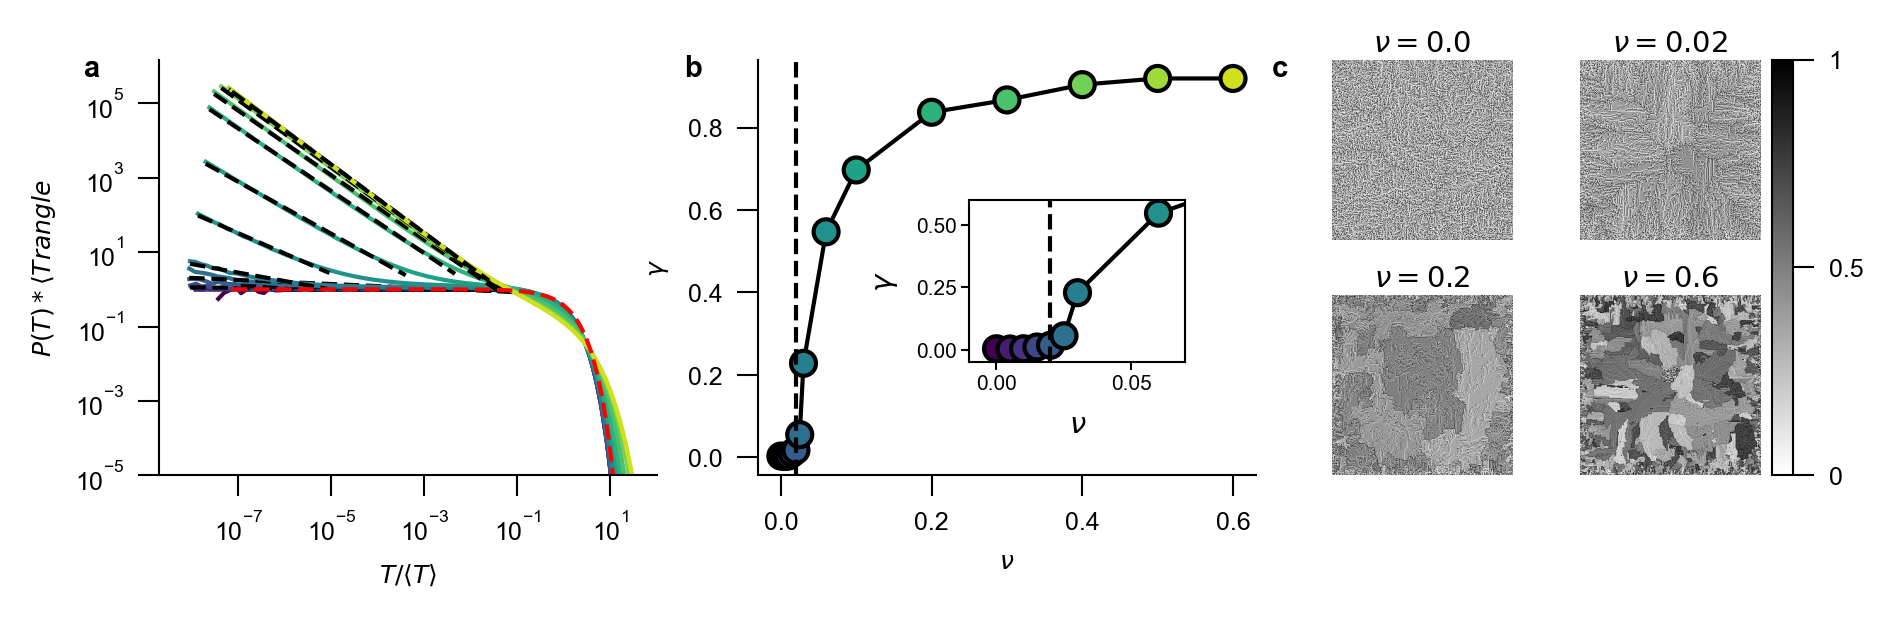

In [8]:
with plt.style.context(spstyle.get_style('nature-reviews')):
    print(spstyle.get_style('nature-reviews'))
    plt.rcParams['font.family'] = 'Arial' 
    fig = plt.figure(figsize=(7.2, 1.8))
    gs1 = gridspec.GridSpec(2, 5, width_ratios=[0.4,0.4,0.1,0.1,0.02], hspace=0.3, wspace=0.4)
    gs2 = gridspec.GridSpec(2, 5, width_ratios=[0.36,0.36,0.15,0.15,0.02], hspace=0.3, wspace=0.05)
    NCURVEs = len(Tpdf)
    colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
    
    ax1 = fig.add_subplot(gs1[:, 0])  # La figure 1 prend toute la largeur (2 colonnes)
    for j, (histo, xfit, yfit) in enumerate(zip(Tpdf, Txfit, Tyfit)):
        ax1.plot(histo[:,0], histo[:, 1], color = colors[j])
        ax1.plot(xfit,yfit, 'k--')
        
    poisson = gamma_distribution(histo[:,0], 1, -0.0, 1.)
    ax1.plot(histo[:,0], poisson, linestyle = '--', color = 'red')
    
    ax2 = fig.add_subplot(gs1[:, 1])
    ax2.plot(Tvar, -Tgamma, linestyle = '-', c = 'k', zorder=1, )
    ax2.scatter(Tvar, -Tgamma, c = colors[:], zorder=2, marker = 'o')
    ax2.axvline(Tvar[4], linestyle = '--', c = 'k', label = '{}'.format(Tvar[3]), zorder = 2)

    ax22 = fig.add_axes([0.5, 0.32, 0.1, 0.3])
    ax22.plot(Tvar, -Tgamma, linestyle = '-', c = 'k', zorder=1)
    ax22.scatter(Tvar, -Tgamma, c = colors[:], zorder=2, marker = 'o')
    ax22.axvline(Tvar[4], linestyle = '--', c = 'k', label = '{}'.format(Tvar[3]), zorder = 2)
    
    ax31 = fig.add_subplot(gs2[0, 2])
    ax31.imshow(sys1, cmap = "binary")
    ax31.set_title(r"$\nu = 0.0$", pad = 2, fontsize = 7)
    
    ax32 = fig.add_subplot(gs2[0, 3])
    ax32.imshow(sys2, cmap = "binary")
    ax32.set_title(r"$\nu = 0.02$", pad = 2, fontsize = 7)
    
    ax33 = fig.add_subplot(gs2[1, 2])
    ax33.imshow(sys3, cmap = "binary")
    ax33.set_title(r"$\nu = 0.2$", pad = 2, fontsize = 7)
    
    ax34 = fig.add_subplot(gs2[1, 3])
    im = ax34.imshow(sys4, cmap="binary")
    ax34.set_title(r"$\nu = 0.6$", pad = 2, fontsize = 7)

    pos = ax34.get_position()
    # Place colorbar to the right of ax34
    cax = fig.add_axes([pos.x1 + 0.005, pos.y0, 0.01, 2.3*pos.height])  # [x0, y0, width, height]
    cbar = plt.colorbar(im, cax=cax, ticks=[0, 0.5, 1.0])
    cbar.set_ticks([0,0.5,1.0])
    cbar.set_ticklabels(['0', '0.5', '1'])
    
    
    ax1.set_xlim(2e-9, 1e2)
    ax1.set_ylim(1e-5, 1.5e6)
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel(r'$T/ \langle T \rangle$')
    ax1.set_ylabel(r'$P(T) * \langle T rangle$')
    
    ax2.set_xlabel( r'$\nu$')
    ax2.set_ylabel(r'$\gamma$')
    
    ax22.set_xlim(-0.01,0.07)
    ax22.set_ylim(-0.05,0.6)
    ax22.set_xlabel( r'$\nu$', fontsize=7)
    ax22.set_ylabel(r'$\gamma$', fontsize=7)
    ax22.spines['top'].set_visible(True)
    ax22.spines['right'].set_visible(True)
    ax22.tick_params(labelsize = 5, length = 2, pad = 1)
    
    ax31.set_axis_off()
    ax32.set_axis_off()
    ax33.set_axis_off()
    ax34.set_axis_off()
    fig.text(0.09, 0.85, "a", fontsize=7, fontweight="bold") 
    fig.text(0.368, 0.85, "b", fontsize=7, fontweight="bold") 
    fig.text(0.64, 0.85, "c", fontsize=7, fontweight="bold") 
    
    ax22.patch.set_alpha(0.0)
    fig.patch.set_alpha(0.0)
    fig.savefig("Fig3_nature.pdf", bbox_inches='tight', dpi = 300, pad_inches = 0)
    plt.show()
    
    
    

##  V3

In [2]:
data3_5 = np.load("/home/kduplat/Documents/Data/Pscript2/Thesis_figures/Savedata/Figure3_5.npz")
data3_4 = np.load("/home/kduplat/Documents/Data/Pscript2/Thesis_figures/Savedata/Figure3_4.npz")
data3_7 = np.load("/home/kduplat/Documents/Data/Pscript2/Thesis_figures/Savedata/Figure3_7.npz")

In [3]:
print(data3_5.files)
print(data3_4.files)
print(data3_7.files)

['nu', 't_nu0', 'p_t_nu0', 'xfit_nu0', 'yfit_nu0', 't_nu0_005', 'p_t_nu0_005', 'xfit_nu0_005', 'yfit_nu0_005', 't_nu0_01', 'p_t_nu0_01', 'xfit_nu0_01', 'yfit_nu0_01', 't_nu0_015', 'p_t_nu0_015', 'xfit_nu0_015', 'yfit_nu0_015', 't_nu0_02', 'p_t_nu0_02', 'xfit_nu0_02', 'yfit_nu0_02', 't_nu0_025', 'p_t_nu0_025', 'xfit_nu0_025', 'yfit_nu0_025', 't_nu0_03', 'p_t_nu0_03', 'xfit_nu0_03', 'yfit_nu0_03', 't_nu0_06', 'p_t_nu0_06', 'xfit_nu0_06', 'yfit_nu0_06', 't_nu0_1', 'p_t_nu0_1', 'xfit_nu0_1', 'yfit_nu0_1', 't_nu0_2', 'p_t_nu0_2', 'xfit_nu0_2', 'yfit_nu0_2', 't_nu0_3', 'p_t_nu0_3', 'xfit_nu0_3', 'yfit_nu0_3', 't_nu0_4', 'p_t_nu0_4', 'xfit_nu0_4', 'yfit_nu0_4', 't_nu0_5', 'p_t_nu0_5', 'xfit_nu0_5', 'yfit_nu0_5', 't_nu0_6', 'p_t_nu0_6', 'xfit_nu0_6', 'yfit_nu0_6', 'gamma', 'yperr', 't_dearcangelis', 'p_t_dearcangelis', 'L', 'system1', 'system2', 'system3', 'system4']
['system', 'L', 'last_epicenter_x_y', 'next_epicenter_x_y', 'side_view_before', 'side_view_after']
['L', 'system1', 'epicenter1'

In [6]:
Tnu = data3_5["nu"]

Tp_t = [None] * len(Tnu)
Tt = [None] * len(Tnu)
Txfit = [None] * len(Tnu)
Tyfit = [None] * len(Tnu)



for i, nu in enumerate(Tnu):
    nu_str = str(nu).replace('.', '_')
    if i == 0: nu_str = "0"

    Tp_t[i] = data3_5[f"p_t_nu{nu_str}"]
    Tt[i] = data3_5[f"t_nu{nu_str}"]
    Txfit[i] = data3_5[f"xfit_nu{nu_str}"]
    Tyfit[i] = data3_5[f"yfit_nu{nu_str}"]
    

Tgamma = data3_5["gamma"]

L = data3_4["L"]
sys_snap = data3_4["system"].reshape(L,L)
last_epi = data3_4["last_epicenter_x_y"]
next_epi = data3_4["next_epicenter_x_y"]
sideview_before = data3_4["side_view_before"]
sideview_after = data3_4["side_view_after"]

snap_cons = data3_7["system1"].reshape(L,L)
epi_cons =  np.unravel_index(data3_7["epicenter1"], (L,L))
snap_diss = data3_7["system3"].reshape(L,L)
epi_diss = np.unravel_index(data3_7["epicenter3"],(L,L))

In [79]:
nrows = len(epi_cons[0])
colors = [plt.cm.get_cmap('plasma')(i/nrows) for i in range(nrows)]

nrows_tp = len(Tnu)
colors_pt = [plt.cm.get_cmap('viridis')(i/nrows_tp) for i in range(nrows_tp)]

/tmp/ipykernel_147002/3795462054.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('plasma')(i/nrows) for i in range(nrows)]
/tmp/ipykernel_147002/3795462054.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors_pt = [plt.cm.get_cmap('viridis')(i/nrows_tp) for i in range(nrows_tp)]


/home/kduplat/Documents/py38/lib/python3.8/site-packages/sciplotlib/stylesheets/nature-reviews.mplstyle


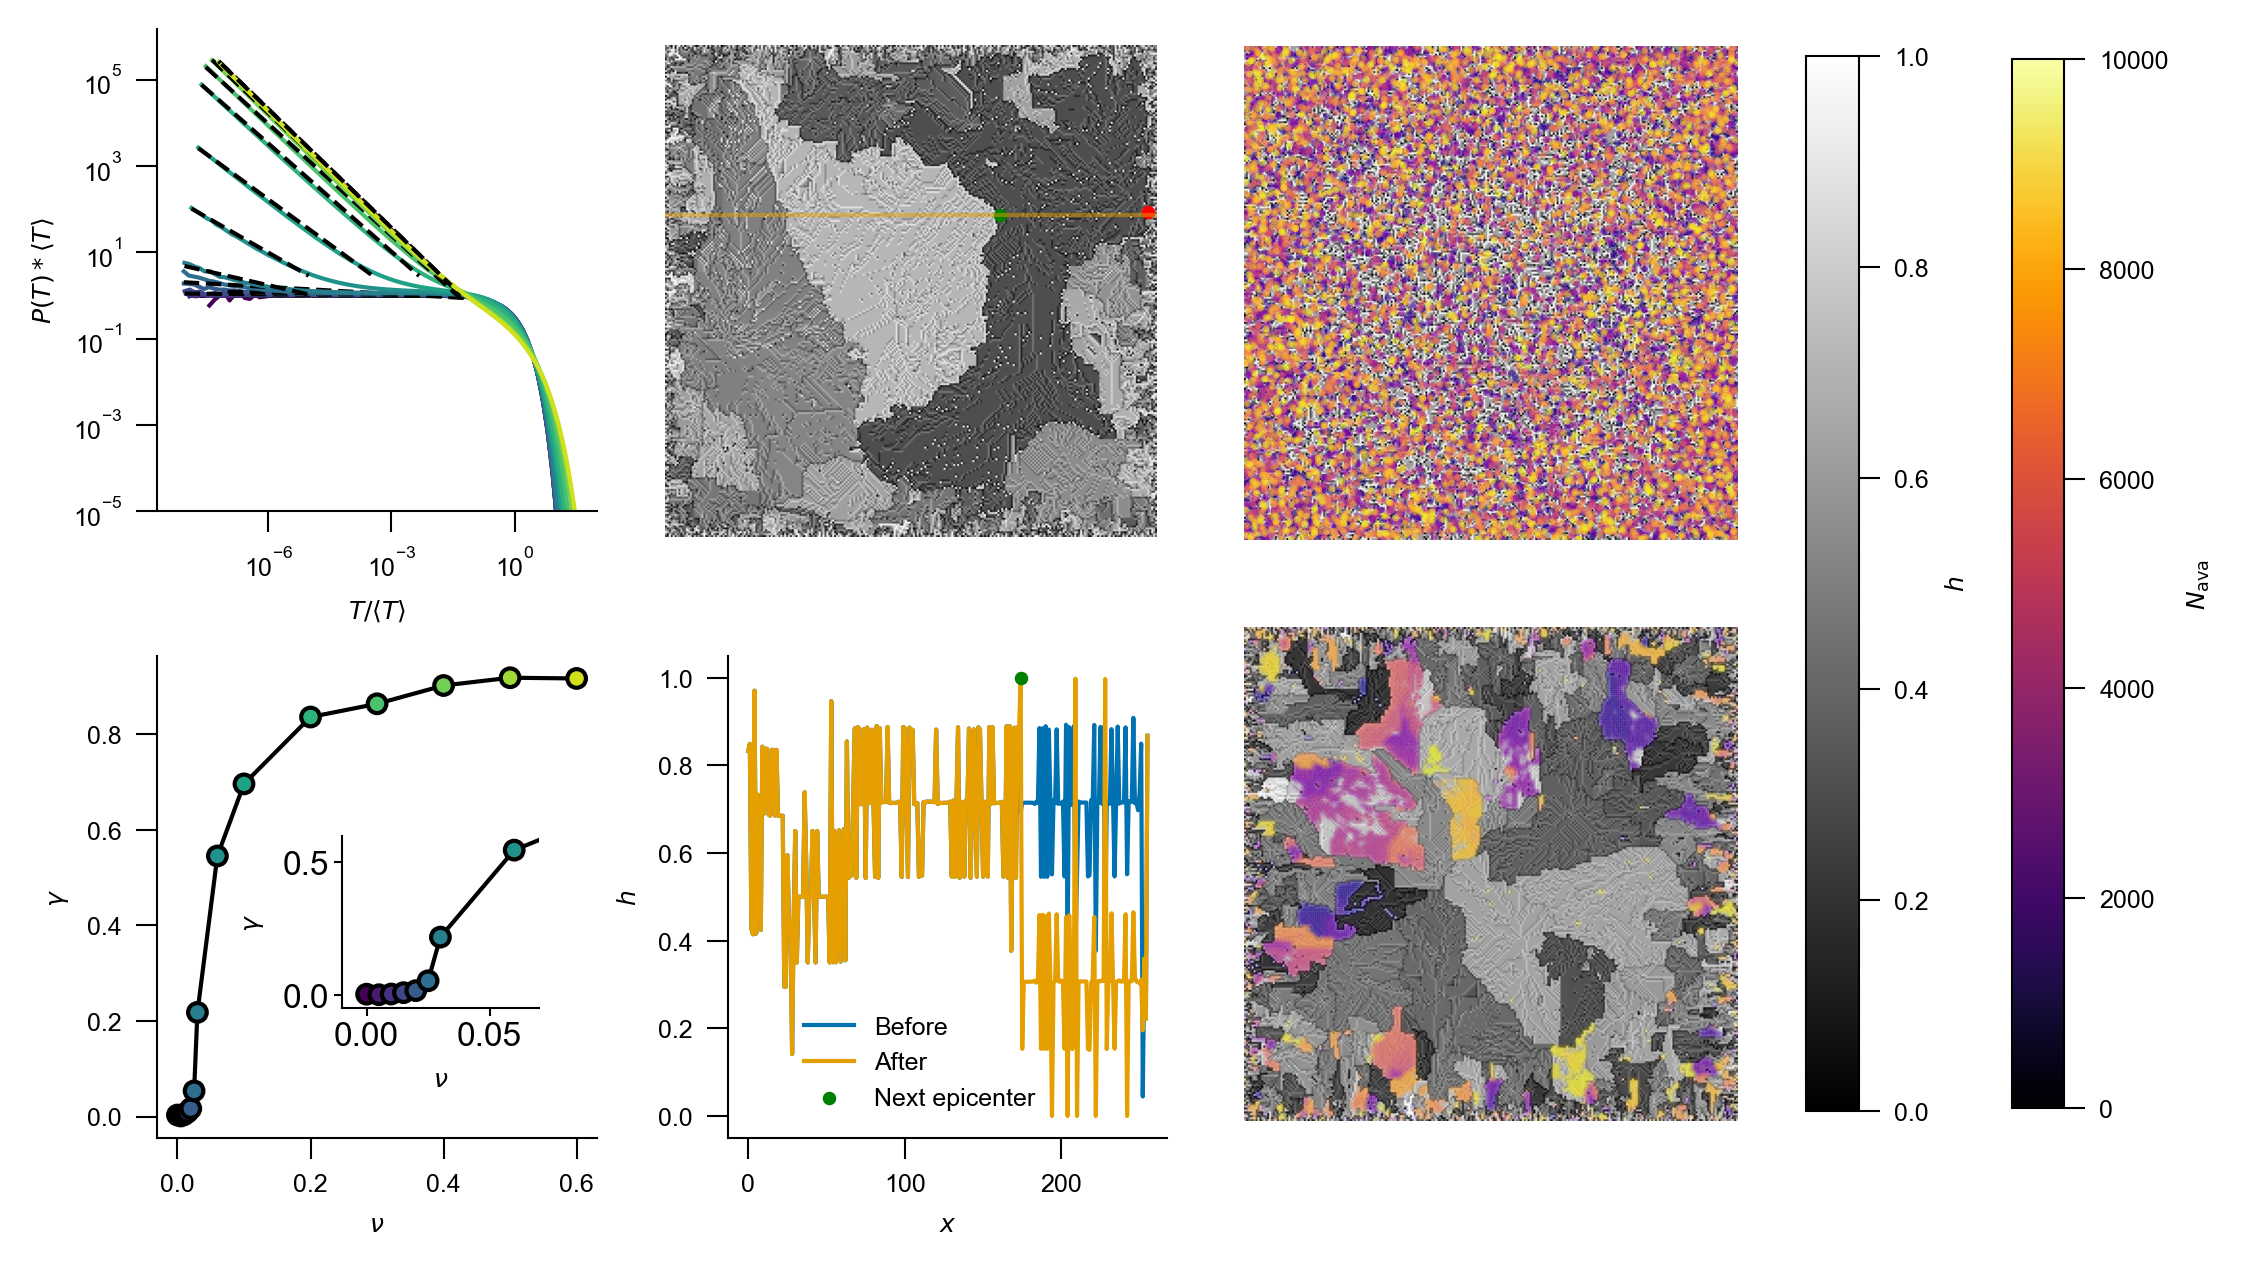

In [80]:
with plt.style.context(spstyle.get_style('nature-reviews')):
    print(spstyle.get_style('nature-reviews'))
    fig = plt.figure(figsize=(8.2, 4.8))
    
    gs1 = gridspec.GridSpec(2, 3, wspace = 0.3, hspace = 0.3)
    gs2 = gridspec.GridSpec(2, 3, wspace = 0.1, hspace = 0.1)
    gs3 = gridspec.GridSpec(2, 3, width_ratios=[0.27,0.4,0.33], height_ratios=[0.52,0.48], wspace = 0.43, hspace = 0.2)
    
    ax1 = fig.add_subplot(gs1[0, 0])
    ax2 = fig.add_subplot(gs1[1, 0])
    ax3 = fig.add_subplot(gs1[1, 1])
    ax4 = fig.add_subplot(gs3[0, 1])
    ax5 = fig.add_subplot(gs2[0, 2])
    ax6 = fig.add_subplot(gs2[1, 2])
    
    ax32 = fig.add_axes([0.2, 0.2, 0.08, 0.12])
    
    for i in range(len(Tnu)):
        ax1.plot(Tt[i],Tp_t[i], c = colors_pt[i])
        ax1.plot(Txfit[i],Tyfit[i], c ='k', ls = '--')
    
    im = ax4.imshow(sys_snap, cmap = 'gray', vmin = 0, vmax = 1)
    ax4.axhline(next_epi[1], c = color_list[2], alpha = 0.5)
    ax4.scatter(last_epi[0], last_epi[1], color = 'r', s = 5)
    ax4.scatter(next_epi[0], next_epi[1], color = 'g', s = 5)
    
    
    
    ax5.imshow(snap_cons, cmap ='binary', vmin = 0, vmax = 1)
    ax5.scatter(epi_cons[1], epi_cons[0], color = colors, s = 0.5, alpha = 0.5)
    
    ax2.scatter(Tnu, -Tgamma, c = colors_pt, s = 20, zorder = 10)
    ax2.plot(Tnu, -Tgamma, ls = '-', c ='k')
    ax32.scatter(Tnu, -Tgamma, c = colors_pt, s = 20, zorder = 10)
    ax32.plot(Tnu, -Tgamma, ls = '-', c ='k')
    
    ax32.tick_params(labelsize = 8, length = 2, pad = 1)
    ax3.plot(sideview_before, c = color_list[0], label = "Before")
    ax3.plot(sideview_after, c = color_list[2], label = "After")
    ax3.scatter(next_epi[0], sideview_after[next_epi[0]], color = 'g', s = 5, zorder = 2, label = "Next epicenter")
    
    ax6.imshow(snap_diss, cmap ='binary', vmin = 0, vmax = 1)
    ax6.scatter(epi_diss[1], epi_diss[0], color = colors, s = 0.5, alpha = 0.1)
    
    norm = plt.Normalize(0, nrows)
    sm = plt.cm.ScalarMappable(cmap='inferno', norm=norm)
    sm.set_array([])
    
    axes = [ax1, ax2, ax3, ax4, ax5, ax6]

    cbar = fig.colorbar(sm, ax=axes, location='right',
                        fraction=0.0275, aspect=20, pad=0.08)

    cbar2 = fig.colorbar(im, ax=axes, location='right',
                        fraction=0.031, aspect=20, pad=0.04)
    cbar.set_label(r"$N_{\mathrm{ava}}$")
    cbar2.set_label(r"$h$")
    
    
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.set_xlim(2e-9, 1e2)
    ax1.set_ylim(1e-5, 1.5e6)
    ax1.set_xlabel(r"$T / \langle T \rangle$")
    ax1.set_ylabel(r"$P(T)*\langle T \rangle$")
    ax4.set_axis_off()
    ax5.set_axis_off()
    ax2.set_xlabel(r"$\nu$")
    ax2.set_ylabel(r"$\gamma$")
    ax32.set_xlabel(r"$\nu$")
    ax32.set_ylabel(r"$\gamma$")
    ax32.set_xlim(-0.01,0.07)
    ax32.set_ylim(-0.05,0.6)
    ax3.set_xlabel(r"$x$")
    ax3.set_ylabel(r"$h$")
    ax3.legend(bbox_to_anchor = (0.75,0.3))
    ax6.set_axis_off()
    plt.savefig("Fig_loc_prev.pdf", dpi = 300)
    plt.show()

#   Extended data 3 (fss)

##  64

In [2]:
Tfolderpath = ["/data1/DATA_Duplat/Brut/Cut_off_size/Cu5n{}".format(nb) for nb in [1,11]]
Tnu64 = [read_parameters(folder)[2] for folder in Tfolderpath]

results64 = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder)) for folder in Tfolderpath)
Thisto_s64, Tbins_s64, Tnonzero_s64, _, _ = zip(*results64)

##   128

In [3]:
Tfolderpath = [f'/data1/DATA_Duplat/Brut/Cut_off_size/Cu4n{nb}' for nb in [1,11]]
Tnu128 = [read_parameters(folder)[2] for folder in Tfolderpath]

results128 = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder)) for folder in Tfolderpath)
Thisto_s128, Tbins_s128, Tnonzero_s128, _, _ = zip(*results128)

##   256

In [4]:
Tfolderpath = ["/data1/DATA_Duplat/Brut/PDF/PD5n{}".format(nb) for nb in [1,11]]
Tnu256 = [read_parameters(folder)[2] for folder in Tfolderpath]

results256 = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder)) for folder in Tfolderpath)
Thisto_s256, Tbins_s256,  Tnonzero_s256, _, _ = zip(*results256)

##   512

In [5]:
Tfolderpath = ["/data1/DATA_Duplat/Brut/Cut_off_size/Cu6n1"] + ["/data1/DATA_Duplat/Brut/Cut_off_size/Cu2n{}".format(nb) for nb in [2]]
Tnu512 = [read_parameters(folder)[2] for folder in Tfolderpath]
Tnbins = [50,0,0]

results512 = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder), nbins) for (folder, nbins) in zip(Tfolderpath, Tnbins))
Thisto_s512, Tbins_s512, Tnonzero_s512, _, _ = zip(*results512)

##  Recap

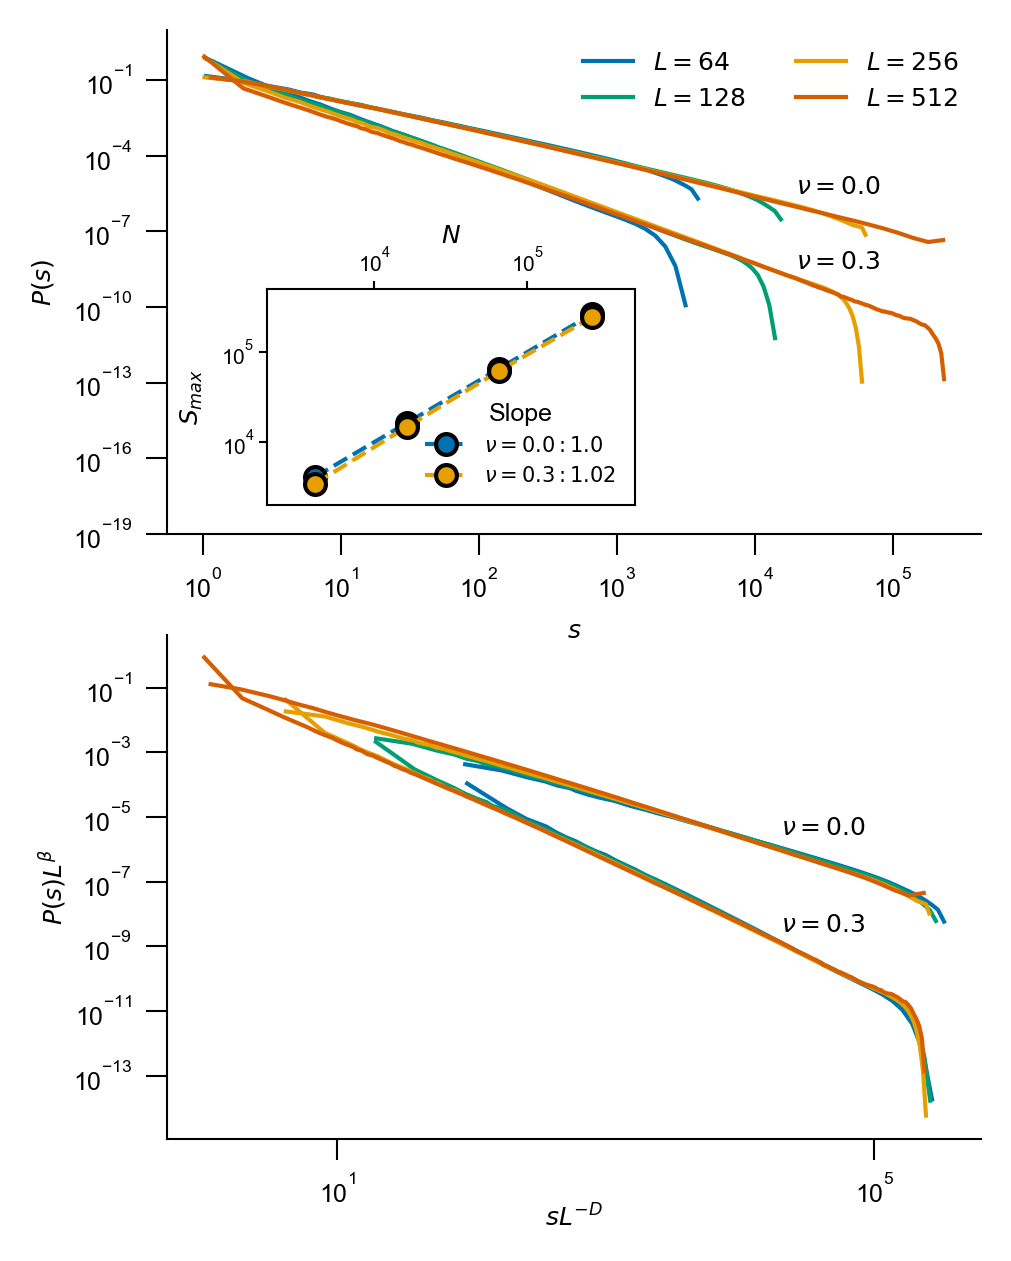

In [15]:


with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax, ax3) = plt.subplots(2,1, figsize = (3.5,4.8))
    mask = [0,10]
    mask2 = [0,2]
    leg1, leg2, leg3 = 0,0,0
    for i, (histo, bins, nu) in enumerate(zip(Thisto_s64, Tbins_s64, np.array(Tnu64))):
        if i == 0:
            leg1 = ax.plot(bins,histo, color = color_list[5], label = '$L = 64$')[0]
        else:
            ax.plot(bins,histo, color = color_list[5])
    for i, (histo, bins, nu) in enumerate(zip(Thisto_s128, Tbins_s128, np.array(Tnu128))):
        if i == 0:
            leg2 = ax.plot(bins,histo, color = color_list[3], label = '$L = 128$')[0]
        else:
            ax.plot(bins,histo, color = color_list[3])
    for i, (histo, bins, nu) in enumerate(zip(Thisto_s256, Tbins_s256, np.array(Tnu256))):
        if i == 0:
            leg3 = ax.plot(bins,histo, color = color_list[1], label = '$L = 256$')[0]
        else:
            ax.plot(bins,histo, color = color_list[1])
    
    
    for i, (histo, bins, nu) in enumerate(zip(Thisto_s512, Tbins_s512, np.array(Tnu512))):
        if i == 0:
            leg4 = ax.plot(bins,histo, color = color_list[6], label = '$L = 512$')[0]
        else:
            ax.plot(bins,histo, color = color_list[6])
    
    
    
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$s$')
    ax.set_ylabel(r'$P(s)$')
    ax.set_ylim(10**-19, 10)
    
    
    S_cut_off_min = np.array([Tnonzero_s64[0], Tnonzero_s128[0], Tnonzero_s256[0], Tnonzero_s512[0]])
    S_cut_off_min2 = np.array([Tnonzero_s64[1], Tnonzero_s128[1], Tnonzero_s256[1], Tnonzero_s512[1]])
    L = np.array([64, 128, 256, 512])
    LL = L*L

    popt, _ = curve_fit(powerlaw2, np.log(LL), np.log( S_cut_off_min))
    a, b = popt
    y_fit = np.exp(powerlaw2(np.log(LL), a, b))

    popt2, _ = curve_fit(powerlaw2, np.log(LL), np.log(S_cut_off_min2))
    a2, b2 = popt2
    y_fit2 = np.exp(powerlaw2(np.log(LL), a2, b2))
    
    # ax2 = fig.add_axes([0.18, 0.205, 0.15, 0.30])
    ax2 = fig.add_axes([0.22, 0.55, 0.35, 0.15])
    ax2.plot(LL, S_cut_off_min, marker = 'o', ls = '--', ms = 5, lw = 1, c = color_list[5], label = r'$\nu = 0.0: {}$'.format(np.round(b, 2)))
    
    ax2.plot(LL, S_cut_off_min2, marker = 'o', ls = '--', ms = 5, lw = 1, c = color_list[1], label = r'$\nu = 0.3: {}$'.format(np.round(b2, 2)))
    
    ax2.set_xlabel(r'$N$', fontsize = 6)
    ax2.set_ylabel(r'$S_{max}$', fontsize = 6)
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.tick_params(labelsize = 5, length = 2, pad = 1) 
    ax2.tick_params(length = 0, which = 'minor')
    ax2.spines['top'].set_visible(True)
    ax2.spines['right'].set_visible(True)
    ax2.xaxis.labelpad = 1
    ax2.xaxis.tick_top()
    ax2.xaxis.set_label_position('top')
    ax2.set_xlim(2e3, 5e5)
    ax2.set_ylim(2e3, 5e5)
    ax2.patch.set_alpha(0.0)
    ax2.legend(fontsize = 5, title = 'Slope', loc = "lower right")

    
    #######RESCALED
    mask = [0,10]
    mask2 = [0,2]
    
    alpha = 2.2
    beta = np.array([2.8, 4.2])

    xscale = (64**-alpha)*(1/(Tbins_s512[0][0]*(512**-alpha)))
    yscale = (64**beta)*(1/(512**beta))
    
    for i, (histo, bins, nu) in enumerate(zip(Thisto_s64, Tbins_s64, np.array(Tnu64))):
        bins = bins * xscale
        histo = histo * yscale[i]
        ax3.plot(bins,histo, color = color_list[5], label = '$L = 64$', lw = 1)[0]
            
    xscale = (128**-alpha)*(1/(Tbins_s512[0][0]*(512**-alpha)))
    yscale = (128**beta)*(1/(512**beta))
    for i, (histo, bins, nu) in enumerate(zip(Thisto_s128, Tbins_s128, np.array(Tnu128))):
        bins = bins * xscale
        histo = histo * yscale[i]
        ax3.plot(bins,histo, color = color_list[3], label = '$L = 128$', lw = 1)[0]

    xscale = (256**-alpha)*(1/(Tbins_s512[0][0]*(512**-alpha)))
    yscale = (256**beta)*(1/(512**beta))
    for i, (histo, bins, nu) in enumerate(zip(Thisto_s256, Tbins_s256, np.array(Tnu256))):
        bins = bins * xscale
        histo = histo * yscale[i]
        ax3.plot(bins,histo, color = color_list[1], label = '$L = 256$', lw = 1)[0]
    
    for i, (histo, bins, nu) in enumerate(zip(Thisto_s512, Tbins_s512, np.array(Tnu512))):
        ax3.plot(bins,histo, color = color_list[6], label = '$L = 512$', lw = 1)[0]
    
    
    ax3.set_xlabel(r'$sL^{-D}$', fontsize = 6)
    ax3.set_ylabel(r'$P(s)L^{\beta}$', fontsize = 6)
    ax3.set_xscale('log')
    ax3.set_yscale('log')
    ax3.xaxis.labelpad = -1
    ax3.yaxis.labelpad = 1
    ax3.set_xticks([10**1, 10**5])
    ax3.patch.set_alpha(0.0)
    
    ax.text(2.e4, 2e-6, r"$\nu = 0.0$", fontsize = 6, fontname = 'Arial', color="k", va="bottom")
    ax.text(2.e4, 2e-9, r"$\nu = 0.3$", fontsize = 6, fontname = 'Arial', color="k", va="bottom")
    
    ax3.text(2.e4, 2e-6, r"$\nu = 0.0$", fontsize = 6, fontname = 'Arial', color="k", va="bottom")
    ax3.text(2.e4, 2e-9, r"$\nu = 0.3$", fontsize = 6, fontname = 'Arial', color="k", va="bottom")
    
    # fig.text(0.08, 0.85, "a", fontsize=7, fontweight="bold") 
    # fig.text(0.5, 0.85, "b", fontsize=7, fontweight="bold")
    
    
    ax.legend(handles=[leg1, leg2, leg3, leg4], ncols = 2, loc = "upper right")
    
    fig.patch.set_alpha(0.0)
    plt.savefig('Ext_data_fig2_PRX.pdf', bbox_inches='tight', dpi = 300)    
    plt.show()

    

#   Fig Inter-time

In [3]:
def process_meantime_th(folder, minsize, limdata = 1e9):

    csize = 1e7
    nbdata = 0
    
    lasttime = 0
    last_filtered_time = 0
    norm = 0
    suminter  = 0
    
    for chunk in chunked_file_reader(f'{folder}/Avalanche_outputB.gz', chunksize=csize, usecols = [1,3]):
        
        time = np.array(np.cumsum(chunk.iloc[:, 1])) + lasttime #rebuild the time scale starting from zero using dz
        lasttime = time[-1]  #Save the time for the next chunk
        # filterd_chunk = chunk.iloc[:, 1][chunk.iloc[:, 0] >= minsize]
        
        filtered_time = time[chunk.iloc[:, 0] >= minsize] #Keep only the avalanches with a size above a threshold
        filtered_time = np.insert(filtered_time, 0, last_filtered_time) #add to the array the time of the last avalanches from the previous chunk
        last_filtered_time = filtered_time[-1]  #Keep the time of the last avalanches for the next chunk
        
        if(len(filtered_time) > 0):
            time_inter = np.diff(filtered_time)
            
            suminter += np.sum(time_inter)
            norm += len(time_inter)
            
        nbdata+=len(time)
        
        if nbdata >= limdata: break
        
        
    # histo = histo/nbdata
    mean = suminter/norm
        
    return mean
        
        
def process_meantime(folder, nbins):
    histo = np.loadtxt(f"{folder}/stat_histoitime.txt", comments = "#")
    bins = np.logspace(np.log10(10**-12), np.log10(2), nbins)

    bin_centers = (bins[:-1] + bins[1:]) / 2
    mean = np.sum(histo * bin_centers) / np.sum(histo)
    
    return mean

In [4]:
folderpathbis = folderpath.copy()
for i in range(1,7):
    folderpathbis[i-1] = "/data1/DATA_Duplat/Brut/PDF/PD7n{}".format(i)
    
folderpathbis = np.insert(folderpathbis, 8, '/data1/DATA_Duplat/Brut/PDF/PD8n1')

##  S>1

In [15]:
folderpathbisbis = np.insert(folderpath, 8, '/data1/DATA_Duplat/Brut/PDF/PD8n1')
nbins = 1000
mean = Parallel(n_jobs=-1)(delayed(process_meantime)(folder, nbins + 1)
                                  for folder in folderpathbisbis)

##  S>1000

In [6]:
limdata = 1e8
minsize = 1000
mean1000 = Parallel(n_jobs=-1)(delayed(process_meantime_th)(folder, minsize, limdata)
                                  for folder in folderpathbis[:])

##  S>N/10

In [7]:
limdata = 1e8
minsize = (L1 * L2)/10
meanN10 = Parallel(n_jobs=-1)(delayed(process_meantime_th)(folder, minsize, limdata)
                                  for folder in folderpathbis[:])

##  S1000/S1

15
15
15


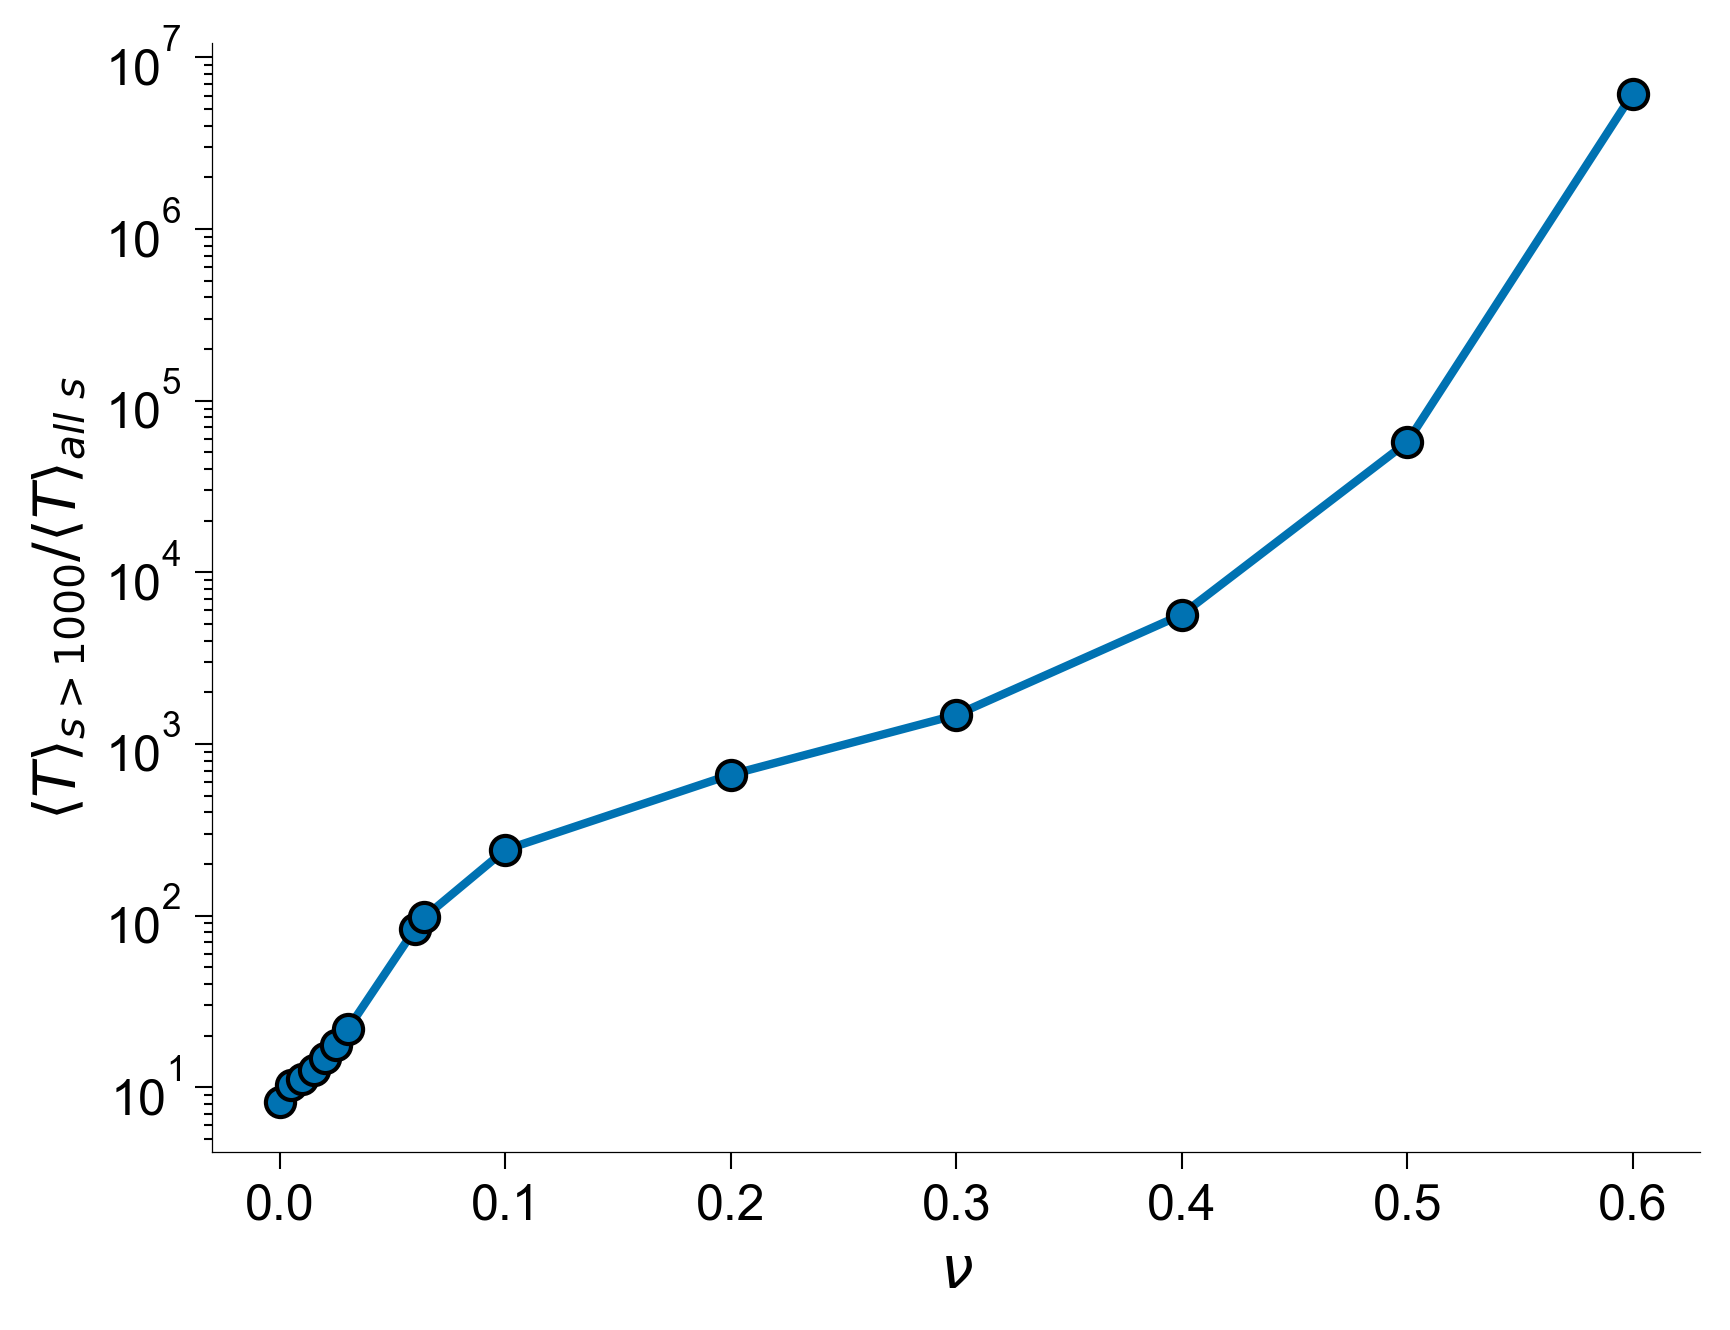

In [ ]:
Tvarbis= np.insert(Tvar, 8, read_parameters(folderpathbis[8])[2])

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, ax = plt.subplots(figsize = (6.4, 4.8))

    plt.plot(Tvarbis, np.array(mean1000)/np.array(mean), marker = 'o', color = '#0072b2', label = r"$s \geq  1000$")

    plt.yscale("log")
    plt.xlabel(r"$\nu$")
    plt.ylabel(r"$\langle T \rangle_{s > 1000} / \langle T \rangle_{all~s}$",)

    # plt.legend(fontsize = 20)
    """ plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) """
    plt.savefig('FigT1000overT1.pdf', dpi = 300)
    plt.show()

##  SN10/S1

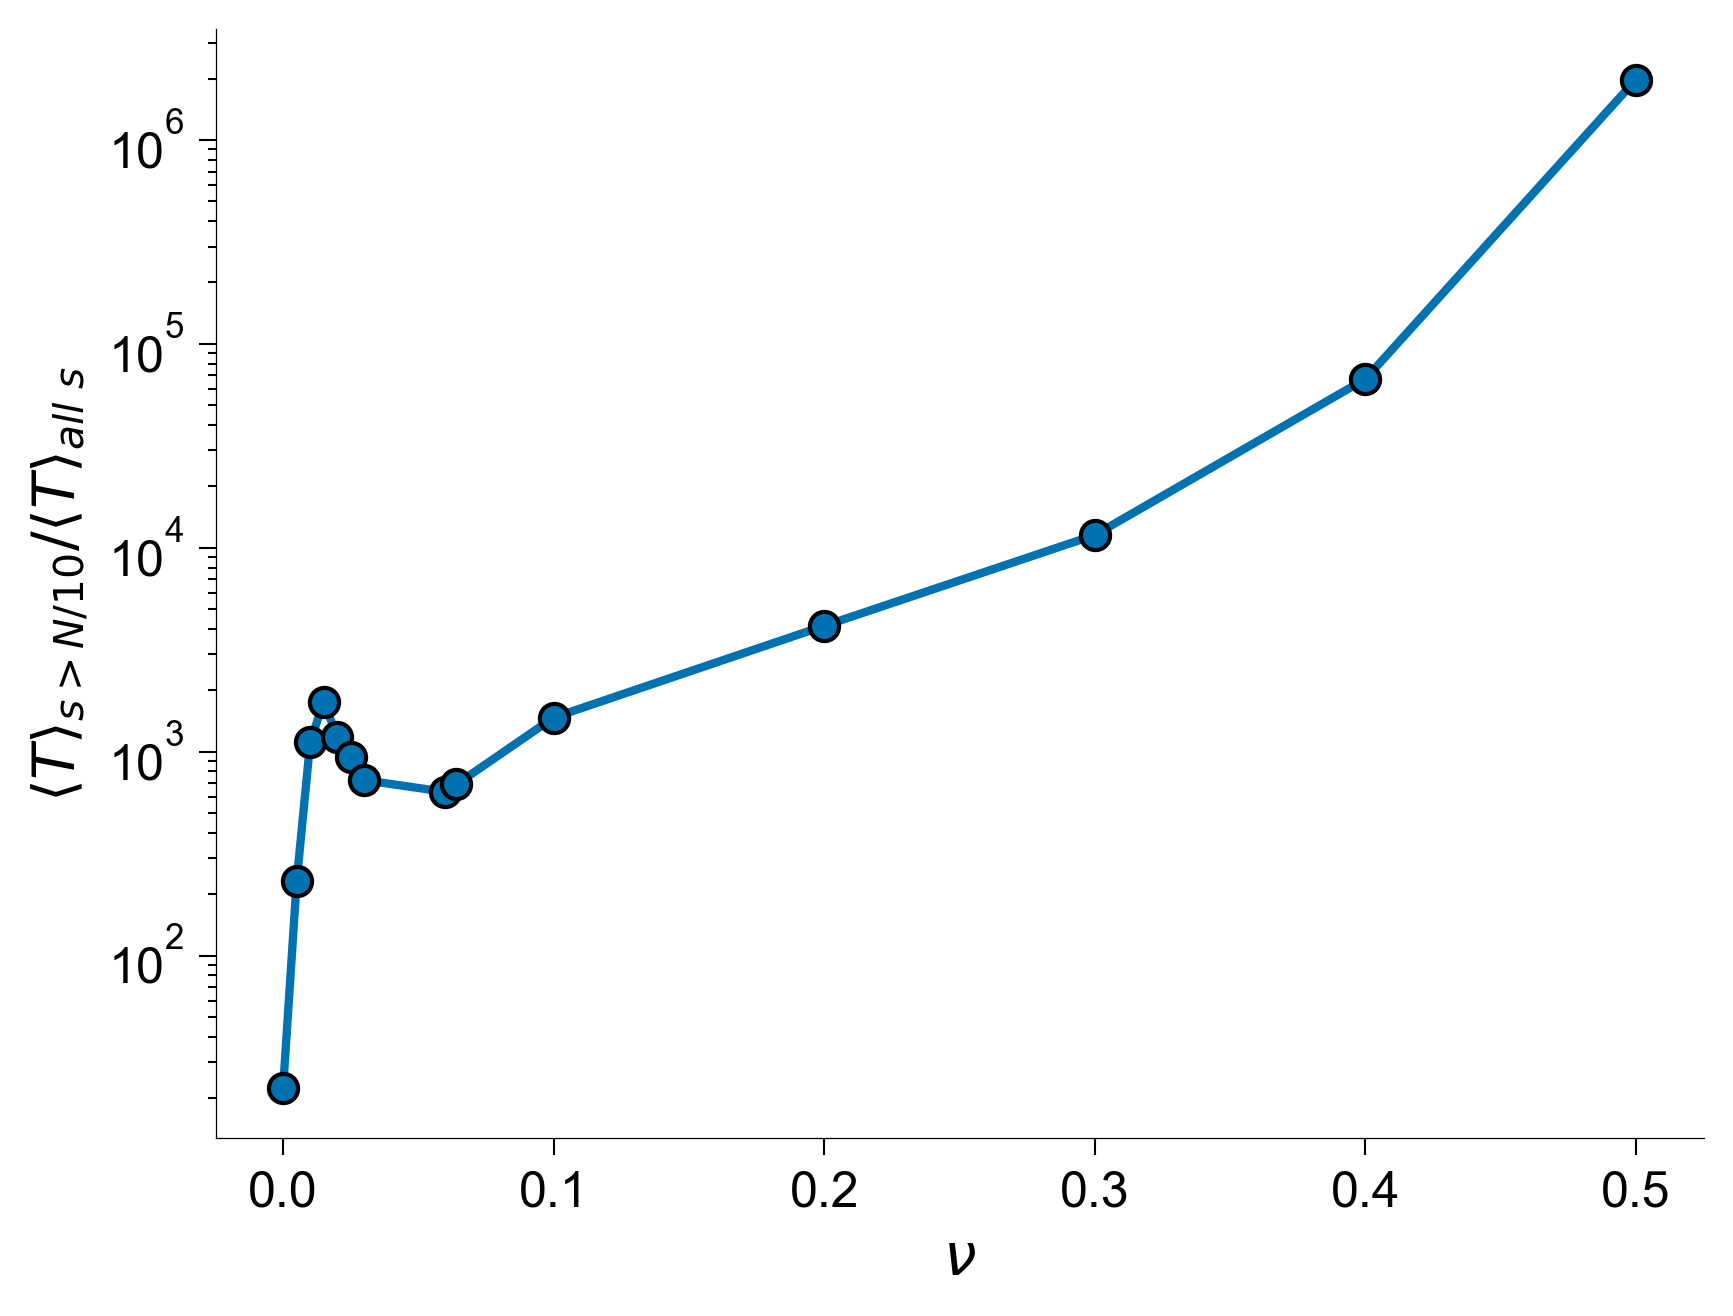

In [18]:
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, ax = plt.subplots(figsize = (6.4, 4.8))

    plt.plot(Tvarbis, np.array(meanN10)/np.array(mean), marker = 'o', color = '#0072b2', label = r"$s \geq  N/10$")

    plt.yscale("log")
    plt.xlabel(r"$\nu$")
    plt.ylabel(r"$\langle T \rangle_{s > N/10} / \langle T \rangle_{all~s}$",)

    # plt.legend(fontsize = 20)
    """ plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) """
    plt.savefig('FigTN10overT1.pdf', dpi = 300)
    plt.show()

#   Extended data fig 4 (Rd topple)

## Random toppling no incrementation

In [97]:
fnb = np.arange(1,5)
folderpath = [f'/data1/DATA_Duplat/Brut/Rdtopple/Rd3n{nb}' for nb in fnb]
folderpath = np.array(['/data1/DATA_Duplat/Brut/PDF/PD5n1'] + folderpath)
folderpath = np.insert(folderpath, 2, ['/data1/DATA_Duplat/Brut/Rdtopple/Rd5n1', '/data1/DATA_Duplat/Brut/Rdtopple/Rd4n1'])
Tvar_rt = [read_parameters(folder)[2] for folder in folderpath]
Tvar_rt[4] = 0.06

In [99]:
# Thisto_rt, Tbins_rt, nmax_rt, mean_rt, nbins_rt = np.array(Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder)) for folder in folderpath)).T
result = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder)) for folder in folderpath)
Thisto_rt, Tbins_rt, nmax_rt, mean_rt, nbins_rt = zip(*result)

## Normal toppling, no incrementation

In [61]:
fnb = np.arange(1,7)
folderpath = ['/data1/DATA_Duplat/Brut/PDF/PD5n1'] + [f'/data1/DATA_Duplat/Brut/Rdtopple/Rd6n{nb}' for nb in fnb]
folderpath = np.insert(folderpath, 2, '/data1/DATA_Duplat/Brut/Rdtopple/Rd7n1')
Tvar_ni = [read_parameters(folder)[2] for folder in folderpath]


In [ ]:
Thisto_ni, Tbins_ni, nmax_ni, mean_ni, nbins_ni = np.array(Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder)) for folder in folderpath)).T

<ipython-input-62-c07f1609acda>:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  Thisto_ni, Tbins_ni, nmax_ni, mean_ni, nbins_ni = np.array(Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder)) for folder in folderpath)).T


##  Intertime

In [100]:
nbins = 1000
folerpath_random = ['/data1/DATA_Duplat/Brut/PDF/PD5n1']+['/data1/DATA_Duplat/Brut/Rdtopple/Rd8n{}'.format(i) for i in [1,2,4,5,6,7]]
Tvar_rt_it = [read_parameters(folder)[2] for folder in folerpath_random]

results_it = np.array(Parallel(n_jobs=-1)(delayed(process_time_from_histo)(folder, nbins + 1)
                                  for folder in folerpath_random))


In [102]:
Tstart_x = [1e-7,1e-6,1e-7,2e-7,1e-7,
           1e-7,1e-7]

Tstop_x = [1e-2,5e-2,5e-3,1e-3,5e-3,
        1e-2,1]

nb_reduced_bins = 50

Tpdf, Txfit, Tyfit, Tgamma, Tperr =  PDF_it_histogram(results_it, Tstart_x, Tstop_x, nb_reduced_bins)

In [103]:
sys1 = np.loadtxt("/data1/DATA_Duplat/Brut/Rdtopple/Rd3n1/Snapshots/nav100000000_outputB.txt", comments='#').reshape(L1, L2).T
sys2 = np.loadtxt("/data1/DATA_Duplat/Brut/Rdtopple/Rd3n2/Snapshots/nav10000000000_outputB.txt", comments='#').reshape(L1, L2).T
sys3 = np.loadtxt("/data1/DATA_Duplat/Brut/Rdtopple/Rd3n3/Snapshots/nav100000000000_outputB.txt", comments='#').reshape(L1, L2).T

##  Recap

/tmp/ipykernel_916351/2116297170.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors_rt = [plt.cm.get_cmap('viridis')(i/NCURVES_rt) for i in range(NCURVES_rt)]


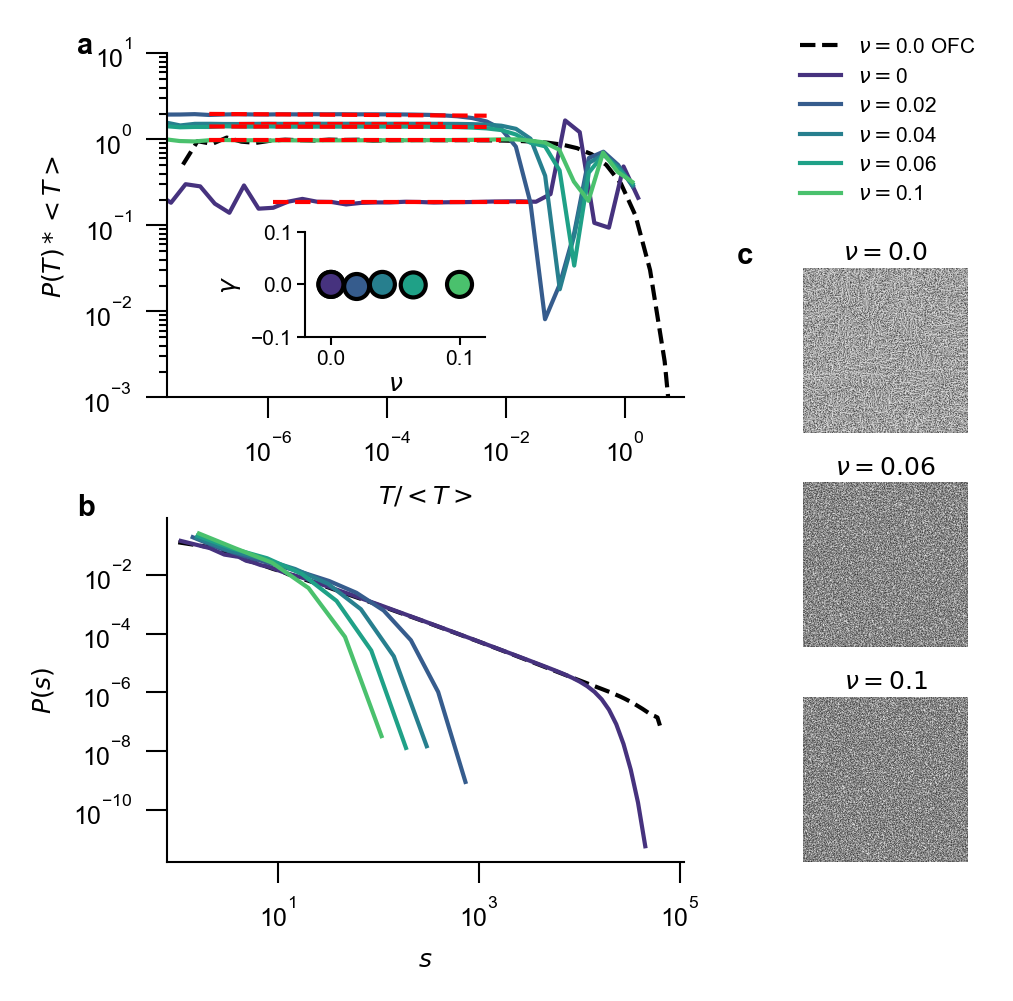

In [106]:
from matplotlib.gridspec import GridSpec
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig = plt.figure(figsize=(4, 3.5))
    
    gs1 = GridSpec(2, 2, height_ratios= [0.5,0.5], width_ratios=[0.55, 0.35], hspace = 0.35, wspace = 0.2)
    gs2 = GridSpec(4, 2, height_ratios= [0.25,0.25,0.25,0.25], wspace = 0.2, hspace = 0.3)

    ax1 = fig.add_subplot(gs1[1, 0])
    ax2 = fig.add_subplot(gs1[0, 0]) 
    ax3 = fig.add_subplot(gs2[1, 1]) 
    ax4 = fig.add_subplot(gs2[2, 1]) 
    ax5 = fig.add_subplot(gs2[3, 1]) 
    
    OFC = Thisto_rt[0]
    
    NCURVES_rt = len(Tvar_rt)
    colors_rt = [plt.cm.get_cmap('viridis')(i/NCURVES_rt) for i in range(NCURVES_rt)]
    
    
    for i, (histo, bins) in enumerate(zip(Thisto_rt[:-1], Tbins_rt[:-1])):
        if i == 0:
            ax1.plot(bins,histo, color = 'k', ls = '--', label = r'$\nu = $' + str(Tvar_rt[i]) + ' OFC')
        else: 
            ax1.plot(bins,histo, color = colors_rt[i], label = r'$\nu = $' + str(Tvar_rt[i]))
            
    for j, (histo, xfit, yfit) in enumerate(zip(Tpdf[:-1], Txfit[:-1], Tyfit[:-1])):
        if j == 0:
            ax2.plot(histo[:,0], histo[:, 1], color = 'k', ls = '--', label = r'$\nu = $' + str(Tvar_rt_it[j]) + ' OFC')
        else:
            ax2.plot(histo[:,0], histo[:, 1], color = colors_rt[j],  label = r'$\nu = $' + str(Tvar_rt_it[j]))
            ax2.plot(xfit, yfit, ls = '--', c = 'r')
            
    ax22 = fig.add_axes([0.24,0.61, 0.15,0.1])
    ax22.scatter(Tvar_rt_it[:-1], Tgamma[:-1], c = colors_rt[:-1])
    
    ax3.imshow(sys1, cmap = "binary")
    ax3.set_title(r"$\nu = 0.0$", fontsize = 6, pad = 2)
    
    ax4.imshow(sys2, cmap = "binary")
    ax4.set_title(r"$\nu = 0.06$", fontsize = 6, pad = 2)
    
    ax5.imshow(sys3, cmap = "binary")
    ax5.set_title(r"$\nu = 0.1$", fontsize = 6, pad = 2)
    
    # ax1.axvline(256 * 256, ls = '--', c = 'k')
    ax1.set_xlabel(r'$s$')
    ax1.set_ylabel(r'$P(s)$')
    ax1.set_xticks([1e0, 1e1, 1e2, 1e3, 1e4, 1e5])
    ax1.set_xlim(0.8,1.1e5)
    
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.legend(fontsize = 5, bbox_to_anchor=(1.6,2.45))
    
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xlabel(r'$T/<T>$')
    ax2.set_ylabel(r'$P(T) * <T>$')
    ax2.set_ylim(1e-3, 1e1)
    ax2.set_xlim(2e-8, 10)

    ax22.set_ylim(-0.1, 0.1)
    ax22.set_xlim(-0.02, 0.12)
    ax22.set_xlabel(r'$\nu$', fontsize = 6)
    ax22.set_ylabel(r'$\gamma$', fontsize = 6)
    ax22.xaxis.labelpad = 1
    ax22.yaxis.labelpad = 2
    ax22.tick_params(labelsize = 5, pad = 1, length = 2)
    
    
    ax3.set_axis_off()
    ax4.set_axis_off()
    ax5.set_axis_off()
    
    fig.text(0.05, 0.88, "a", fontsize=7, fontweight="bold") 
    fig.text(0.05, 0.44, "b", fontsize=7, fontweight="bold") 
    fig.text(0.6, 0.68, "c", fontsize=7, fontweight="bold") 
    
    ax22.patch.set_alpha(0.0)
    fig.patch.set_alpha(0.0)
    fig.savefig('Ext_data_fig3.pdf', bbox_inches = 'tight', dpi = 300)
    plt.show()
    

###  V2

In [ ]:
from matplotlib.gridspec import GridSpec

nbins = 1000
nb_reduced_bins = 50
bins = np.logspace(np.log10(10**-12), np.log10(2), nbins+1)
bin_centers = (bins[:-1] + bins[1:]) / 2
NCURVES_rt = len(Tvar_rt)

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig = plt.figure(figsize=(4, 3.5))
    
    gs1 = GridSpec(2, 2, height_ratios= [0.5,0.5], width_ratios=[0.55, 0.35], hspace = 0.35, wspace = 0.2)
    gs2 = GridSpec(4, 2, height_ratios= [0.25,0.25,0.25,0.25], wspace = 0.2, hspace = 0.3)

    ax1 = fig.add_subplot(gs1[1, 0])
    ax2 = fig.add_subplot(gs1[0, 0]) 
    ax3 = fig.add_subplot(gs2[1, 1]) 
    ax4 = fig.add_subplot(gs2[2, 1]) 
    ax5 = fig.add_subplot(gs2[3, 1]) 
    
    OFC = Thisto_rt[0]
    
    NCURVES_rt = len(Tvar_rt)
    colors_rt = [plt.cm.get_cmap('viridis')(i/NCURVES_rt) for i in range(NCURVES_rt)]
    
    
    for i, (histo, bins) in enumerate(zip(Thisto_rt[:-1], Tbins_rt[:-1])):
        if i == 0:
            ax1.plot(bins,histo, color = 'k', ls = '--', label = r'$\nu = $' + str(Tvar_rt[i]) + ' OFC')
        else: 
            ax1.plot(bins,histo/(histo[0]/OFC[0]), color = colors_rt[i], label = r'$\nu = $' + str(Tvar_rt[i]))
            
    for j, (histo, xfit, yfit) in enumerate(zip(Tpdf[:-1], Txfit[:-1], Tyfit[:-1])):
        if j == 0:
            ax2.plot(histo[:,0], histo[:, 1], color = 'k', ls = '--', label = r'$\nu = $' + str(Tvar_rt_it[j]) + ' OFC')
        else:
            ax2.plot(histo[:,0], histo[:, 1], color = colors_rt[j],  label = r'$\nu = $' + str(Tvar_rt_it[j]))
            ax2.plot(xfit, yfit, ls = '--', c = 'r')
            
    ax22 = fig.add_axes([0.24,0.61, 0.15,0.1])
    ax22.scatter(Tvar_rt_it[:-1], Tgamma[:-1], c = colors_rt[:-1])
    
    ax3.imshow(sys1, cmap = "binary")
    ax3.set_title(r"$\nu = 0.0$", fontsize = 6, pad = 2)
    
    ax4.imshow(sys2, cmap = "binary")
    ax4.set_title(r"$\nu = 0.06$", fontsize = 6, pad = 2)
    
    ax5.imshow(sys3, cmap = "binary")
    ax5.set_title(r"$\nu = 0.1$", fontsize = 6, pad = 2)
    
    # ax1.axvline(256 * 256, ls = '--', c = 'k')
    ax1.set_xlabel(r'$s$')
    ax1.set_ylabel(r'$P(s)$')
    ax1.set_xticks([1e0, 1e1, 1e2, 1e3, 1e4, 1e5])
    ax1.set_xlim(0.8,1.1e5)
    
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.legend(fontsize = 5, bbox_to_anchor=(1.6,2.45))
    
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xlabel(r'$T/<T>$')
    ax2.set_ylabel(r'$P(T) * <T>$')
    ax2.set_ylim(1e-3, 1e1)
    ax2.set_xlim(2e-8, 10)

    ax22.set_ylim(-0.1, 0.1)
    ax22.set_xlim(-0.02, 0.12)
    ax22.set_xlabel(r'$\nu$', fontsize = 6)
    ax22.set_ylabel(r'$\gamma$', fontsize = 6)
    ax22.xaxis.labelpad = 1
    ax22.yaxis.labelpad = 2
    ax22.tick_params(labelsize = 5, pad = 1, length = 2)
    
    
    ax3.set_axis_off()
    ax4.set_axis_off()
    ax5.set_axis_off()
    
    fig.text(0.05, 0.88, "a", fontsize=7, fontweight="bold") 
    fig.text(0.05, 0.44, "b", fontsize=7, fontweight="bold") 
    fig.text(0.6, 0.68, "c", fontsize=7, fontweight="bold") 
    
    ax22.patch.set_alpha(0.0)
    fig.patch.set_alpha(0.0)
    fig.savefig('Ext_data_fig3.pdf', bbox_inches = 'tight', dpi = 300)
    plt.show()
    

#   Figure 4 (Nb try)

LES DATAS ONT ETE PERDU PARCE QUE J'AI RELANCE LE PROCESSUS PAR INADVERTENCE

In [3]:
#Data perdu Me5 récupérer grace a plot digitizer
#Data Sc >N/4
Data_N4_x = [0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.06, 0.1, 0.2, 0.3, 0.4]
Data_N4_y = [78.78, 0,0,0,0,0,0, 1.01, 6.28, 7.70, 11.44, 9.22 ]
Data_1_x = [0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.06, 0.1, 0.2, 0.3, 0.4]
Data_1_y = [62.79, 0,0,0,0,0,0, 0.41, 0.21, 0.81, 0.2, 0 ]

##  V2

In [3]:
def count_lines_gz_safe(filename, csize = 1000):
    count = 0
    chunk_size = csize 
    try:
        with gzip.open(filename, 'rb') as f:
            leftover = b''
            while True:
                chunk = f.read(chunk_size)
                if not chunk:
                    break
                lines = (leftover + chunk).split(b'\n')
                leftover = lines.pop()  # dernière ligne peut être tronquée
                count += len(lines)
            if leftover:
                count += 1  # compte la dernière ligne même si tronquée
    except EOFError:
        # fichier tronqué, on arrête là et on retourne le compte
        pass
    return count

def process_parallel_load(foldernb, nb = [1,2,3,4,5,6,7,8,9], chunksize = 1e6, L = 64, limdata = 1e6, cols = [12], nbins = 50):

    # logbins_s = np.logspace(np.log(1), np.log(L**2), nbins)
    # histo_s = np.zeros(len(logbins_s)-1)
    bins_s = np.arange(0, L**2)
    histo_s = np.zeros(len(bins_s)-1)
    
    logbins_a = np.logspace(np.log(1/L**2), np.log(1), nbins)
    histo_a = np.zeros(len(logbins_a)-1)
    for i in nb:
        file = "/data1/DATA_Duplat/Brut/Memory_effects/Me{}n{}/random_random.gz".format(foldernb,i)
        if chunksize >= 1e5:
            nblines = 0
            
            for chunk in chunked_file_reader(file, chunksize = chunksize, usecols=cols):
                # histo_s += np.histogram(chunk.iloc[:, 0], bins = logbins_s)[0]
                histo_s += np.histogram(chunk.iloc[:, 0], bins = bins_s)[0]
                histo_a += np.histogram(1/chunk.iloc[:, 0], bins = logbins_a)[0]
                
                nblines += len(chunk)
            
                if nblines >= limdata:
                    break
                
        if chunksize < 1e5:
            with gzip.open(file, "rt") as f:
                for i, line in enumerate(f):
                    if line.startswith("#"):
                        continue
                    
                    s= int(float(line.strip().split()[cols[0]]))

                    # id = np.searchsorted(logbins_s, s, side='right') -1
                    # histo_s[id] += 1
                    histo_s[s] +=1
                    
                    id = np.searchsorted(logbins_a, 1/s, side='left') - 1
                    histo_a[id] += 1
                    
                    if i >= limdata:
                        break
        
    logbins_s, loghisto_s = new_logbins(histo_s, nbins)
    
    # log_histo, log_bins = loghisto(histo_s)
    # norm_histo_s = loghisto_s/((np.diff(logbins_s)) * np.sum(loghisto_s))
    norm_histo_a = histo_a/((np.diff(logbins_a)) * np.sum(histo_a))
    
    # return logbins_s, norm_histo_s, logbins_a, norm_histo_a
    return logbins_s, loghisto_s, logbins_a, norm_histo_a

def floor_sig(x, n=1): #Pour récupére le floor de la valeur
    p = int(np.floor(np.log10(abs(x))))
    fact = 10 ** (p - n + 1)
    return int(np.floor(x / fact) * fact)

def count_lines(Tfolder_nb, nbfolder):
    
    for j, nb in enumerate(Tfolder_nb):
        project =  "/data1/DATA_Duplat/Brut/Memory_effects/Me{}".format(nb)
        min = 1e10
        print(nb)
        for i in range(1,nbfolder+1):
            file = "{}n{}/random_random.gz".format(project, i)
            nbl = count_lines_gz_safe(file)
            print (nbl)
            if nbl < min:
                min = nbl
        print(min)
        
def full_analysis(Tfolder_nb, nbins = 50, cols = [12], nbfolder = [1,2,3,4,5,6,7,8,9]): #To sum different realisation in the same project
    Tnbline = [None]*len(Tfolder_nb)
    Tnu = [None]*len(Tfolder_nb)
    TL = [None]*len(Tfolder_nb)
    
    f_log_histo = []
    f_bin_centers_s = []
    f_bin_centers_a = []
    f_norm_histo_a = []

    
    for j, nb in enumerate(Tfolder_nb):
        project =  "/data1/DATA_Duplat/Brut/Memory_effects/Me{}".format(nb)
        Tnu[j] = read_parameters("{}n1".format(project))[2]
        TL[j] = read_parameters("{}n1".format(project))[0]
        
        min = 1e10
        for i in nbfolder:
            file = "{}n{}/random_random.gz".format(project, i)
            nbl = floor_sig(count_lines_gz_safe(file), 2)
            if nbl < min:
                min = nbl
        print(min)
        Tnbline[j] = min
        
    results = Parallel(n_jobs=-1)(delayed(process_parallel_load)(nb, nbfolder, nbline/10, L, nbline, cols = cols, nbins = nbins)
                                    for (nb, L, nbline) in zip(Tfolder_nb, TL, Tnbline))
    
    for i, (bins_s, histo_s, bins_a, hist_a) in enumerate(results):
        
        bin_centers_s = (bins_s[:-1] + bins_s[1:])/2
        bin_centers_a = (bins_a[:-1] + bins_a[1:])/2
    
        mask = histo_s !=0
        f_bin_centers_s.append(bin_centers_s[mask])
        f_log_histo.append(histo_s[mask])
    
        mask = hist_a!=0
        f_bin_centers_a.append(bin_centers_a[mask])
        f_norm_histo_a.append(hist_a[mask])
    
    return f_bin_centers_s, f_log_histo, f_bin_centers_a,f_norm_histo_a
    
def gamma_th():

    fnb = np.arange(1,15)
    folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
    """ folderpath = np.insert(folderpath, 8, '/data1/DATA_Duplat/Brut/PDF/PD8n1') """
    Tvar = [read_parameters(folder)[2] for folder in folderpath]

    results = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder))
                                                                        for  folder in folderpath)
    Thisto_s, Tbins_s, _, _, _ = zip(*results)

    Tstart_x = [2,4,4,4,1,0,1,3,5,4,4,8,8,8]
    Tstop_x = [4.e3, 1.1e4, 9e3, 8e3, 6e3, 1e3, 1e3, 1e4, 2.5e4, 4e4, 4.6e4, 1e4, 1e4, 5e3, 3.8e3]
    _, _, Ttau_s, _ = PDF_fitting(Thisto_s, Tbins_s, Tstart_x, Tstop_x, Tvar)
    
    gamma = (-Ttau_s) - (-Ttau_s[0]) - 1
    
    return Tvar, gamma
    

def log_exppowlaw(x, a, b, c):
    return np.log(a)-b*np.log(x)-x/c


In [4]:
Tfolder_nb = [77,78,79,80,81,83, 82]
Tbin_s1, Thisto_s1, Tbin_a1, Thisto_a1 = full_analysis(Tfolder_nb, nbfolder = [2,3,4,5,6,7,8,9], nbins = 50, cols =[12])

36000
360000
390000
380000
360000
290000
340000


In [5]:
Tnu_th, Tgamma_th = gamma_th()

0.96545763582405
0.9971726928826957
0.9940950079772213
0.9970879131270517
0.9967105205796035
0.9906659255469019
0.9877020531728582
0.9272213838997168
0.9122521887346848
0.9705872766834267
0.9174095398449836
0.9057453446744788
0.8991641398725068
0.8933054895985362


/tmp/ipykernel_559755/3470925873.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  Tcolor = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


/home/kduplat/Documents/py38/lib/python3.8/site-packages/sciplotlib/stylesheets/nature-reviews.mplstyle
0.9996666666666667
0.0
0.0
0.0
0.0
0.0
0.9988888888888889
0.998
0.996
0.987
0.9813333333333333
0.9836842105263158


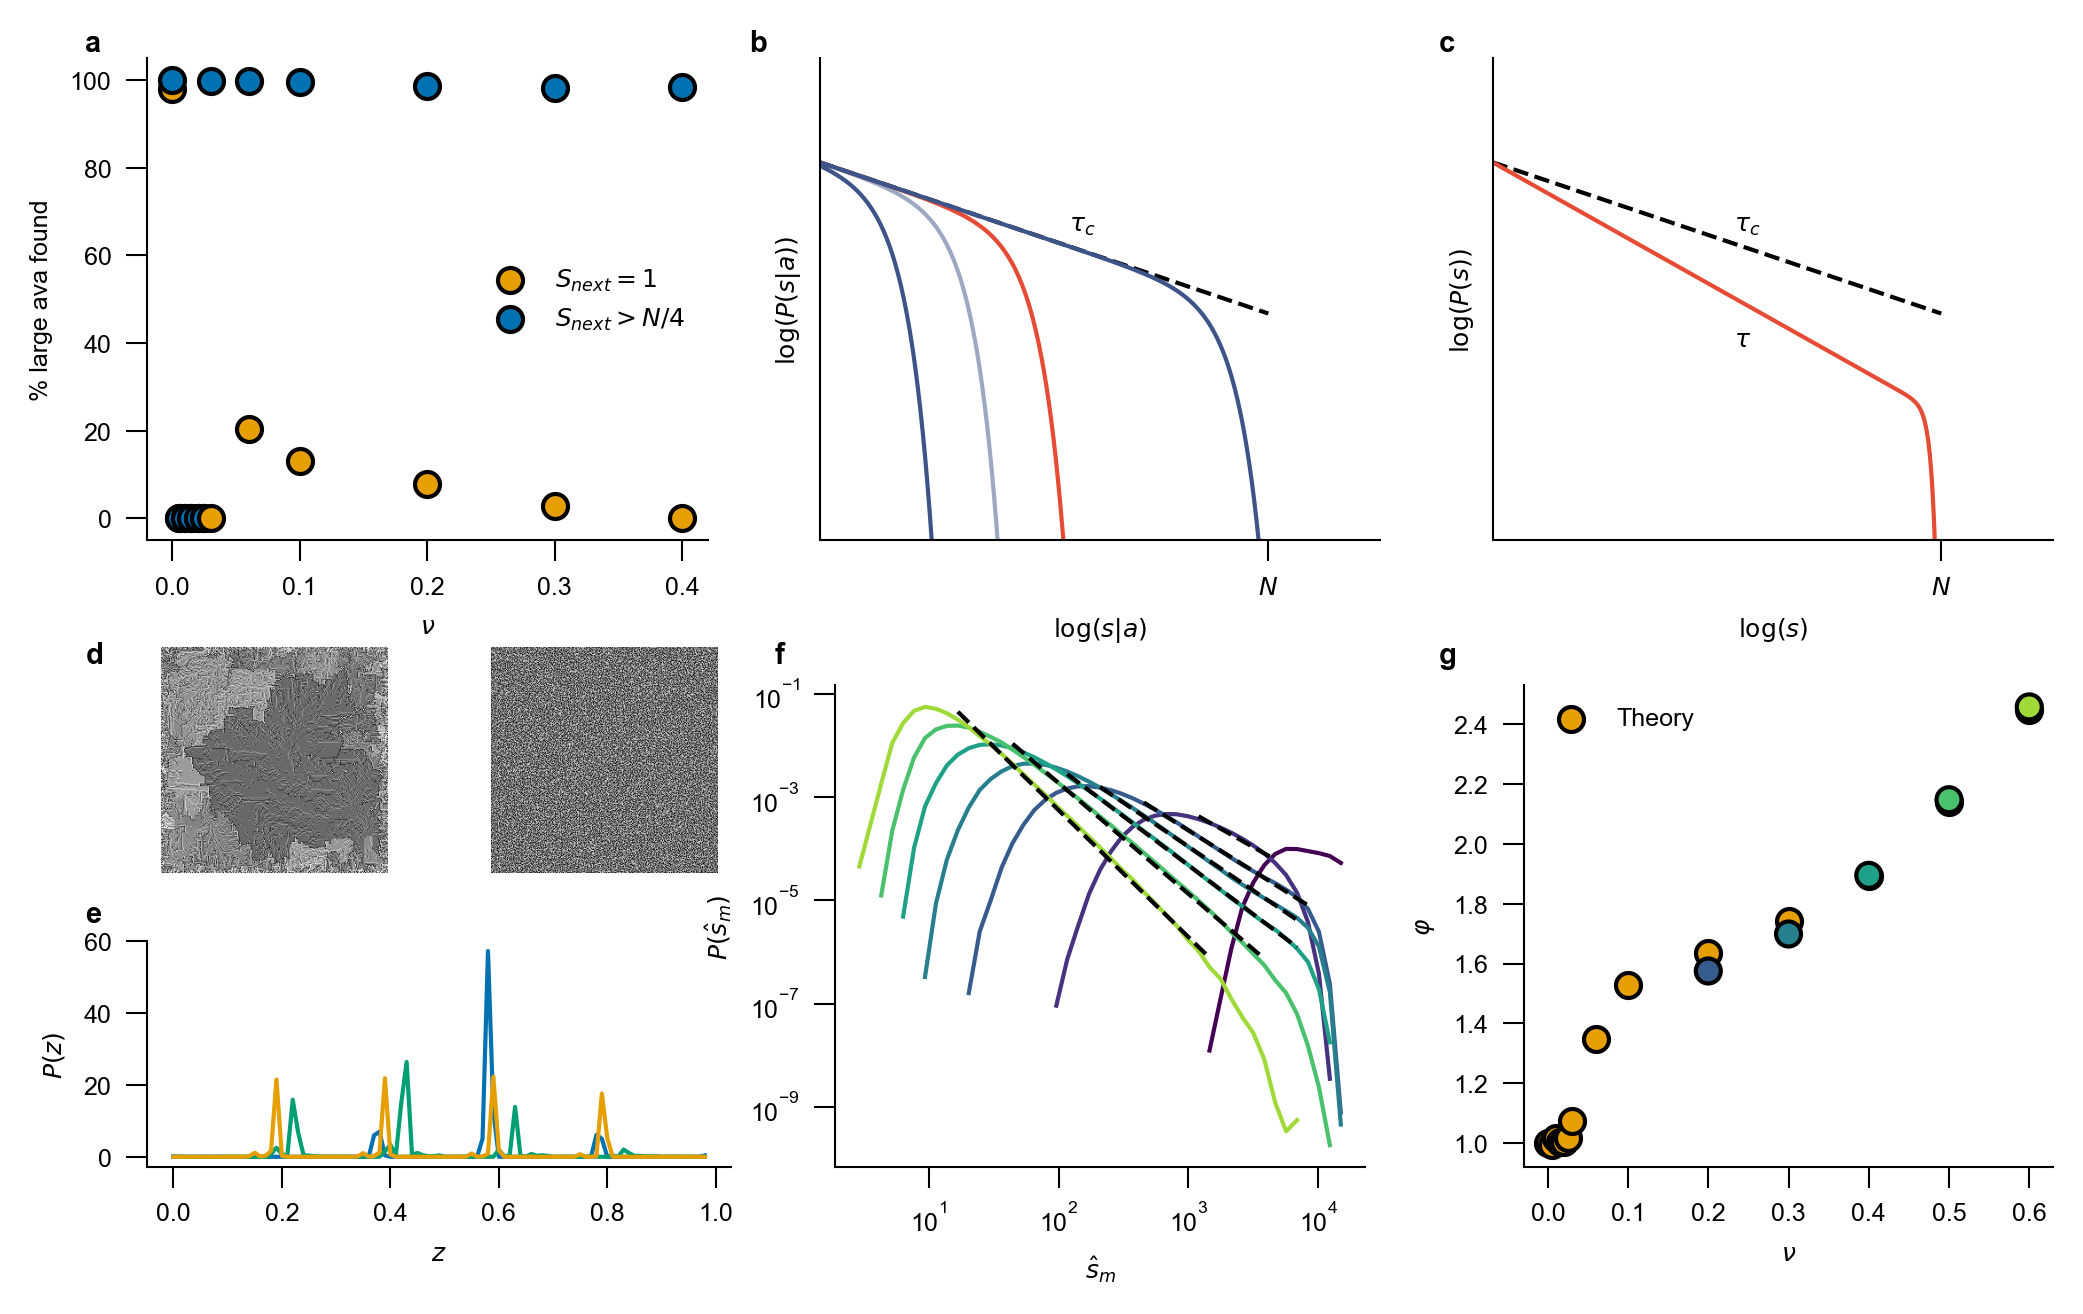

In [11]:
import warnings
from matplotlib.ticker import FixedLocator, NullLocator
from mpl_toolkits.axisartist.axislines import SubplotZero

warnings.resetwarnings()

Tfolderpath = ["/data1/DATA_Duplat/Brut/Memory_effects/Me60n{}".format(nb) for nb in range(1,13)]

Tnu = [0.0, 0.1, 0.2, 0.3 ,0.4, 0.5, 0.6]
Tn_try = [1]*len(Tnu)
Tstop = [1e4, 6e3, 1.2e4, 1e4, 1e4, 5e3, 2e3]
Tstart = [1000, 1e3, 400, 200, 100, 40, 15]
Ttau = [None]*len(Tnu)
NCURVES = len(Tnu)
Tcolor = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

max_nbtry = 6554

warnings.filterwarnings("error")
with plt.style.context(spstyle.get_style('nature-reviews')):
    print(spstyle.get_style('nature-reviews'))
    plt.rcParams['font.family'] = 'Arial' 
    fig = plt.figure(figsize=(8.2, 4.8))
    gs1 = gridspec.GridSpec(2, 3, width_ratios=[0.33,0.33,0.33], wspace = 0.2, hspace = 0.3)
    gs2 = gridspec.GridSpec(2, 3, width_ratios=[0.33, 0.33, 0.33], wspace = 0.3, hspace = 0.3)
    gs3 = gridspec.GridSpec(4, 6, wspace = 0.3, hspace = 0.3)
    
    ax1 = fig.add_subplot(gs1[0, 0])
    ax12 = fig.add_subplot(gs1[0, 1])
    ax13 = fig.add_subplot(gs1[0, 2])
    ax2 = fig.add_subplot(gs2[1, -1])
    ax22 = fig.add_subplot(gs2[1, 1])
    ax31 = fig.add_subplot(gs3[2, 0])
    ax32 = fig.add_subplot(gs3[2, 1])
    ax33 = fig.add_subplot(gs3[3, :2])
    
    ######NTRY######
    for i, folder in enumerate(Tfolderpath):
        nu = read_parameters(folder)[2]
        small_data = np.loadtxt("{}/random_small.txt".format(folder))
        try:
            large_data = np.loadtxt("{}/random_large.txt".format(folder))
        except UserWarning:
            large_data = np.ones((1,6))
            large_data[0,-1] = max_nbtry
        
        mask_small = small_data[:, -1] != max_nbtry
        mask_large = large_data[:, -1] != max_nbtry
        
        f_small = small_data[mask_small]
        f_large = large_data[mask_large]
        
        p_small = len(f_small)/len(small_data)
        p_large = len(f_large)/len(large_data)
        print(p_large)
        if i == 0:
            ax1.scatter(nu,  p_small*100, c = color_list[1], label = r"$S_{next} = 1$" )
            ax1.scatter(nu,  p_large*100, c = color_list[5], label = r"$S_{next} > N/4$")
        else:
            ax1.scatter(nu,  p_small*100, c = color_list[1])
            ax1.scatter(nu,  p_large*100, c = color_list[5])
    
    ######P(smax)######
    for j, n in enumerate(Tnu):
        ax22.plot(Tbin_s1[j], Thisto_s1[j], c = Tcolor[j], label = f"{Tnu[j]}")
        if j not in [0]:
            start = np.where(Tbin_s1[j] >= Tstart[j])[0][0]
            stop = np.where(Tbin_s1[j] <= Tstop[j])[0][-1]
            popt, pcov = curve_fit(powerlaw2, np.log(Tbin_s1[j][start:stop]), np.log(Thisto_s1[j][start:stop]), p0 = [0.5, 1.6], maxfev = 1000)
            """ tau = popt[1]
            Tperr[j] = np.sqrt(np.diag(pcov))[1] """
            Ttau[j] = popt[1]
            yfit = np.exp(powerlaw2(np.log(Tbin_s1[j][start:stop]), *popt))
            ax22.plot(Tbin_s1[j][start:stop], yfit, ls = '--', c ='k', lw =1)

    ######Pl cut-off######
    a = 1
    b = 1.2
    c = 32
    d = 2
    
    c2 = 8
    d2 = 2
    
    c3 = 2
    d3 = 2
    
    c4 = 2000
    d4 = 2
    
    x = np.arange(1,10000, 0.1, dtype= float)
    y = powercutoff_fit(x, a,b,c,d)
    y2 = powercutoff_fit(x, a,b,c2,d2)
    y3 = powercutoff_fit(x, a,b,c3,d3)
    y4 = powercutoff_fit(x, a,b,c4,d4)

    x_crit = np.arange(1,10000, 1, dtype= float)
    y_crit = powerlaw(x_crit, a, -b) 
    
    ax12.plot(x_crit, y_crit, c = 'k', ls ='--')
    ax12.plot(x, y, c = 'C0')
    ax12.plot(x, y2, c = 'C3', alpha = 0.5 )
    ax12.plot(x, y3, c = 'C3')
    ax12.plot(x, y4, c = 'C3')
    
    b5 = 2
    c5 = 7000
    d5 = 10
    y5 = powercutoff_fit(x, a,b5,c5,d5)
    ax33.set_xlabel(r"$z$")
    ax33.set_ylabel(r"$P(z)$")
    ax13.plot(x_crit, y_crit, c = 'k', ls ='--')
    ax13.plot(x, y5, c = 'C0')
    
    
    ######Snapshots and distrib######
    sys1 = np.loadtxt("/data1/DATA_Duplat/Brut/PDF/PD5n10/Snapshots/nav100000000000_outputB.txt").reshape(L1, L2).T
    sys2 = np.loadtxt("/data1/DATA_Duplat/Brut/Rdtopple/Rd8n7/Snapshots/nav100000000000_outputB.txt").reshape(L1, L2).T
    
    nbins = 100
    sys1_filtered = sys1[100:210,90:200]
    sys1_filtered2 = sys1[20:75,20:75]
    
    histo1, bins1 = np.histogram(sys1_filtered, bins = np.arange(0,1,1/nbins), density=True)
    histo2, bins2 = np.histogram(sys1_filtered2, bins = np.arange(0,1,1/nbins), density=True)
    histo3, bins3 = np.histogram(sys2, bins = np.arange(0,1,1/nbins), density=True)
    
    
    ax31.imshow(sys1, cmap = "binary", vmin = 0, vmax = 1)
    ax32.imshow(sys2, cmap = "binary", vmin = 0, vmax = 1)
    ax33.plot(bins1[:-1], histo1, c = color_list[5])
    ax33.plot(bins2[:-1], histo2, c = color_list[3])
    ax33.plot(bins3[:-1], histo3, c = color_list[1])
    
    
    
    ax12.set_yscale('log')
    ax12.set_xscale('log')
    ax12.set_ylim(1e-12,2e3)
    ax12.set_xlim(1, 1e5)
    ax12.set_xlabel(r"$\log(s|a)$")
    ax12.set_ylabel(r"$\log(P(s|a))$")
    xticks = [1e4]
    ax12.xaxis.set_major_locator(FixedLocator(xticks))  # Supprime tous les autres ticks majeurs
    ax12.xaxis.set_minor_locator(NullLocator())  # Supprime les ticks mineurs
    ax12.set_xticklabels([r'$N$'])
    ax12.set_yticklabels([])
    ax12.set_yticks([])
    
    ax13.set_yscale('log')
    ax13.set_xscale('log')
    ax13.set_ylim(1e-12,2e3)
    ax13.set_xlim(1, 1e5)
    ax13.set_xlabel(r"$\log(s)$")
    ax13.set_ylabel(r"$\log(P(s))$")
    yticks = [1e4]
    ax13.xaxis.set_major_locator(FixedLocator(yticks))  # Supprime tous les autres ticks majeurs
    ax13.xaxis.set_minor_locator(NullLocator())  # Supprime les ticks mineurs
    ax13.set_xticklabels([r'$N$'])
    ax13.set_yticklabels([])
    ax13.set_yticks([])
    
    
    ax1.set_xlabel(r'$\nu$')
    ax1.set_ylabel('% large ava found')
    ax1.legend()
    
    ax2.scatter(Tnu_th, 2-(-Tgamma_th), c = color_list[1], label = r'Theory')
    ax2.scatter(Tnu[2:], -np.array(Ttau)[2:], c = Tcolor[2:])
    ax2.set_ylabel(r"$\varphi$")
    ax2.set_xlabel(r"$\nu$")
    ax2.legend()
    
    ax22.set_xlabel(r"$\hat s_m$")
    ax22.set_ylabel(r"$P(\hat s_m)$")
    ax22.set_xscale('log')
    ax22.set_yscale('log')
    
    ax31.set_axis_off()
    ax32.set_axis_off()
    ax33.set_xlabel(r"$z$")
    ax33.set_ylabel(r"$P(z)$")
    
    fig.text(0.1, 0.885, "a", fontsize=7, fontweight="bold") 
    fig.text(0.37, 0.885, "b", fontsize=7, fontweight="bold") 
    fig.text(0.65, 0.885, "c", fontsize=7, fontweight="bold") 
    fig.text(0.1, 0.46, "d", fontsize=7, fontweight="bold") 
    fig.text(0.1, 0.28, "e", fontsize=7, fontweight="bold") 
    fig.text(0.38, 0.46, "f", fontsize=7, fontweight="bold") 
    fig.text(0.65, 0.46, "g", fontsize=7, fontweight="bold") 
    fig.text(0.5, 0.76, r"$\tau _c$")
    fig.text(0.77, 0.76, r"$\tau _c$")
    fig.text(0.77, 0.68, r"$\tau$")
    
    fig.patch.set_alpha(0.0)
    ax1.patch.set_alpha(0.0)
    ax12.patch.set_alpha(0.0)
    ax13.patch.set_alpha(0.0)
    ax2.patch.set_alpha(0.0)
    ax22.patch.set_alpha(0.0)
    ax33.patch.set_alpha(0.0)
    # fig.savefig('Fig4_nature.pdf', bbox_inches = 'tight', dpi = 300)
    plt.show() 
    
warnings.resetwarnings()

##  PRX

/tmp/ipykernel_1457689/3914402613.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  Tcolor = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


/home/kduplat/Documents/py38/lib/python3.8/site-packages/sciplotlib/stylesheets/nature-reviews.mplstyle
0.9996666666666667
0.0
0.0
0.0
0.0
0.0
0.9988888888888889
0.998
0.996
0.987
0.9813333333333333
0.9836842105263158


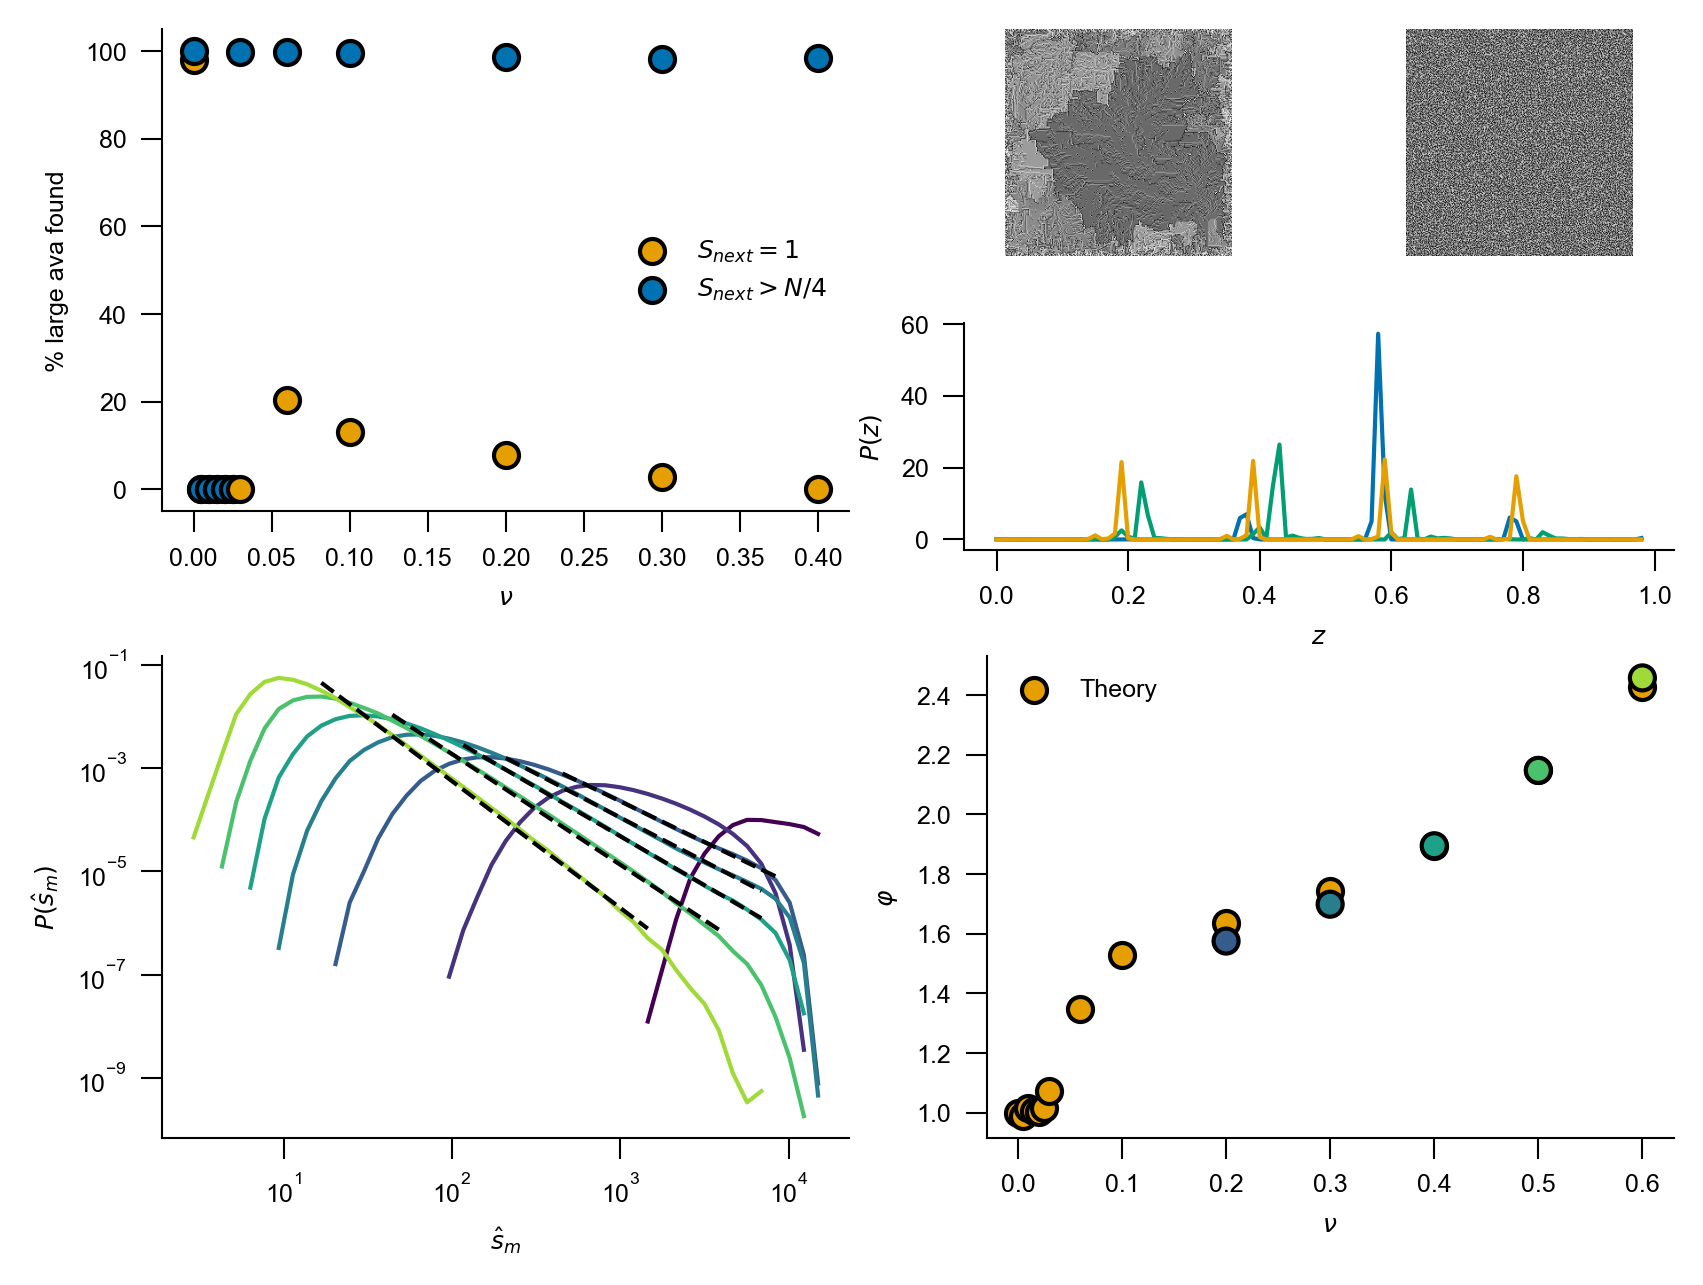

In [16]:
import warnings
from matplotlib.ticker import FixedLocator, NullLocator
from mpl_toolkits.axisartist.axislines import SubplotZero

warnings.resetwarnings()

Tfolderpath = ["/data1/DATA_Duplat/Brut/Memory_effects/Me60n{}".format(nb) for nb in range(1,13)]

Tnu = [0.0, 0.1, 0.2, 0.3 ,0.4, 0.5, 0.6]
Tn_try = [1]*len(Tnu)
Tstop = [1e4, 6e3, 1.2e4, 1e4, 1e4, 5e3, 2e3]
Tstart = [1000, 1e3, 400, 200, 100, 40, 15]
Ttau = [None]*len(Tnu)
NCURVES = len(Tnu)
Tcolor = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

max_nbtry = 6554

warnings.filterwarnings("error")
with plt.style.context(spstyle.get_style('nature-reviews')):
    print(spstyle.get_style('nature-reviews'))
    plt.rcParams['font.family'] = 'Arial' 
    fig = plt.figure(figsize=(6.5, 4.8))
    gs1 = gridspec.GridSpec(2, 2, width_ratios=[0.5,0.5], wspace = 0.2, hspace = 0.3)
    gs3 = gridspec.GridSpec(4, 4, wspace = 0.3, hspace = 0.3)
    
    
    ax1 = fig.add_subplot(gs1[0, 0])
    ax2 = fig.add_subplot(gs1[1, -1])
    ax22 = fig.add_subplot(gs1[1, 0])
    ax31 = fig.add_subplot(gs3[0, 2])
    ax32 = fig.add_subplot(gs3[0, 3])
    ax33 = fig.add_subplot(gs3[1, 2:])
    
    ######NTRY######
    for i, folder in enumerate(Tfolderpath):
        nu = read_parameters(folder)[2]
        small_data = np.loadtxt("{}/random_small.txt".format(folder))
        try:
            large_data = np.loadtxt("{}/random_large.txt".format(folder))
        except UserWarning:
            large_data = np.ones((1,6))
            large_data[0,-1] = max_nbtry
        
        mask_small = small_data[:, -1] != max_nbtry
        mask_large = large_data[:, -1] != max_nbtry
        
        f_small = small_data[mask_small]
        f_large = large_data[mask_large]
        
        p_small = len(f_small)/len(small_data)
        p_large = len(f_large)/len(large_data)
        print(p_large)
        if i == 0:
            ax1.scatter(nu,  p_small*100, c = color_list[2], label = r"$S_{next} = 1$" )
            ax1.scatter(nu,  p_large*100, c = color_list[0], label = r"$S_{next} > N/4$")
        else:
            ax1.scatter(nu,  p_small*100, c = color_list[2])
            ax1.scatter(nu,  p_large*100, c = color_list[0])
    
    ######P(smax)######
    for j, n in enumerate(Tnu):
        ax22.plot(Tbin_s1[j], Thisto_s1[j], c = Tcolor[j], label = f"{Tnu[j]}")
        if j not in [0, 1]:
            start = np.where(Tbin_s1[j] >= Tstart[j])[0][0]
            stop = np.where(Tbin_s1[j] <= Tstop[j])[0][-1]
            popt, pcov = curve_fit(powerlaw2, np.log(Tbin_s1[j][start:stop]), np.log(Thisto_s1[j][start:stop]), p0 = [0.5, 1.6], maxfev = 1000)
            """ tau = popt[1]
            Tperr[j] = np.sqrt(np.diag(pcov))[1] """
            Ttau[j] = popt[1]
            yfit = np.exp(powerlaw2(np.log(Tbin_s1[j][start:stop]), *popt))
            ax22.plot(Tbin_s1[j][start:stop], yfit, ls = '--', c ='k', lw =1)

    ######Pl cut-off######
    a = 1
    b = 1.2
    c = 32
    d = 2
    
    c2 = 8
    d2 = 2
    
    c3 = 2
    d3 = 2
    
    c4 = 2000
    d4 = 2
    
    x = np.arange(1,10000, 0.1, dtype= float)
    y = powercutoff_fit(x, a,b,c,d)
    y2 = powercutoff_fit(x, a,b,c2,d2)
    y3 = powercutoff_fit(x, a,b,c3,d3)
    y4 = powercutoff_fit(x, a,b,c4,d4)

    x_crit = np.arange(1,10000, 1, dtype= float)
    y_crit = powerlaw(x_crit, a, -b) 
    
    # ax12.plot(x_crit, y_crit, c = 'k', ls ='--')
    # ax12.plot(x, y, c = 'C0')
    # ax12.plot(x, y2, c = 'C3', alpha = 0.5 )
    # ax12.plot(x, y3, c = 'C3')
    # ax12.plot(x, y4, c = 'C3')
    
    b5 = 2
    c5 = 7000
    d5 = 10
    y5 = powercutoff_fit(x, a,b5,c5,d5)
    ax33.set_xlabel(r"$z$")
    ax33.set_ylabel(r"$P(z)$")
    # ax13.plot(x_crit, y_crit, c = 'k', ls ='--')
    # ax13.plot(x, y5, c = 'C0')
    
    
    ######Snapshots and distrib######
    sys1 = np.loadtxt("/data1/DATA_Duplat/Brut/PDF/PD5n10/Snapshots/nav100000000000_outputB.txt").reshape(L1, L2).T
    sys2 = np.loadtxt("/data1/DATA_Duplat/Brut/Rdtopple/Rd8n7/Snapshots/nav100000000000_outputB.txt").reshape(L1, L2).T
    
    nbins = 100
    sys1_filtered = sys1[100:210,90:200]
    sys1_filtered2 = sys1[20:75,20:75]
    
    histo1, bins1 = np.histogram(sys1_filtered, bins = np.arange(0,1,1/nbins), density=True)
    histo2, bins2 = np.histogram(sys1_filtered2, bins = np.arange(0,1,1/nbins), density=True)
    histo3, bins3 = np.histogram(sys2, bins = np.arange(0,1,1/nbins), density=True)
    
    
    ax31.imshow(sys1, cmap = "binary", vmin = 0, vmax = 1)
    ax32.imshow(sys2, cmap = "binary", vmin = 0, vmax = 1)
    ax33.plot(bins1[:-1], histo1, c = color_list[0])
    ax33.plot(bins2[:-1], histo2, c = color_list[1])
    ax33.plot(bins3[:-1], histo3, c = color_list[2])
    
    
    
    # ax12.set_yscale('log')
    # ax12.set_xscale('log')
    # ax12.set_ylim(1e-12,2e3)
    # ax12.set_xlim(1, 1e5)
    # ax12.set_xlabel(r"$\log(s|a)$")
    # ax12.set_ylabel(r"$\log(P(s|a))$")
    # xticks = [1e4]
    # ax12.xaxis.set_major_locator(FixedLocator(xticks))  # Supprime tous les autres ticks majeurs
    # ax12.xaxis.set_minor_locator(NullLocator())  # Supprime les ticks mineurs
    # ax12.set_xticklabels([r'$N$'])
    # ax12.set_yticklabels([])
    # ax12.set_yticks([])
    
    # ax13.set_yscale('log')
    # ax13.set_xscale('log')
    # ax13.set_ylim(1e-12,2e3)
    # ax13.set_xlim(1, 1e5)
    # ax13.set_xlabel(r"$\log(s)$")
    # ax13.set_ylabel(r"$\log(P(s))$")
    # yticks = [1e4]
    # ax13.xaxis.set_major_locator(FixedLocator(yticks))  # Supprime tous les autres ticks majeurs
    # ax13.xaxis.set_minor_locator(NullLocator())  # Supprime les ticks mineurs
    # ax13.set_xticklabels([r'$N$'])
    # ax13.set_yticklabels([])
    # ax13.set_yticks([])
    
    
    ax1.set_xlabel(r'$\nu$')
    ax1.set_ylabel('% large ava found')
    ax1.legend()
    
    ax2.scatter(Tnu_th, 2-(-Tgamma_th), c = color_list[2], label = r'Theory')
    ax2.scatter(Tnu[2:], -np.array(Ttau)[2:], c = Tcolor[2:])
    ax2.set_ylabel(r"$\varphi$")
    ax2.set_xlabel(r"$\nu$")
    ax2.legend()
    
    ax22.set_xlabel(r"$\hat s_m$")
    ax22.set_ylabel(r"$P(\hat s_m)$")
    ax22.set_xscale('log')
    ax22.set_yscale('log')
    
    ax31.set_axis_off()
    ax32.set_axis_off()
    ax33.set_xlabel(r"$z$")
    ax33.set_ylabel(r"$P(z)$")
    
    # fig.text(0.1, 0.885, "a", fontsize=7, fontweight="bold") 
    # fig.text(0.37, 0.885, "b", fontsize=7, fontweight="bold") 
    # fig.text(0.65, 0.885, "c", fontsize=7, fontweight="bold") 
    # fig.text(0.1, 0.46, "d", fontsize=7, fontweight="bold") 
    # fig.text(0.1, 0.28, "e", fontsize=7, fontweight="bold") 
    # fig.text(0.38, 0.46, "f", fontsize=7, fontweight="bold") 
    # fig.text(0.65, 0.46, "g", fontsize=7, fontweight="bold") 
    # fig.text(0.5, 0.76, r"$\tau _c$")
    # fig.text(0.77, 0.76, r"$\tau _c$")
    # fig.text(0.77, 0.68, r"$\tau$")
    
    fig.patch.set_alpha(0.0)
    ax1.patch.set_alpha(0.0)
    # ax12.patch.set_alpha(0.0)
    # ax13.patch.set_alpha(0.0)
    ax2.patch.set_alpha(0.0)
    ax22.patch.set_alpha(0.0)
    ax33.patch.set_alpha(0.0)
    # fig.savefig('Fig4_prev_PRX.pdf', bbox_inches = 'tight', dpi = 300)
    plt.show() 
    
warnings.resetwarnings()

#   Extended data fig (NON UTILISE)

In [ ]:
def process_ratio_top_s(folder, maxline = 1e6, csize = 1e6):
    path = '{}/Avalanche_outputB.gz'.format(folder)
    col = [1,4]
    ratio = 0
    nbline = 0
    
    for chunk in chunked_file_reader(path, chunksize=1e6, usecols=col):
        ratio += np.sum(chunk.iloc[:, 1]/chunk.iloc[:, 0])
        nbline += len(chunk)
        if nbline >= maxline:
            break
        
    return ratio/nbline

In [ ]:
Thisto_s, Tbins_s, Tnonzero_s, Tmean_s,Tnbins_s = np.array(Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder))
                                                                    for  folder in folderpath)).T



/home/oramos/.local/lib/python3.8/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
<ipython-input-69-eec07705350f>:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  Thisto_s, Tbins_s, Tnonzero_s, Tmean_s,Tnbins_s = np.array(Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder))


In [ ]:
maxline = 1e7
csize = 1e6

folderpath_ratio = folderpath

for i in range(6):
    folderpath_ratio[i] = '/data1/DATA_Duplat/Brut/PDF/PD7n{}'.format(i+1)

Tratio = np.array(Parallel(n_jobs=-1)(delayed(process_ratio_top_s)(folder, maxline, csize)
                                                                    for folder in folderpath_ratio)).T

In [ ]:
#Test to see if S = ntop
maxline = 1e6
csize = 1e6
path = '/data1/DATA_Duplat/Brut/PDF/PD5n11/Avalanche_outputB.gz'.format(folder)
col = [1,2,4]
ratio = 0
nbline = 0

for chunk in chunked_file_reader(path, chunksize=1e6, usecols=col):
    id = np.argwhere(chunk.iloc[:, 2].to_numpy() != chunk.iloc[:, 0].to_numpy())
    if len(id) != 0:
        print(chunk.iloc[id[:, 0]])
        break
    
    nbline += len(chunk)
    if nbline >= maxline:
            break
    

0.9670766518841873
0.9986527786720975
0.9849383793502774
0.9915069039180054
0.9968332876518041
0.9920444880221438
0.9900365979716083
0.9250598850507007
0.9120158065443928
0.9690635115357342
0.9029052803900638
0.9104379772584462
0.8356861569714998
0.9234995347766835
a = -14.27, b = 1.23
a2 = -0.32, b2 = 0.33
a3 = 0, b3 = 1.0


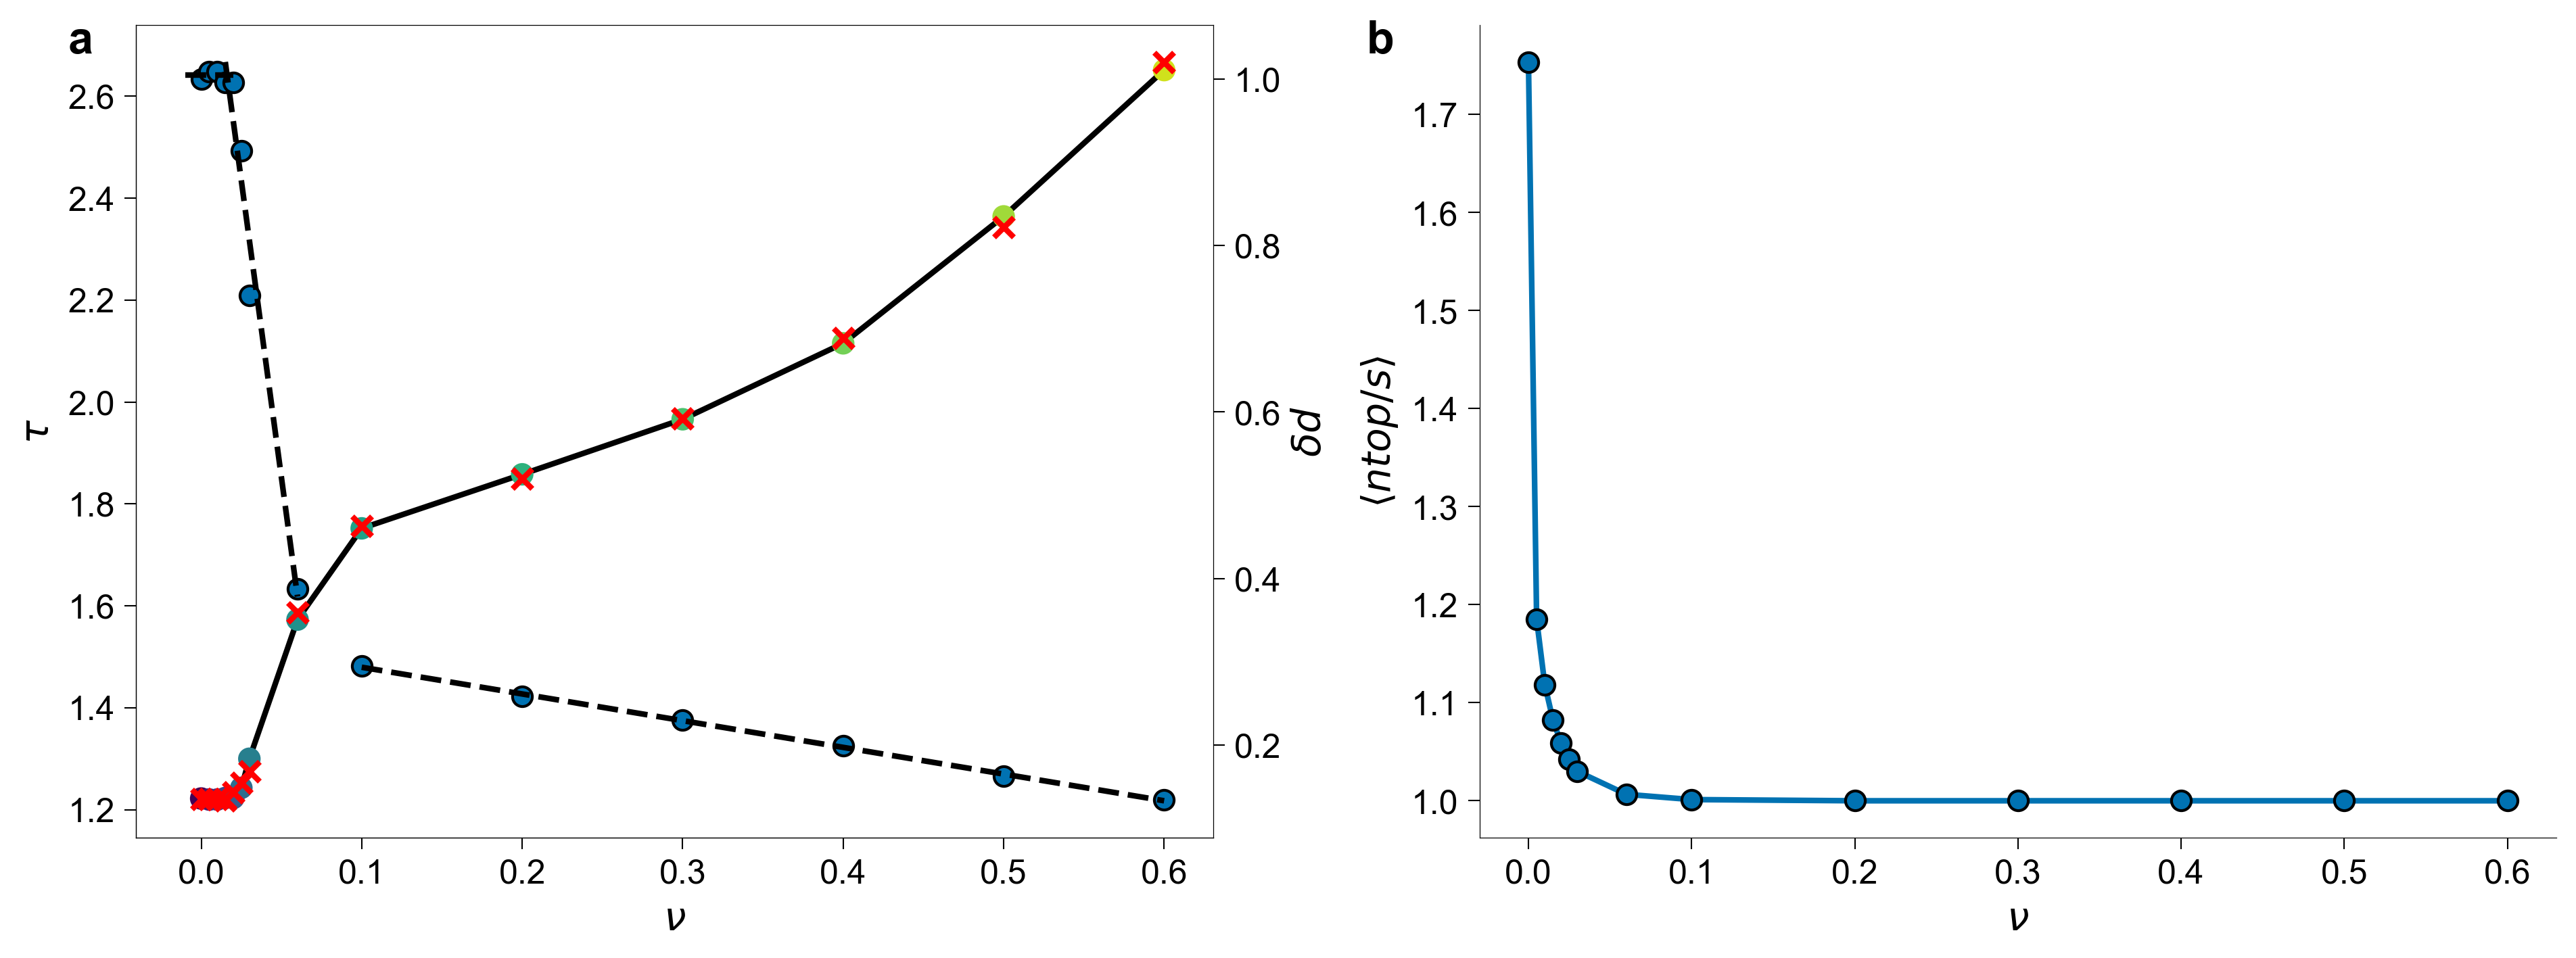

In [ ]:

Tstop_x = [4.e3, 1e-8, 7e-10,  1.1e-8, 1e-6,5e-5,5e-5,1e-7, 1e-8, 1e-9, 1e-10, 1e-9, 5e-11, 1e-11]
Tstart_x = [2,4,4,4,1,0,1,3,5,4,4,8,8,8]
Txfit_s, Tyfit_s, Ttau_s, Tperr_s = PDF_fitting(Thisto_s, Tbins_s, Tstart_x, Tstop_x, Tvar)

NCURVES = len(Thisto_s)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12.8,4.8))

    ax1.plot(Tvar, -Ttau_s, linestyle = '-', c = 'k', zorder=1)
    ax1.scatter(Tvar, -Ttau_s, color = colors[:], zorder=2, marker = 'o', label = r'$\tau$')

    #Calc la dimension fractal
    Ttau_bis = np.array((-Ttau_s[0]-1)/(-Ttau_s -1), dtype = float)
    mask1 = slice(3,8)
    mask2 = slice(8, 15)
    mask3 = slice(0,4)

    a, b = np.polyfit(Tvar[mask1], Ttau_bis[mask1],1)
    y1 = a * np.array(Tvar[mask1]) + b
    a2, b2 = np.polyfit(Tvar[mask2], Ttau_bis[mask2],1)
    y2 = a2 * np.array(Tvar[mask2]) + b2
    
    a3 = 0
    b3 = (Ttau_bis[0] + Ttau_bis[2])/2
    y3 = a3 * np.array([0,0.05]) + b3

    ax12 = ax1.twinx()
    ax12.scatter(Tvar, Ttau_bis, c = '#0072b2', zorder=2, marker = 'o')
    ax12.plot(Tvar[mask1], y1, ls = '--', c = 'k', label = r'$\delta d$')
    ax12.plot(Tvar[mask2], y2, ls = '--', c = 'k')
    ax12.plot([-0.01,0.02], y3, ls = '--', c = 'k')
    print("a = {}, b = {}".format(np.round(a, 2),np.round(b, 2)))
    print("a2 = {}, b2 = {}".format(np.round(a2, 2),np.round(b2, 2)))
    print("a3 = {}, b3 = {}".format(np.round(a3, 2),np.round(b3, 2)))


    tau_from_fractl1 = ((-Ttau_s[0] - 1)/ ((a*np.array(Tvar[mask1]) + b))) + 1
    tau_from_fractl2 = ((-Ttau_s[0] - 1)/ ((a2*np.array(Tvar[mask2]) + b2))) + 1
    tau_from_fractl3 = ((-Ttau_s[0] - 1)/ ((a3*np.array(Tvar[mask3]) + b3))) + 1

    ax1.scatter(Tvar[mask1], tau_from_fractl1, marker = 'x', c = 'red', zorder = 10, label = r'$\tau_{fit}$')
    ax1.scatter(Tvar[mask2], tau_from_fractl2, marker = 'x', c = 'red', zorder = 10)
    ax1.scatter(Tvar[mask3], tau_from_fractl3, marker = 'x', c = 'red', zorder = 10)

    para_fig_Nature(ax1, r'$\nu$', r'$\tau$',)
    para_fig_Nature(ax12, r'$\nu$', r'$\delta d$')
    ax1.spines['top'].set_visible(True)
    ax1.spines['right'].set_visible(True)
    
    ax2.plot(Tvar, Tratio, marker = 'o', c = color_list[5])
    para_fig_Nature(ax2, r'$\nu$', r'$\langle ntop/s \rangle$')
    
    fig.text(0.03, 0.94, "a", fontsize=16, fontweight="bold") 
    fig.text(0.53, 0.94, "b", fontsize=16, fontweight="bold") 
    
    fig.patch.set_alpha(0.0)
    plt.tight_layout()
    plt.savefig('Ext_data_fig6.pdf', bbox_inches = 'tight', dpi = 300)
    plt.show()

#   Extended data fig (NON UTILISE)

In [ ]:
def magnitude(energy):
    return (2/3) * np.log10(energy) - 6.07

def energy(magnitude):
    return 10 ** (1.5 * (magnitude + 6.07))

# Paramètres d'énergie
Emax = energy(8.9)  # MagMax=9.1
Emin = energy(0)          # MagMin=6.07
Etot = 6.5297e+22 / 40             # Total yearly energy
print('Etot: ', Etot)

# Liste des valeurs de tau
tau_values = np.array([(n + 7) / 10 for n in range(18)])

nbins = 9

ntot = len(tau_values)
Sum001 = np.zeros(ntot)

line01x = np.zeros((ntot, nbins))
line01y = np.zeros((ntot, nbins))

norm_line01y = np.zeros((ntot, nbins))

mean_energy = np.zeros(ntot)
mean_energy_y = np.zeros(ntot)
norm_mean_energy_y = np.zeros(ntot)

magnitude_y = np.zeros((ntot, nbins))
mag_norm_y = np.zeros((ntot, nbins))
mean_magnitude_x = np.zeros(ntot)
mean_magnitude_y = np.zeros(ntot)

P_energy8 = np.zeros(ntot)
P_energy02 = np.zeros(ntot)

Rate8 = np.zeros(ntot)
Rate02 = np.zeros(ntot)

Ntot = np.zeros(ntot)

energy_edges = energy(np.linspace(0, 8.9, nbins+1))
energy_center = np.array(10 ** (1.5 * (np.linspace(0,7.9,nbins) + 0.5 + 6.07)))
magnitude_x = np.linspace(0,7.9,nbins) + 0.5

# print(energy_edges)
# print(energy_center)
# print(magnitude_x)

tau_EQ = 1.67
k_orig_ref8 = Etot * (2 - tau_EQ) / (Emax ** (2 - tau_EQ) - Emin ** (2 - tau_EQ))
N_ref8 = k_orig_ref8 * ( (energy(9)**(1-tau_EQ)) - (energy(8)**(1-tau_EQ)) )/(1 - tau_EQ)

T_ref8 = 10 #Time between two T8
Rate_ref8 = 1/T_ref8


for n in range(ntot):
    tau = tau_values[n]
    if tau == 2:
        tau = 2.000001  # éviter division par zéro
        tau_values[n] = tau

    """ K1 = Emax ** (2 - tau)
    K2 = Emin ** (2 - tau)
    Sum01 = K1 - K2
    k_orig = Etot * (2 - tau) / Sum01
    line01y[n] = k_orig * energy_center ** (-tau) 
    N = line01y[n] """

    #Without normalisation
    line01x[n] = energy_center
    E = energy_center
    dE = energy_edges[1:] - energy_edges[:-1]
    
    k_orig = Etot / np.sum(energy_center**(1-tau) * dE) #Remplace le developpement de l'intégrale pour calculer le coefficient
    line01y[n] = k_orig * energy_center ** (-tau) 
    N = line01y[n]
    
    #With normalisation
    norm = np.sum(N*dE) 
    norm_line01y[n] = N/norm
    """ check_norm = np.sum(norm_line01y[n] * dE)
    print("Test normalisation: ", check_norm) """
    """ print("Etot: ", np.sum(E * N * dE)) """
    
    mean_energy[n] = np.sum(energy_center * norm_line01y[n] * dE)
    mean_energy_y[n] = k_orig * mean_energy[n] ** (-tau)
    norm_mean_energy_y[n] = k_orig/norm * mean_energy[n] ** (-tau)
    
    
    #Magnitude, largeur des bins = 1

    magnitude_y[n] = N * 1.5 * np.log(10) * E
    mag_norm_y[n] = magnitude_y[n]/np.sum(magnitude_y[n]) 
    
    mean_magnitude_x[n] = np.sum(magnitude_x * mag_norm_y[n])
    
    Emean_mag = energy(mean_magnitude_x[n])
    yE_mag = k_orig * Emean_mag ** (-tau)
    mean_magnitude_y[n] = yE_mag * 1.5 * np.log(10) * Emean_mag
    
    """ check_norm_mag = np.sum(mag_norm_y[n])
    print("Tes norm mag: ", check_norm_mag) """
    #Pourcentage d'énergie comptenu dans une gamme de magnitude
    
    P_energy8[n] = np.sum(E[-1] * dE[-1] * N[-1])/np.sum(E*N*dE)
    P_energy02[n] = np.sum(E[0:2] * dE[0:2] * N[0:2])/np.sum(E*N*dE)
    
    Ntot[n] = np.sum(N * dE)
    # print(Ntot)
    # Ntot = k_orig * ( (energy(10)**(1.00000001-tau)) - (energy(0)**(1.00000001-tau)) )/(1.00000001 - tau)
    # print(Ntot)
    N8 = N[-1] * dE[-1]
    N02 = np.sum(N[0:2] * dE[0:2])
    # N8 = k_orig * ( (energy(9)**(1.00000001-tau)) - (energy(8)**(1.00000001-tau)) )/(1.00000001 - tau)
    Rate8[n] = Rate_ref8 * (N8/N_ref8)
    
    Rate02[n] = Rate8[n] * N02/N8
    # print(tau, 40 / N8)


Etot:  1.6324249999999998e+21


[1.55987292e-01 1.55229499e-01 1.54163699e-01 1.52664703e-01
 1.50556437e-01 1.47591261e-01 1.43420882e-01 1.37555445e-01
 1.29306011e-01 1.17704038e-01 1.01394917e-01 7.85965831e-02
 4.83031773e-02 1.78772575e-02 3.21526775e-03 3.45057424e-04
 2.91976925e-05 2.21833830e-06]


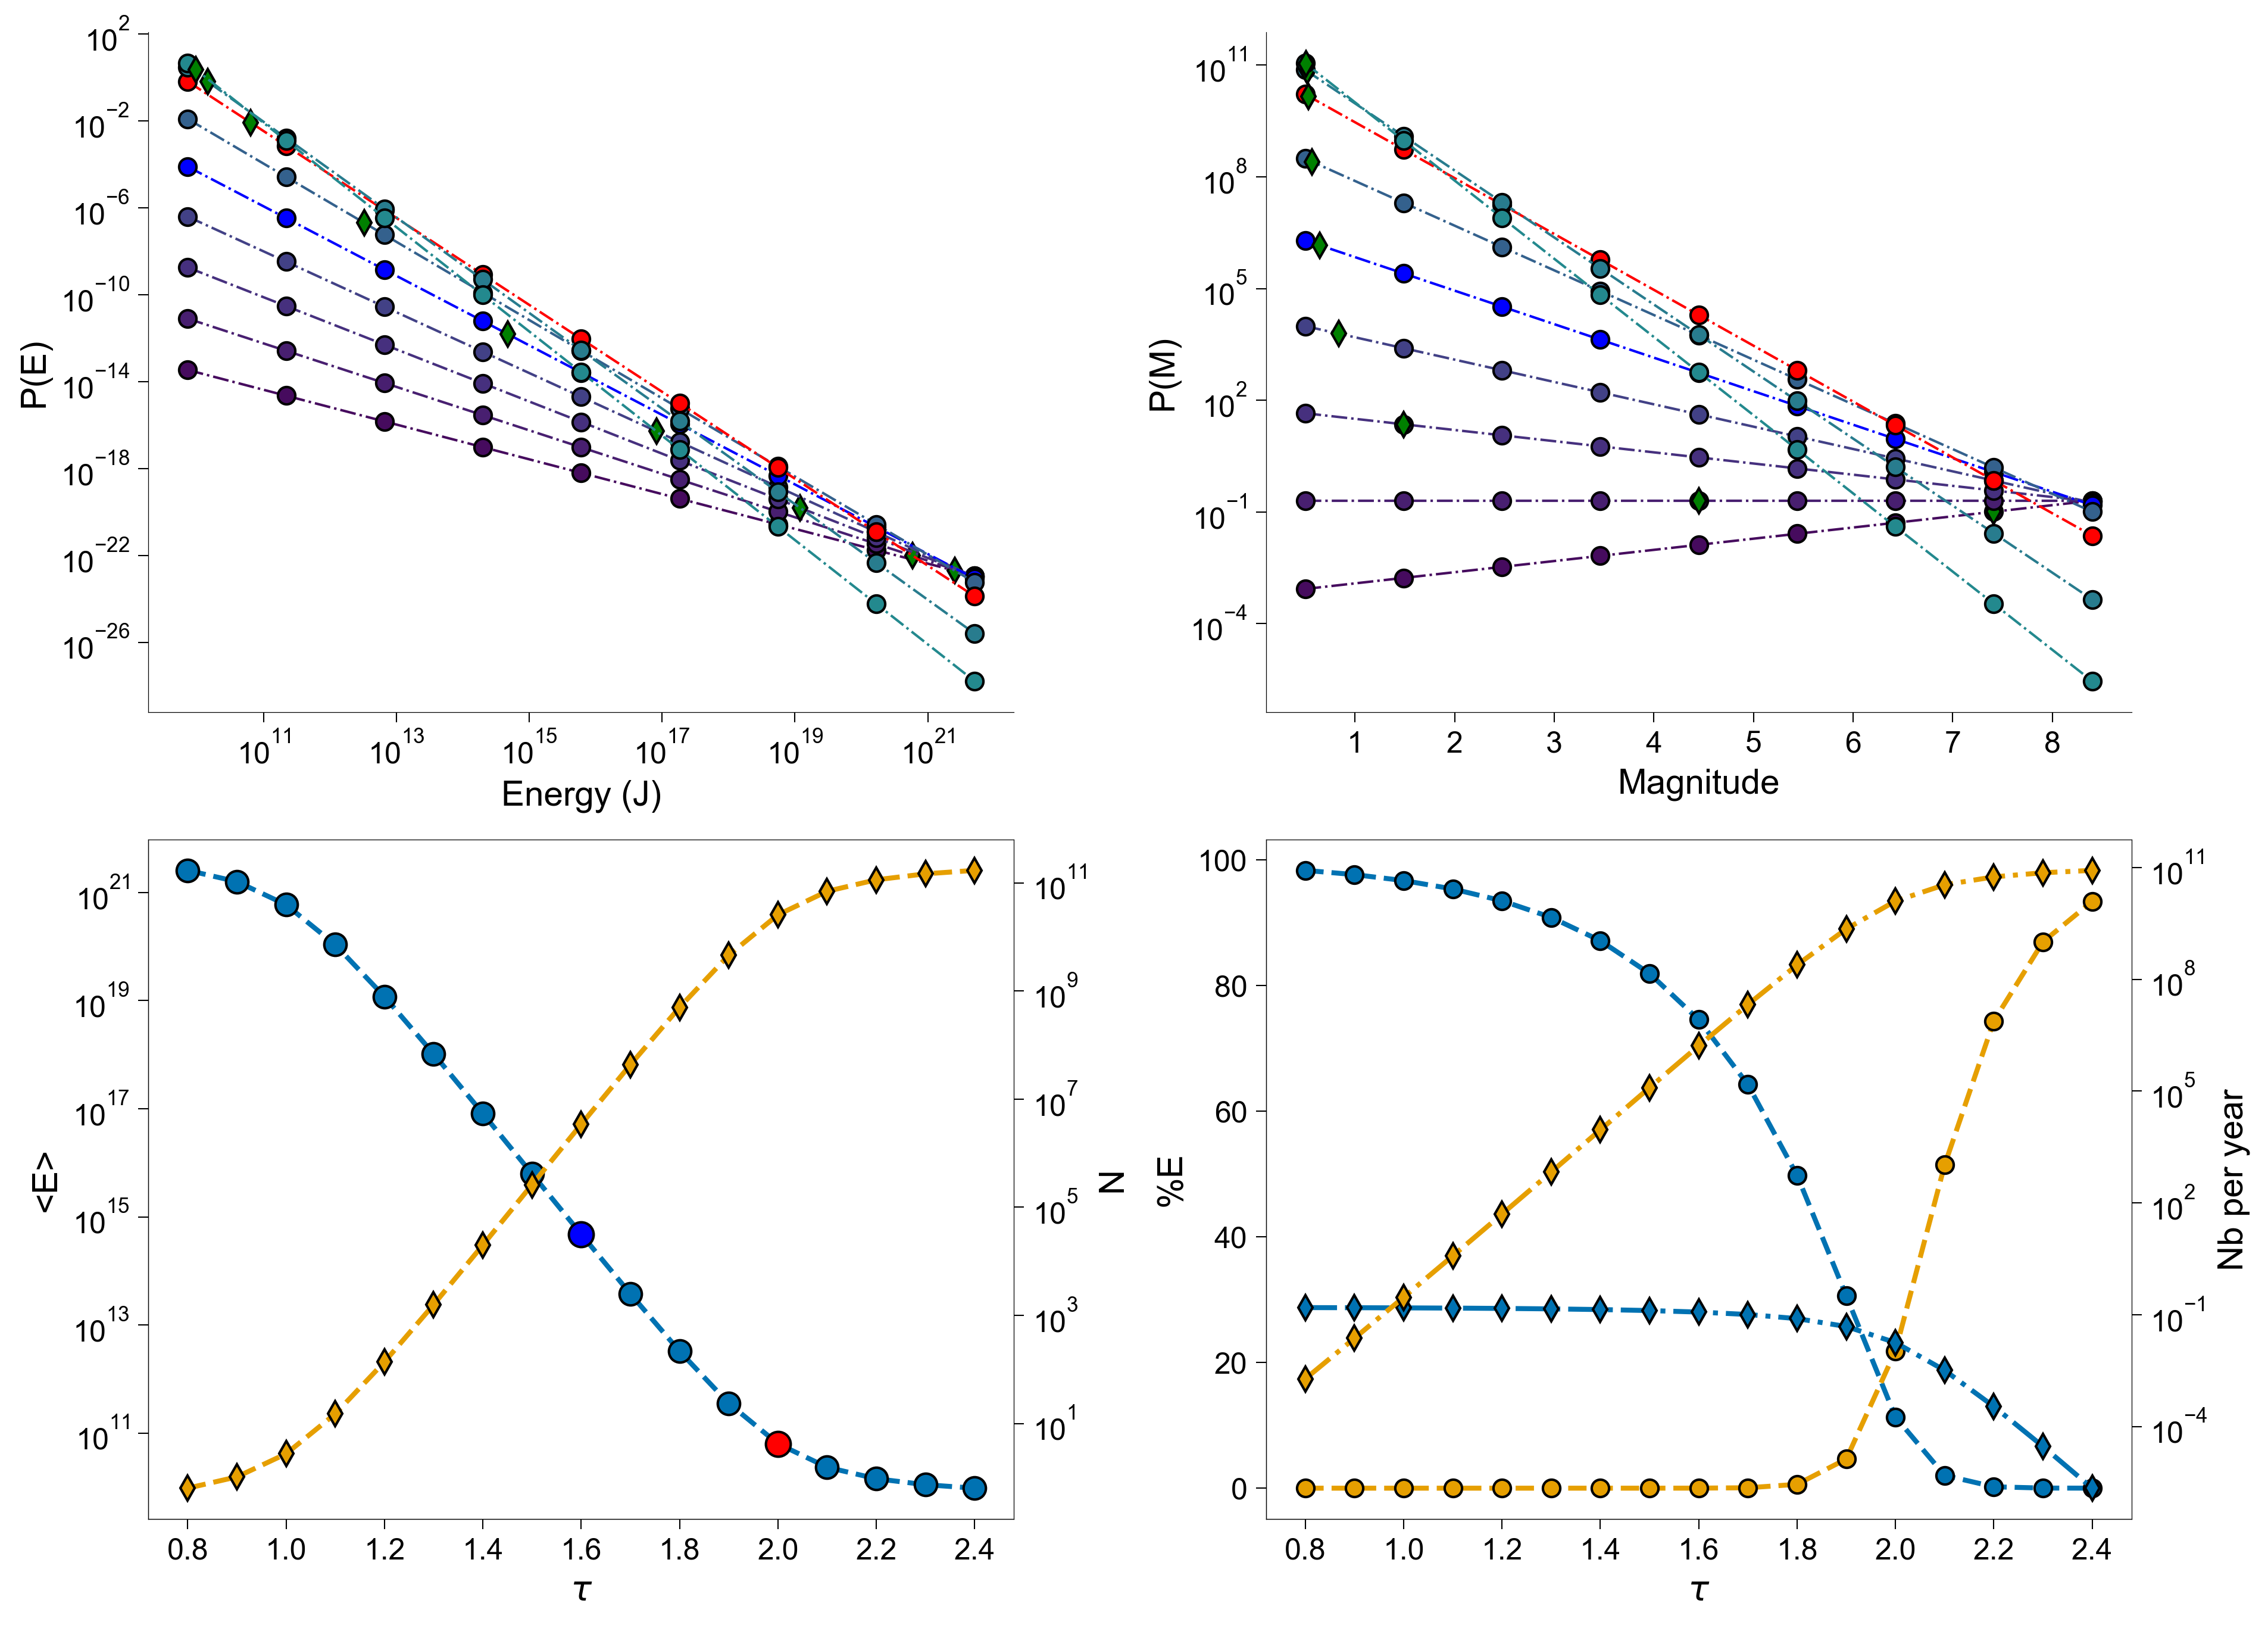

In [ ]:
NCURVES = len(tau_values)*2
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    
    fig, axs = plt.subplots(2,2, figsize = (12.8, 9.2))
    ax1 = axs[0, 0]
    ax2 = axs[0, 1]
    ax3 = axs[1, 0]
    ax4 = axs[1, 1]
    ax32 = ax3.twinx()
    ax42 = ax4.twinx()

    for n in range(1,ntot, 2):
        if tau_values[n] == 2.000001:
            ax1.plot(line01x[n], line01y[n], '-.or', linewidth=1, label=f'tau={tau_values[n]:.2f}')
            ax2.plot(magnitude_x, magnitude_y[n], '-.or', linewidth=1, label=f'tau={tau_values[n]:.2f}')
        elif tau_values[n] == 1.6:
            ax1.plot(line01x[n], line01y[n], '-.ob', linewidth=1, label=f'tau={tau_values[n]:.2f}')
            ax2.plot(magnitude_x, magnitude_y[n], '-.ob', linewidth=1, label=f'tau={tau_values[n]:.2f}')
        else:
            ax1.plot(line01x[n], line01y[n], '-.o', c = colors[n], linewidth=1)
            ax2.plot(magnitude_x, magnitude_y[n], '-.o',c = colors[n], linewidth=1)
            
        ax1.plot(mean_energy[n], mean_energy_y[n], 'dg')  # point moyen
        ax2.plot(mean_magnitude_x[n], mean_magnitude_y[n], 'dg')

    ax3.plot(tau_values[1::1], mean_energy[1::1], c = color_list[5], marker = 'o', ms = 9, ls = '--')
    ax3.scatter(tau_values[tau_values==2.000001], mean_energy[tau_values==2.000001], s = 100, c = 'r', zorder = 10)
    ax3.scatter(tau_values[tau_values==1.6], mean_energy[tau_values==1.6], s = 100, c = 'b', zorder = 10)
    # ax32.plot(tau_values[1::2], mean_magnitude_x[1::2], c = color_list[1], marker = 'd', ls = '--')
    ax32.plot(tau_values[1::1], Ntot[1::1], c = color_list[1], marker = 'd', ls = '--')
    
    ax4.plot(tau_values[1::1], P_energy8[1::1]*100, c = color_list[5], marker = 'o', ls = '--')
    ax4.plot(tau_values[1::1], P_energy02[1::1]*100, c = color_list[1], marker = 'o',ls = '--')
    ax42.plot(tau_values[1::1], Rate8[1::1], c = color_list[5], marker = 'd', ls = '-.')
    ax42.plot(tau_values[1::1], Rate02[1::1], c = color_list[1], marker = 'd', ls = '-.')
    
    print(Rate8)

    
    ax1.set_xlabel('Energy (J)')
    ax1.set_ylabel('P(E)')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    
    ax2.set_xlabel('Magnitude')
    ax2.set_ylabel('P(M)')
    ax2.set_yscale('log')
    
    ax3.set_xlabel(r'$\tau$')
    ax3.set_ylabel('<E>')
    ax3.set_yscale('log')
    ax3.spines['top'].set_visible(True)
    ax3.spines['right'].set_visible(True)
    # ax32.set_ylabel('<M>')
    ax32.set_yscale('log')
    ax32.set_ylabel('N')
    
    ax4.set_xlabel(r'$\tau$')
    ax4.set_ylabel('%E')
    ax4.spines['top'].set_visible(True)
    ax4.spines['right'].set_visible(True)
    ax42.set_ylabel('Nb per year')
    ax42.set_yscale('log')
    
    
    plt.tight_layout()
    fig.patch.set_alpha(0.0)
    plt.savefig('Ext_data_fig7.pdf', bbox_inches = 'tight', dpi = 300)


## Osvanny version


In [ ]:
def magnitude(energy):
    return (2/3) * np.log10(energy) - 6.07

def energy(magnitude):
    return 10 ** (1.5 * (magnitude + 6.07))

#%% Paramètres d'énergie
Emax = energy(8.9)  # MagMax=9.1
Emin = energy(0)          # MagMin=6.07
#Etot = 6.5297e+22 / 40 
Etot = 6.5297e+22 * 0.37 / 40         # Total yearly energy excluding tohoku 
print('Etot: ', Etot)


#tau_values = np.array([(n + 7) / 10 for n in range(18)])
tau_values = np.array([0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.67, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2])
# Init array
nbins = 9

ntot = len(tau_values)
Sum001 = np.zeros(ntot)

line01x = np.zeros((ntot, nbins))
line01y = np.zeros((ntot, nbins))

norm_line01y = np.zeros((ntot, nbins))

mean_energy = np.zeros(ntot)
mean_energy_y = np.zeros(ntot)
norm_mean_energy_y = np.zeros(ntot)

magnitude_y = np.zeros((ntot, nbins))
mag_norm_y = np.zeros((ntot, nbins))
mean_magnitude_x = np.zeros(ntot)
mean_magnitude_y = np.zeros(ntot)

P_Energy = np.zeros((ntot, nbins))
Rate_All = np.zeros((ntot, nbins))

P_energy8 = np.zeros(ntot)
P_energy0 = np.zeros(ntot)
P_energy3 = np.zeros(ntot)

Rate8 = np.zeros(ntot)
Rate0 = np.zeros(ntot)
Rate3 = np.zeros(ntot)

Ntot = np.zeros(ntot)
Etot2 = np.zeros(ntot)

energy_edges = energy(np.linspace(0, 8.9, nbins+1))
energy_center = np.array(10 ** (1.5 * (np.linspace(0,7.9,nbins) + 0.5 + 6.07)))
magnitude_x = np.linspace(0,7.9,nbins) + 0.5

# print(energy_edges)
# print(energy_center)
# print(magnitude_x)

tau_EQ = 1.67
k_orig_ref8 = Etot * (2 - tau_EQ) / (Emax ** (2 - tau_EQ) - Emin ** (2 - tau_EQ))
N_ref8 = k_orig_ref8 * ( (energy(8.9)**(1-tau_EQ)) - (energy(8)**(1-tau_EQ)) )/(1 - tau_EQ)
N_ref_tot = k_orig_ref8 * ( (energy(8.9)**(1-tau_EQ)) - (energy(0)**(1-tau_EQ)) )/(1 - tau_EQ)
E_ref8 = k_orig_ref8 * ( (energy(8.9)**(2-tau_EQ)) - (energy(8)**(2-tau_EQ)) )/(2 - tau_EQ)
E_ref_tot = k_orig_ref8 * ( (energy(8.9)**(2-tau_EQ)) - (energy(0)**(2-tau_EQ)) )/(2 - tau_EQ) #Recalc Etot 

N_tot_ref=9183139 #nb EQ

print("E tot recalc", E_ref_tot)
print("N tot recalc", N_ref_tot)
print(1/N_ref8)
T_ref8 = 13.64 #Time between two T8 = 1/N_ref8
Rate_ref8 = 1/T_ref8


for n in range(ntot):
    tau = tau_values[n]
    if tau == 2:
        tau = 2.0000001  # éviter division par zéro
        tau_values[n] = tau

    """ K1 = Emax ** (2 - tau)
    K2 = Emin ** (2 - tau)
    Sum01 = K1 - K2
    k_orig = Etot * (2 - tau) / Sum01
    line01y[n] = k_orig * energy_center ** (-tau) 
    N = line01y[n] """

    #Without normalisation
    line01x[n] = energy_center
    E = energy_center
    dE = energy_edges[1:] - energy_edges[:-1]
    
    k_orig = N_tot_ref / np.sum(energy_center**(-tau) * dE) #constant Activity Ntot
    #k_orig = Etot / np.sum(energy_center**(1-tau) * dE) #Remplace le developpement de l'intégrale pour calculer le coefficient
    line01y[n] = k_orig * energy_center ** (-tau) 
    N = line01y[n]
    
    #With normalisation
    norm = np.sum(N*dE) 
    norm_line01y[n] = N/norm
    """ check_norm = np.sum(norm_line01y[n] * dE)
    print("Test normalisation: ", check_norm) """
    """ print("Etot: ", np.sum(E * N * dE)) """
    
    mean_energy[n] = np.sum(energy_center * norm_line01y[n] * dE)
    mean_energy_y[n] = k_orig * mean_energy[n] ** (-tau)
    """ norm_mean_energy_y[n] = k_orig/norm * mean_energy[n] ** (-tau) """
    
    
    #Magnitude, largeur des bins = 1
    magnitude_y[n] = N * 1.5 * np.log(10) * E
    mag_norm_y[n] = magnitude_y[n]/np.sum(magnitude_y[n]) 
    
    """ mean_magnitude_x[n] = np.sum(magnitude_x * mag_norm_y[n])# Moyenne des magnitude """
    mean_magnitude_x[n]= magnitude(mean_energy[n]) #Moyenne des energies en magnitude

    
    Emean_mag = energy(mean_magnitude_x[n])
    yE_mag = k_orig * Emean_mag ** (-tau)
    mean_magnitude_y[n] = yE_mag * 1.5 * np.log(10) * Emean_mag
    
    """ check_norm_mag = np.sum(mag_norm_y[n])
    print("Tes norm mag: ", check_norm_mag) """
    #Pourcentage d'énergie comptenu dans une gamme de magnitude
   
    for k in range(nbins):       
        P_Energy[n,k] = np.sum(E[k:k+1] * dE[k:k+1] * N[k:k+1])/np.sum(E*N*dE)
        Rate_All[n,k] = 1/(N[k:k+1] * dE[k:k+1])
   
    P_energy8[n] = np.sum(E[-1] * dE[-1] * N[-1])/np.sum(E*N*dE)
    P_energy0[n] = np.sum(E[0:1] * dE[0:1] * N[0:1])/np.sum(E*N*dE)
    P_energy3[n] = np.sum(E[7:8] * dE[7:8] * N[7:8])/np.sum(E*N*dE)
   
    Ntot[n] = np.sum(N * dE)
    Etot2[n] = np.sum(N * dE * E)
    #print(Ntot)
    # Ntot = k_orig * ( (energy(10)**(1.00000001-tau)) - (energy(0)**(1.00000001-tau)) )/(1.00000001 - tau)
    # print(Ntot)
    N8 = N[-1] * dE[-1]
    N0 = N[0:1] * dE[0:1]
    N3 = N[7:8] * dE[7:8]
    
    Rate8[n]=1/N8
    Rate0[n]=1/N0
    Rate3[n]=1/N3
    

print(mean_energy)
for n in range(ntot):
    if tau_values[n] == 1.67:
        n_eq=n
        MeanE_EQ=mean_energy[n]
        print(mean_magnitude_x[n])
        
print (mean_energy[n_eq-7]/mean_energy[n_eq])        
print (1/(mean_energy[n_eq+2]/mean_energy[n_eq+1]))  
print (Rate_All[n_eq ,8])  
print (Rate_All[n_eq ,0]*365.25*24*60*60)   
print (1/Rate_All[n_eq-7 ,8])    
print (Rate_All[n_eq-7 ,8]*365.25*24*60*60)                     
print (Rate_All[n_eq+3 ,8]) 
print (P_Energy[n_eq+4 ,8]) 
print(mean_magnitude_x[n_eq])



Etot:  6.0399725e+20
E tot recalc 6.0399725e+20
N tot recalc 9183139.259246789
13.639539848019648
[3.29554287e+21 2.56702094e+21 1.58852325e+21 5.93701485e+20
 1.08272413e+20 1.18530668e+19 1.03213413e+18 8.17617146e+16
 6.24800583e+15 4.77237876e+14 8.02919305e+13 3.77434336e+13
 3.27365183e+12 3.54966510e+11 6.35266079e+10 2.32986886e+10
 1.42783761e+10]
3.199781266578759
7394285.851286553
11.529458707113516
10.155113219692366
3.827854341055413
1040036.7119256615
30.342775056055558
5082.706421528103
0.11325487988008129
3.199781266578759


/home/oramos/.local/lib/python3.8/site-packages/sciplotlib/stylesheets/nature-reviews.mplstyle


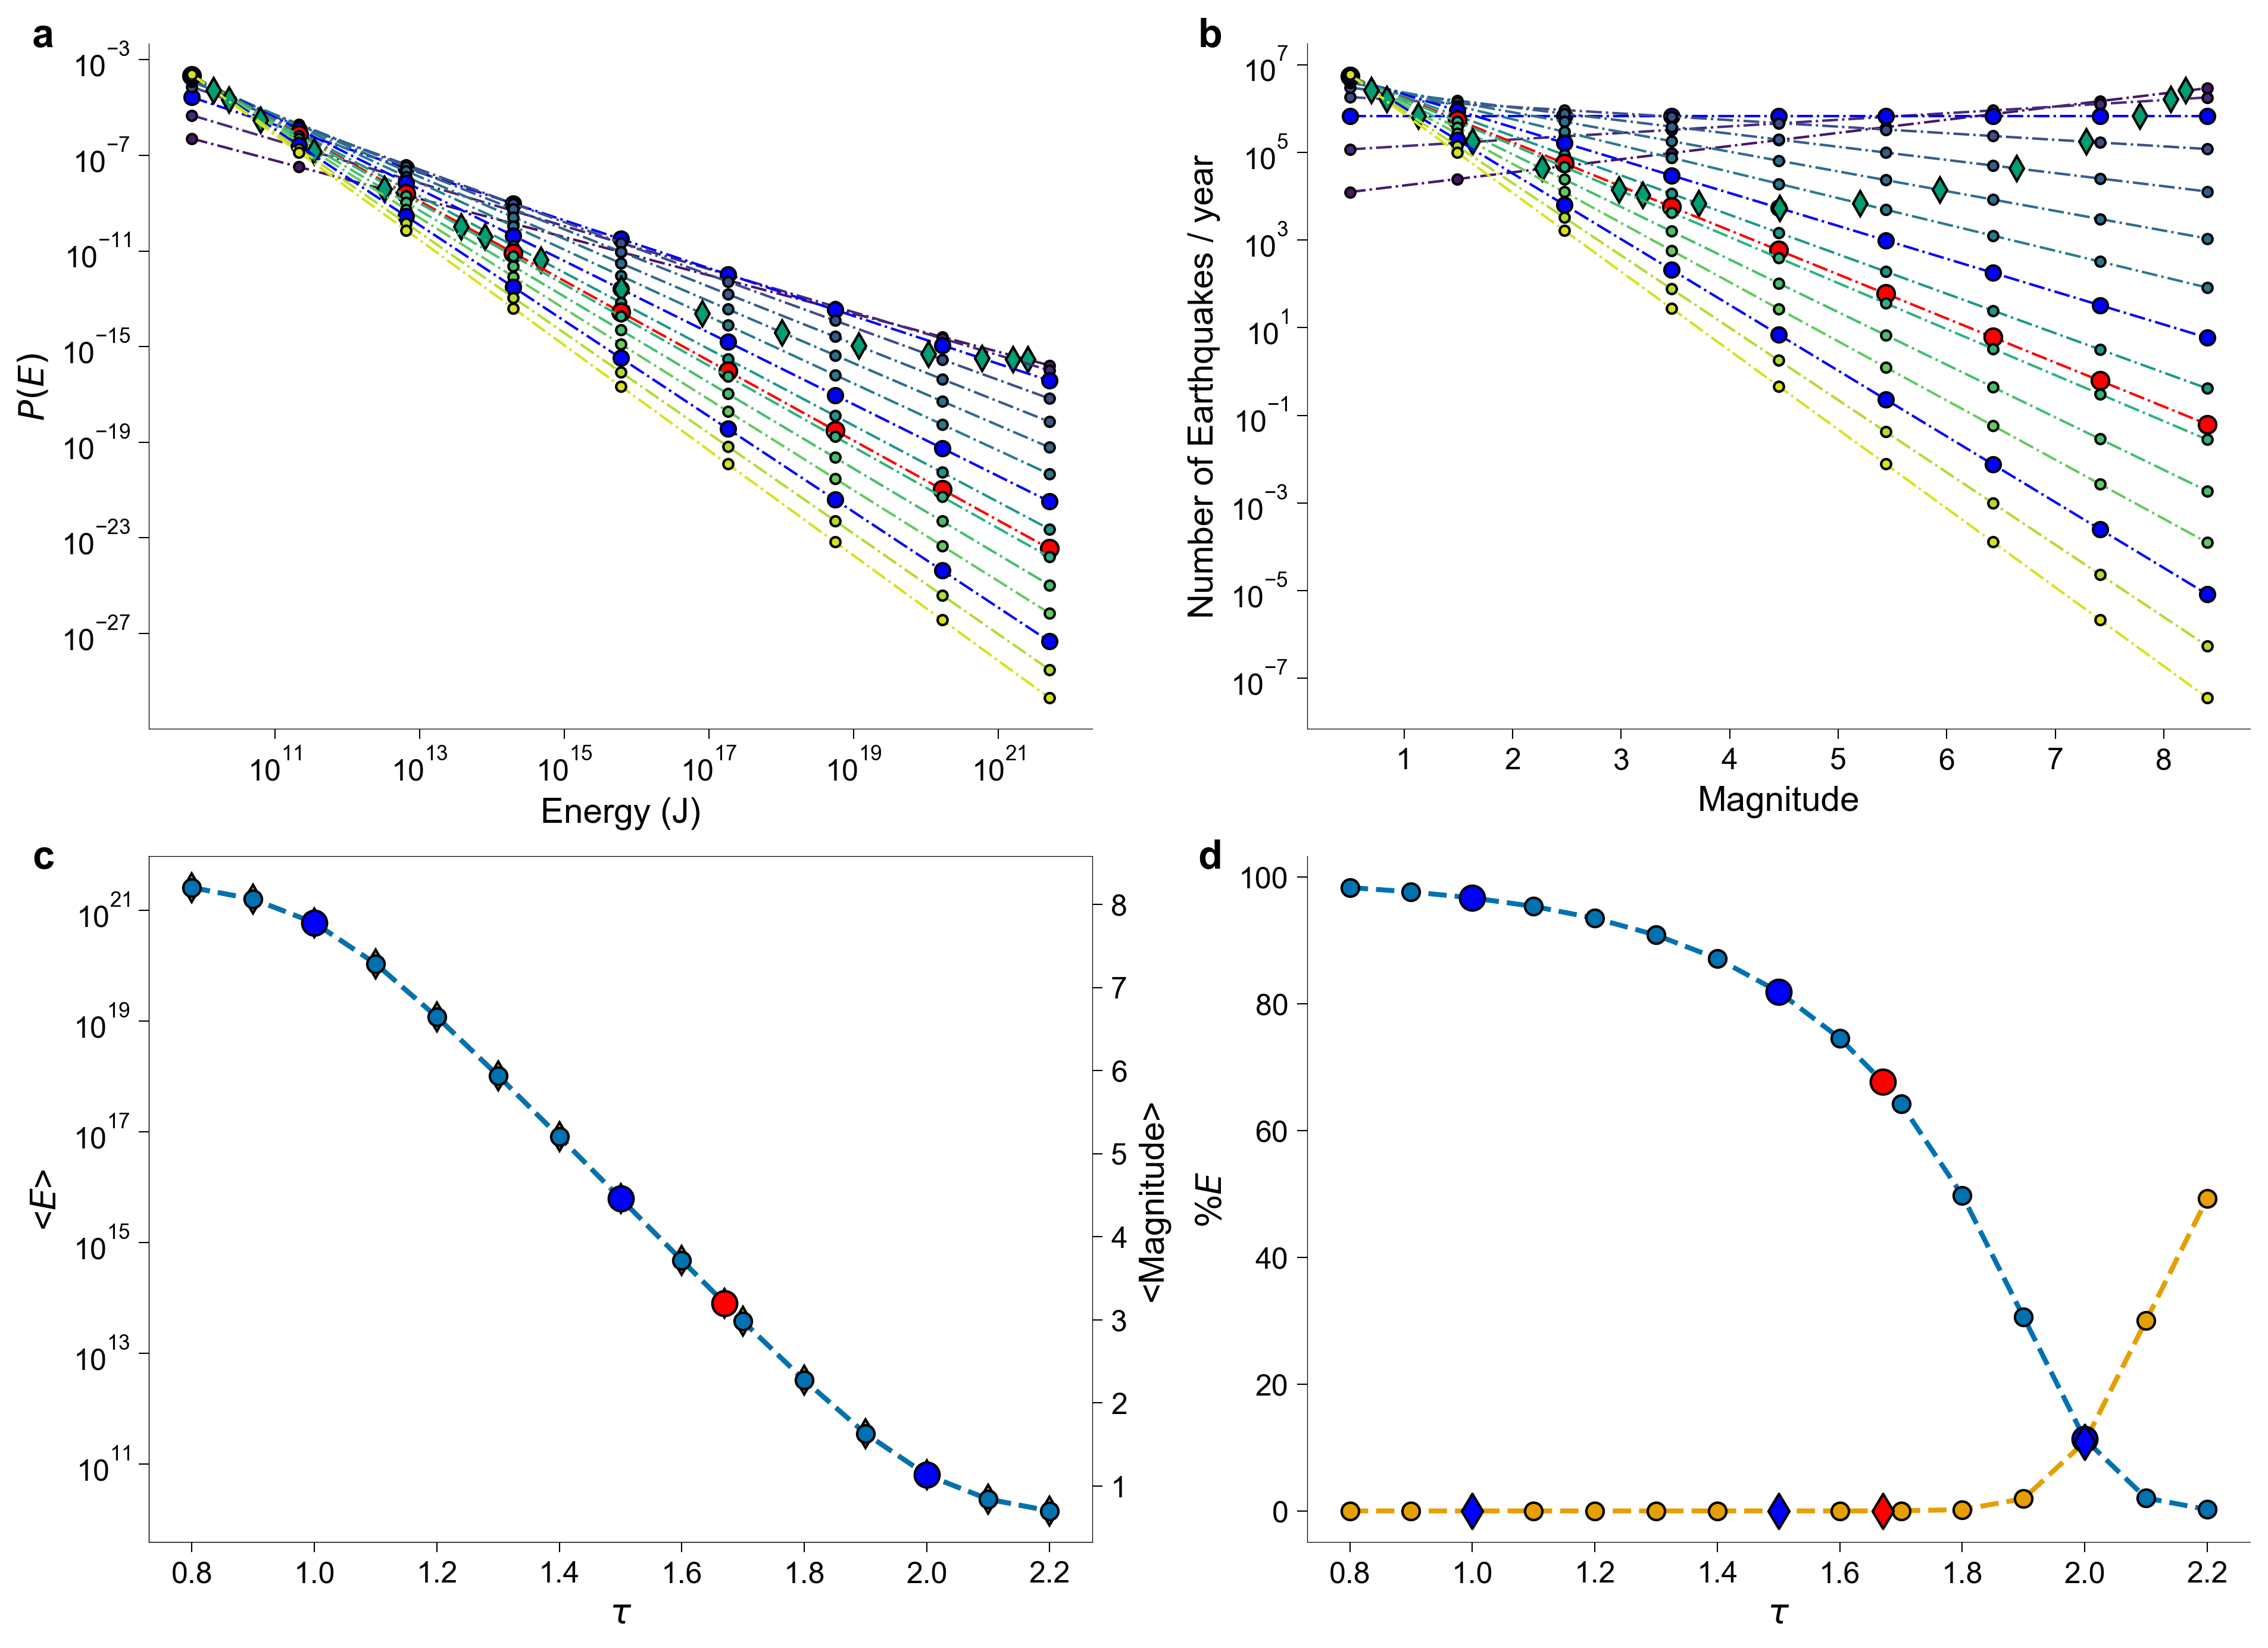

In [ ]:

color_list = ['#000000', '#e69f00', '#56b4e9', '#009e73',
              '#f0e442', '#0072b2', '#d55e00', '#cc79a7']

NCURVES = len(tau_values)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

with plt.style.context(spstyle.get_style('nature-reviews')):
    print(spstyle.get_style('nature-reviews'))
    plt.rcParams['font.family'] = 'Arial' 
    
    fig, axs = plt.subplots(2,2, figsize = (12.8, 9.2))
    ax1 = axs[0, 0]
    ax2 = axs[0, 1]
    ax3 = axs[1, 0]
    ax4 = axs[1, 1]
    ax32 = ax3.twinx()

    for n in range(1,ntot, 1):
        if tau_values[n] == 2.0000001:
            ax1.plot(line01x[n], line01y[n], '-.o', ms = 6, lw=1, label=f'tau={tau_values[n]:.2f}', c = 'b')
            ax2.plot(magnitude_x, magnitude_y[n], '-.o', ms = 6, lw=1, label=f'tau={tau_values[n]:.2f}', c = 'b')
        elif tau_values[n] == 1.5:
            ax1.plot(line01x[n], line01y[n], '-.o',ms = 6, lw=1, label=f'tau={tau_values[n]:.2f}', c = 'b')
            ax2.plot(magnitude_x, magnitude_y[n], '-.o', ms = 6, lw=1, label=f'tau={tau_values[n]:.2f}', c = 'b')  
        elif tau_values[n] == 1.0:
            ax1.plot(line01x[n], line01y[n], '-.o', ms = 6, lw=1, label=f'tau={tau_values[n]:.2f}', c = 'b')
            ax2.plot(magnitude_x, magnitude_y[n], '-.o',ms = 6, lw=1, label=f'tau={tau_values[n]:.2f}', c = 'b')
        elif tau_values[n] == 1.67:
            ax1.plot(line01x[n], line01y[n], '-.o', lw=1, label=f'tau={tau_values[n]:.2f}', c = 'r')
            ax2.plot(magnitude_x, magnitude_y[n], '-.o', lw=1, label=f'tau={tau_values[n]:.2f}', c = 'r')
        else:
            ax1.plot(line01x[n], line01y[n], '-.o', ms = 4, c = colors[n], linewidth=1)
            ax2.plot(magnitude_x, magnitude_y[n], '-.o', ms = 4, c = colors[n], linewidth=1)
            
            
        ax1.plot(mean_energy[n], mean_energy_y[n], marker = 'd', c = color_list[3])  # point moyen
        ax2.plot(mean_magnitude_x[n], mean_magnitude_y[n], marker = 'd', c = color_list[3])


    ax32.plot(tau_values[1::1], mean_magnitude_x[1::1], c = color_list[5], marker = 'o', ls = '--')
    ax32.scatter(tau_values[tau_values==2.0000001], mean_magnitude_x[tau_values==2.0000001], c = 'b', s = 100, zorder = 10)
    ax32.scatter(tau_values[tau_values==1.67], mean_magnitude_x[tau_values==1.67], c = 'r', s = 100, zorder = 10)
    ax32.scatter(tau_values[tau_values==1.0], mean_magnitude_x[tau_values==1.0], c = 'b', s = 100, zorder = 10)
    ax32.scatter(tau_values[tau_values==1.5], mean_magnitude_x[tau_values==1.5], c = 'b', s = 100, zorder = 10)

    ax3.plot(tau_values[1::1], mean_energy[1::1], c = color_list[1], marker = 'd', ls = '--', ms = 8)

    ax4.plot(tau_values[1::1], P_energy8[1::1]*100, c = color_list[5], marker = 'o', ls = '--')
    ax4.plot(tau_values[1::1], P_energy0[1::1]*100, c = color_list[1], marker = 'o',ls = '--')
    ax4.scatter(tau_values[tau_values==2.0000001], P_energy8[tau_values==2.0000001]*100, marker = 'o', s = 100, c = 'b', zorder = 10)
    ax4.scatter(tau_values[tau_values==1.5], P_energy8[tau_values==1.5]*100, marker = 'o', s = 100, c = 'b', zorder = 10)
    ax4.scatter(tau_values[tau_values==1], P_energy8[tau_values==1]*100, marker = 'o', s = 100, c = 'b', zorder = 10)
    ax4.scatter(tau_values[tau_values==1.67], P_energy8[tau_values==1.67]*100, marker = 'o', s = 100, c = 'r', zorder = 10)
    
    ax4.scatter(tau_values[tau_values==2.0000001], P_energy0[tau_values==2.0000001]*100, marker = 'd', s = 100, c = 'b', zorder = 10)
    ax4.scatter(tau_values[tau_values==1.5], P_energy0[tau_values==1.5]*100, marker = 'd', s = 100, c = 'b', zorder = 10)
    ax4.scatter(tau_values[tau_values==1], P_energy0[tau_values==1]*100, marker = 'd', s = 100, c = 'b', zorder = 10)
    ax4.scatter(tau_values[tau_values==1.67], P_energy0[tau_values==1.67]*100, marker = 'd', s = 100, c = 'r', zorder = 10)
    #ax62.plot(tau_values[1::1], P_Energy[1::1,:]*100, c = color_list[5],ls = '--')


    ax1.set_xlabel('Energy (J)')
    ax1.set_ylabel(r'$P(E)$')
    ax1.set_xscale('log')
    ax1.set_yscale('log')

    ax2.set_xlabel('Magnitude')
    ax2.set_ylabel('Number of Earthquakes / year')
    ax2.set_yscale('log')

    ax3.set_xlabel(r'$\tau$')
    ax3.set_ylabel(r'<$E$>')
    ax3.set_yscale('log')
    ax3.spines['top'].set_visible(True)
    ax3.spines['right'].set_visible(True)
    # ax32.set_ylabel('<M>')
    #ax32.set_yscale('log')
    ax32.set_ylabel('<Magnitude>')

    
    ax4.set_xlabel(r'$\tau$')
    ax4.set_ylabel(r'$\%E$')
    #ax4.set_yscale('log')
    # ax4.spines['top'].set_visible(True)
    # ax4.spines['right'].set_visible(True)
    #ax62.set_yscale('log')
    
    fig.text(0.018, 0.98, "a", fontsize=16, fontweight="bold") 
    fig.text(0.528, 0.98, "b", fontsize=16, fontweight="bold")
    fig.text(0.018, 0.48, "c", fontsize=16, fontweight="bold") 
    fig.text(0.528, 0.48, "d", fontsize=16, fontweight="bold")
    
    fig.patch.set_alpha(0.0)
    plt.tight_layout()
    plt.savefig('Ext_data_fig7.pdf', bbox_inches = 'tight', dpi = 300)


#   Ext dat fig1

In [1]:
def load_and_process_csv(file_path):
    # Charger les données CSV avec pandas
    df = pd.read_csv(file_path)
    # Convertir en numpy array pour traitement similaire
    dataN = df.to_numpy()
    return dataN

def GRlaw(Corners4, mag_ini, mag_end, newdataN, yr_min, inv1):
    x2a = Corners4[0]
    x2b = Corners4[1]
    y2a = Corners4[2]
    y2b = Corners4[3]

    min_depth = -10  # km
    ntot1 = newdataN.shape[0]

    distmag = np.zeros((mag_end - mag_ini, 2))  # (bins, 2)

    for n in range(ntot1):
        for p in range(mag_ini, mag_end):
            # indices Python : distmag[p - mag_ini, :]
            # Extraction colonnes avec indexation 0-based:
            year = newdataN[n, 0]
            lat = newdataN[n, 6]
            lon = newdataN[n, 7]
            depth = newdataN[n, 8]
            mag = newdataN[n, 9]

            # Conditions premières :
            cond1 = (year >= yr_min) and (depth > min_depth) and (mag >= p) and (mag < p + 1) \
                    and (lat >= y2a) and (lat <= y2b)

            # Case inv1==0 : longitude entre x2a et x2b
            if cond1 and (lon >= x2a) and (lon <= x2b) and (not inv1):
                distmag[p - mag_ini, 0] += 1
                distmag[p - mag_ini, 1] = p + 0.5

            # Case inv1==1 : longitude entre x2a et 180 OU -180 et x2b (méridien 180 traversé)
            if inv1 == 1 and cond1 and ((lon >= x2a and lon <= 180) or (lon >= -180 and lon <= x2b)):
                distmag[p - mag_ini, 0] += 1
                distmag[p - mag_ini, 1] = p + 0.5

    return distmag

def GRlawSMoment(corners4, mag_ini, mag_end, newdataN, yr_min, inv1=False):
    """
    Estime la densité d'énergie sismique par bin de magnitude dans une zone géographique.
    
    Parameters:
        corners4 : list or array of float
            [lon_min, lon_max, lat_min, lat_max]
        mag_ini : int
            Magnitude minimale (ex. 4)
        mag_end : int
            Magnitude maximale (ex. 9)
        newdataN : np.ndarray
            Table d’événements : colonnes = [annee, ..., lat (7), lon (8), profondeur (9), magnitude (10)]
        yr_min : int
            Année minimale à considérer
        inv1 : bool
            True si on traverse la ligne de changement de date (180°)
    
    Returns:
        distSM : np.ndarray of shape (mag_end - mag_ini, 2)
            distSM[:,0] = densité d’énergie sismique par bin
            distSM[:,1] = énergie moyenne pour chaque bin de magnitude
    """

    x2a, x2b, y2a, y2b = corners4
    min_depth = 1  # km

    n_bins = mag_end - mag_ini
    distmag = np.zeros((n_bins, 2))
    distSM = np.zeros((n_bins, 2))

    N_events = 0
    for n in range(newdataN.shape[0]):
        year = newdataN[n, 0]
        lat = newdataN[n, 6]
        lon = newdataN[n, 7]
        depth = newdataN[n, 8]
        mag = newdataN[n, 9]

        for p in range(mag_ini, mag_end):
            in_mag_bin = (mag >= p) and (mag < p + 1)
            in_area = (x2a <= lon <= x2b) and (y2a <= lat <= y2b)
            in_cross_area = ((x2a <= lon <= 180) or (-180 <= lon <= x2b)) and (y2a <= lat <= y2b)

            if year >= yr_min and depth > min_depth and in_mag_bin:
                if (not inv1 and in_area) or (inv1 and in_cross_area):
                    idx = p - mag_ini
                    distmag[idx, 0] += 1
                    distmag[idx, 1] = p + 0.5
                    N_events += 1

    # Constantes pour conversion magnitude → énergie
    cst = 1.5 * 6.07  # correspond à 10^(1.5M + cst)

    SumE = 0
    SumE2 = 0

    for p in range(mag_ini, mag_end):
        idx = p - mag_ini
        mag_bin_center = p + 0.5
        e_center = 10 ** (1.5 * mag_bin_center + cst)
        e_bin = 10 ** (1.5 * (p + 1) + cst) - 10 ** (1.5 * p + cst)

        distSM[idx, 1] = e_center
        distSM[idx, 0] = distmag[idx, 0] / e_bin if e_bin != 0 else 0

        SumE += e_center * distSM[idx, 0]
        SumE2 += distSM[idx, 0] * e_bin

    print(f"N_events: {N_events}")
    print(f"SumE: {SumE:.3e}")
    print(f"SumE2: {SumE2:.3e}")

    return distSM

In [ ]:
#%%# Chargement des données Japan.csv
data_jap = load_and_process_csv('/home/kduplat/Documents/Data/Pscript2/Papier_Memory/RealEarthquakes/Japan.csv')
ntot1, n = data_jap.shape
total_events = ntot1


In [7]:

#%%
# Définition des coins pour le Japon
Corners_Japan = [123, 163, 26, 58]
x2a, x2b = Corners_Japan[0], Corners_Japan[1]
y2a, y2b = Corners_Japan[2], Corners_Japan[3]

min_depth = -10  # km
YearIni = 1983
YearEnd = 2023

# Conversion des dates en années (équivalent MATLAB)
date2 = ((YearEnd - YearIni) / (data_jap[-1,10] - data_jap[1,10])) * (data_jap[:,10] - data_jap[-1,10]) + YearEnd
data2 = data_jap[:,9]  # Magnitude, index ajusté -1 par rapport à MATLAB

# Moment sismique cumulatif Japon
SMR1_jap = np.zeros((ntot1, 2))
mag_min = 0
ymin = 1980

k = -1
for i in range(ntot1):
    if (data_jap[i,9] >= mag_min and data_jap[i,0] >= ymin and
        data_jap[i,8] > min_depth and x2a <= data_jap[i,7] <= x2b and y2a <= data_jap[i,6] <= y2b):
        k += 1
        SMR1_jap[k, 1] = data_jap[i,11] if k == 0 else SMR1_jap[k-1, 1] + data_jap[i,11]
        SMR1_jap[k, 0] = date2[i]

SMR1_jap = SMR1_jap[:k+1]


#%% Loi de Gutenberg-Richter (exemple avec GRlaw)
mag_ini, mag_end = 3, 10
distMAG = np.zeros((mag_end - mag_ini, 2, 2))

distMAG[:, :, 0] = GRlaw(Corners_Japan, mag_ini, mag_end, data_jap, 2000, 0)

Fitx = distMAG[2:6, 1, 0]  # Japon
Fity = np.log10(distMAG[2:6, 0, 0] / (2023 - 2000))
P1 = np.polyfit(Fitx, Fity, 1)

# Loi GR selon le moment sismique
distMAGMom_jap = np.zeros((mag_end - mag_ini, 2, 2))
distMAGMom_jap[:, :, 0] = GRlawSMoment(Corners_Japan, mag_ini, mag_end, data_jap, 2000, 0)

Fitx = np.log10(distMAGMom_jap[2:6, 1, 0])
Fity = np.log10(distMAGMom_jap[2:6, 0, 0] / (2023 - 2000))
P1 = np.polyfit(Fitx, Fity, 1)

line8x_jap = 10 ** (1.5 * (np.arange(mag_ini+2, mag_end) + 0.5) + 1.5 * 6.07)
line8y_jap = 10 ** (P1[0] * (1.5 * (np.arange(mag_ini+2, mag_end) + 0.5) + 1.5 * 6.07) + P1[1])

line9x_jap = 10 ** (1.5 * (np.arange(mag_ini, mag_end) + 0.5) + 1.5 * 6.07)
line9y_jap = 10 ** (P1[0] * (1.5 * (np.arange(mag_ini, mag_end) + 0.5) + 1.5 * 6.07) + P1[1])


N_events: 145800
SumE: 2.677e+04
SumE2: 1.458e+05


In [10]:
from datetime import datetime
#%% --- Même logique pour la Californie ---

data_cal = load_and_process_csv('/home/kduplat/Documents/Data/Pscript2/Papier_Memory/RealEarthquakes/CaliforniaM01.csv')
ntot1, n = data_cal.shape
total_events = ntot1
#%%
MPI = -360
Corners_California = [238.24 + MPI, 246.85 + MPI, 30.0948, 39.5]
x2a, x2b = Corners_California[0], Corners_California[1]
y2a, y2b = Corners_California[2], Corners_California[3]

min_depth = -10
YearIni = 1980
YearEnd = 2023

date2 = ((YearEnd - YearIni) / (data_cal[-1,10] - data_cal[0,10])) * (data_cal[:,10] - data_cal[-1,10]) + YearEnd
data2 = data_cal[:,9]

#%%
magyear = np.zeros((44, 10))
numyear = np.zeros((44, 10))

for y1 in range(1980, 2024):
    y11 = datetime(y1 - 1, 12, 31, 23, 59, 59, 990000).timestamp()
    y12 = datetime(y1, 12, 31, 23, 59, 59, 990000).timestamp()
    for i in range(ntot1):
        for mag01 in range(1, 10):
            if (mag01 <= data2[i] < mag01 + 1 and
                y11 <= data_cal[i,10] < y12 and
                data_cal[i,8] > min_depth and
                x2a <= data_cal[i,7] <= x2b and
                y2a <= data_cal[i,6] <= y2b):
                magyear[y1 - 1980, mag01 - 1] += 1
                numyear[y1 - 1980, mag01 - 1] = y1

SMR1_cal = np.zeros((ntot1, 2))
mag_min = 0
ymin = 1980

k = -1
for i in range(ntot1):
    if (data_cal[i,9] >= mag_min and data_cal[i,0] >= ymin and
        data_cal[i,8] > min_depth and x2a <= data_cal[i,7] <= x2b and y2a <= data_cal[i,6] <= y2b):
        k += 1
        SMR1_cal[k, 1] = data_cal[i,11] if k == 0 else SMR1_cal[k-1, 1] + data_cal[i,11]
        SMR1_cal[k, 0] = date2[i]

SMR1_cal = SMR1_cal[:k+1]

#%% Loi de Gutenberg-Richter (exemple avec GRlaw)
mag_ini, mag_end = 1, 8

distMAGMom_cal = np.zeros((mag_end - mag_ini, 2))
distMAGMom_cal[:, :] = GRlawSMoment(Corners_California, mag_ini, mag_end, data_cal, 1980, 0)

Fitx = np.log10(distMAGMom_cal[2:6, 1])
Fity = np.log10(distMAGMom_cal[2:6, 0] / (2023 - 1980))

P1 = np.polyfit(Fitx, Fity, 1)

line8x_cal = 10 ** (1.5 * (np.arange(mag_ini, mag_end) + 0.5) + 1.5 * 6.07)
line8y_cal = 10 ** (P1[0] * (1.5 * (np.arange(mag_ini, mag_end) + 0.5) + 1.5 * 6.07) + P1[1])

line9x_cal = 10 ** (1.5 * (np.arange(mag_ini, mag_end) + 0.5) + 1.5 * 6.07)
line9y_cal = 10 ** (P1[0] * (1.5 * (np.arange(mag_ini, mag_end) + 0.5) + 1.5 * 6.07) + P1[1])


N_events: 507201
SumE: 9.314e+04
SumE2: 5.072e+05


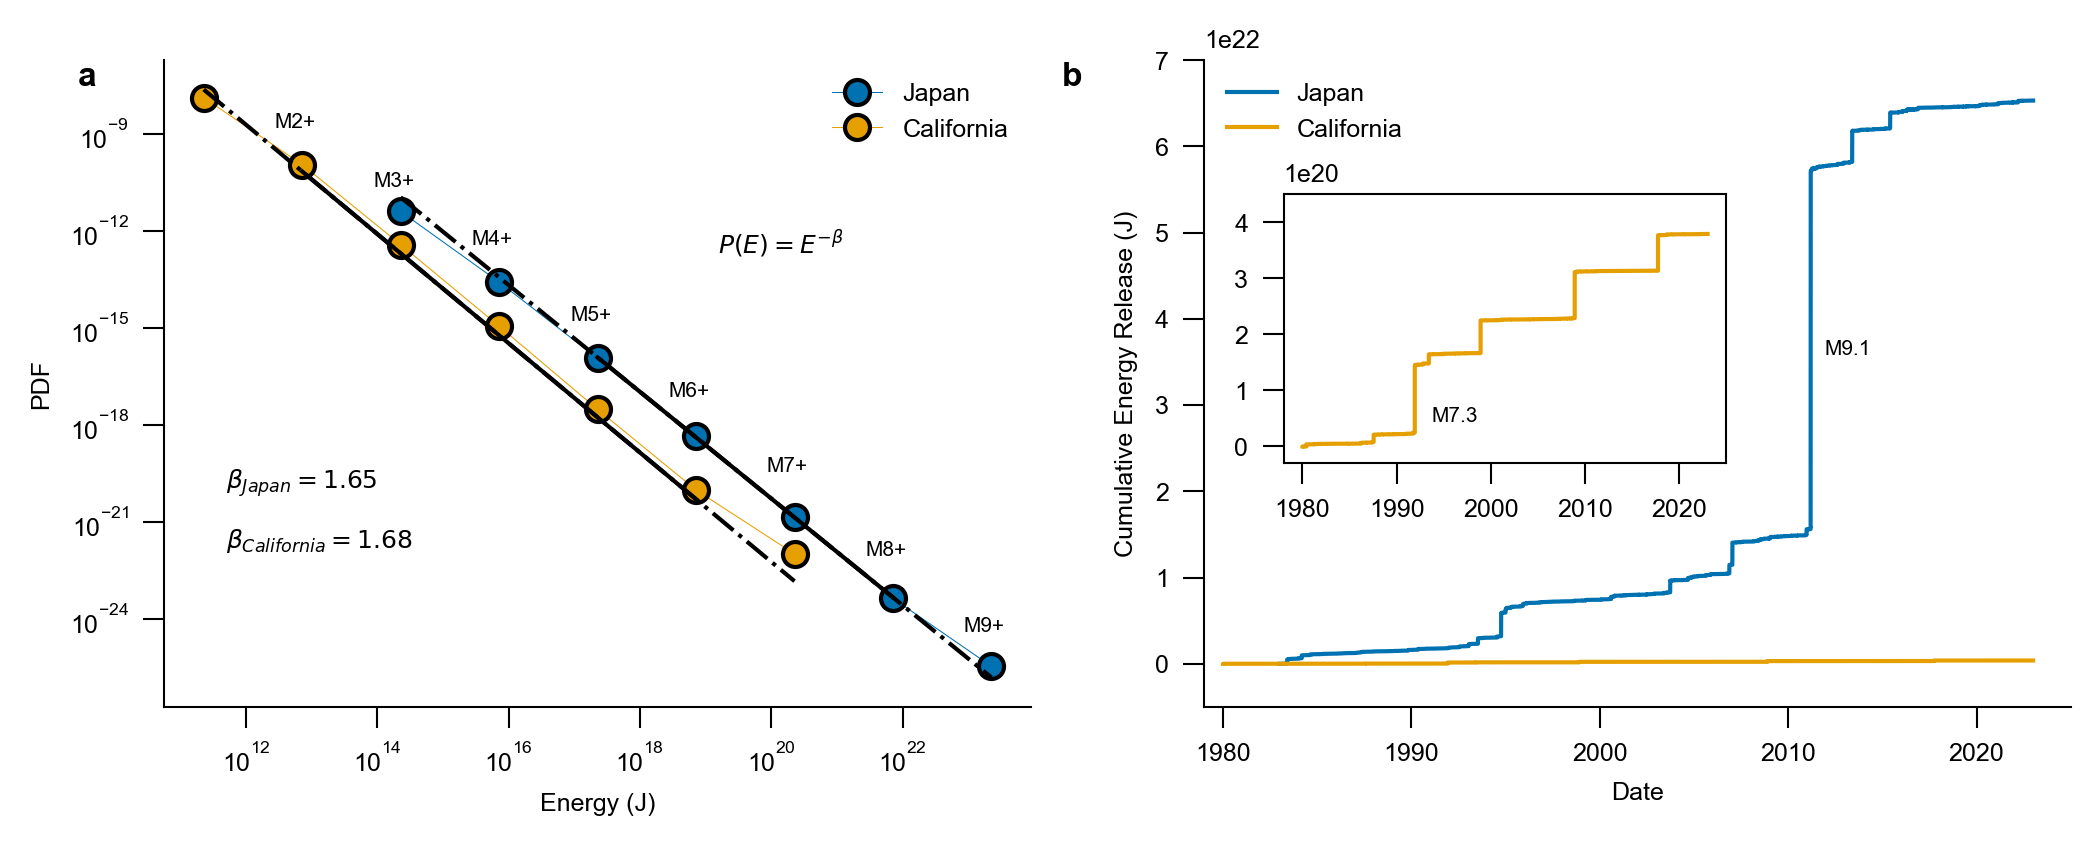

In [16]:

# %%
#%pip install SciencePlots
color_list = ['#000000', '#e69f00', '#56b4e9', '#009e73',
              '#f0e442', '#0072b2', '#d55e00', '#cc79a7']
mask = distMAGMom_cal[:, 0]!= 0
import sciplotlib.style as spstyle
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, (ax1, ax2) = plt.subplots(1,2, figsize = (8.2,2.8))
    
    ax1.loglog(distMAGMom_jap[:, 1, 0], distMAGMom_jap[:, 0, 0] / 23, ls = '-', linewidth=0.25, color = color_list[5], marker = 'o', label = 'Japan')
    ax1.loglog(distMAGMom_cal[mask][:, 1], distMAGMom_cal[mask][:, 0] / 23, ls = '-', linewidth=0.25, color = color_list[1], marker = 'o', label = 'California')
    ax1.loglog(line8x_jap[:-1], line8y_jap[:-1], '-k', linewidth=1)
    ax1.loglog(line9x_jap, line9y_jap, '-.', color='k', linewidth=1)
    ax1.loglog(line8x_cal[1:-1], line8y_cal[1:-1], '-k', linewidth=1)
    ax1.loglog(line9x_cal[:7], line9y_cal[:7], '-.', color='k', linewidth=1)
    ax1.set_xlabel('Energy (J)')
    ax1.set_ylabel('PDF')
    ax1.legend(loc = 'upper right')
    
    ax2.plot(SMR1_jap[::10, 0], SMR1_jap[::10, 1], color = color_list[5], label = 'Japan')
    ax2.plot(SMR1_cal[::10, 0], SMR1_cal[::10, 1], color = color_list[1], label = 'California')
    ax2.axis([1980, 2025, -5e21, 7e22])
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Cumulative Energy Release (J)')
    ax2.legend(loc = 'upper left')
    ax2.set_xlim(1979,2025)
    
    ax3 = fig.add_axes([0.58, 0.4, 0.18, 0.32])
    ax3.plot(SMR1_cal[:, 0], SMR1_cal[:, 1], color = color_list[1])
    ax3.axis([1980, 2025, -3e19, 4.5e20])
    ax3.spines['top'].set_visible(True)
    ax3.spines['right'].set_visible(True)
    ax3.set_xlim(1978,2025)

    
    fig.text(0.15, 0.37, r'$\beta_{Japan} = 1.65$', fontsize=6) 
    fig.text(0.15, 0.3, r'$\beta_{California} = 1.68$', fontsize=6) 
    fig.text(0.35, 0.65, r'$P(E) = E^{-\beta}$', fontsize=6) 
    fig.text(0.17, 0.8, 'M2+', fontsize=5)
    fig.text(0.21, 0.73, 'M3+', fontsize=5) 
    fig.text(0.25, 0.66, 'M4+', fontsize=5) 
    fig.text(0.29, 0.57, 'M5+', fontsize=5) 
    fig.text(0.33, 0.48, 'M6+', fontsize=5) 
    fig.text(0.37, 0.39, 'M7+', fontsize=5) 
    fig.text(0.41, 0.29, 'M8+', fontsize=5) 
    fig.text(0.45, 0.2, 'M9+', fontsize=5) 
    
    fig.text(0.64, 0.45, 'M7.3', fontsize=5) 
    fig.text(0.8, 0.53, 'M9.1', fontsize=5) 

    fig.text(0.09, 0.85, "a", fontsize=8, fontweight="bold") 
    fig.text(0.49, 0.85, "b", fontsize=8, fontweight="bold") 

    
    fig.patch.set_alpha(0.0)
    plt.savefig("Ext_data_fig1.pdf", bbox_inches='tight', dpi = 300)
    plt.show()


# %%


# Save data into xlsx format

##  Figure 1

##  Figure 2

In [126]:
data = np.load("Figure2.npz", allow_pickle=True)

Tvar = data["Tvar"]
Ttau_s = data["Ttau_s"]
Tbins_s = data["Tbins_s"]
Thisto_s = data["Thisto_s"]
Txfit_s = data["Txfit_s"]
Tyfit_s = data["Tyfit_s"]
Tnonzero_s= data["Tnonzero_s"] 
Tmean_s= data["Tmean_s"]
Tmean_t= data["Tmean_t"]
Tmean_diff= data["Tmean_diff"]

In [127]:
label =[]
[label.extend(["s", "P(s) (nu = {})".format(nu), "s", "power-law fit (nu = {})".format(nu)]) for nu in Tvar]
label = pd.Series(label)
label.astype("category")
label.astype(str)

0                              s
1                P(s) (nu = 0.0)
2                              s
3       power-law fit (nu = 0.0)
4                              s
5              P(s) (nu = 0.005)
6                              s
7     power-law fit (nu = 0.005)
8                              s
9               P(s) (nu = 0.01)
10                             s
11     power-law fit (nu = 0.01)
12                             s
13             P(s) (nu = 0.015)
14                             s
15    power-law fit (nu = 0.015)
16                             s
17              P(s) (nu = 0.02)
18                             s
19     power-law fit (nu = 0.02)
20                             s
21             P(s) (nu = 0.025)
22                             s
23    power-law fit (nu = 0.025)
24                             s
25              P(s) (nu = 0.03)
26                             s
27     power-law fit (nu = 0.03)
28                             s
29              P(s) (nu = 0.06)
30        

In [128]:
dfa = pd.DataFrame()
for i in range(len(Tvar)):
    df1 = pd.DataFrame([Tbins_s[i], Thisto_s[i]])
    df2 = pd.DataFrame([Txfit_s[i], Tyfit_s[i]])
    
    dfa = pd.concat([dfa, df1, df2])
dfa = dfa.T
dfa.columns = label

In [129]:
labelb = ["nu", "tau"]
dfb = pd.DataFrame([Tvar, -Ttau_s]).T
dfb.columns = labelb


In [130]:
labelc = ["nu", "s_max"]
dfc = pd.DataFrame([Tvar, Tnonzero_s]).T
dfc.columns = labelc

In [131]:
labeld = ["nu", "<s>^(1/2)", "nu", "<delta z>"]
dfd = pd.DataFrame([Tvar, Tmean_s**(1/2), Tvar, Tmean_diff]).T
dfd.columns = labeld

In [132]:
labele = ["nu", "<ntop>*nu", "nu", "<delta z><s>^1/2"]
dfe= pd.DataFrame([Tvar, Tmean_t * Tvar, Tvar, Tmean_diff*Tmean_s**(1/2)]).T
dfe.columns = labele

In [133]:
with pd.ExcelWriter("/home/kduplat/Documents/Data/Pscript2/Papier_Memory/Data_excel/Figure2.xlsx") as writer:
    dfa.to_excel(writer, sheet_name="a", index=False)
    dfb.to_excel(writer, sheet_name="b", index=False)
    dfc.to_excel(writer, sheet_name="c", index=False)
    dfd.to_excel(writer, sheet_name="d", index=False)
    dfe.to_excel(writer, sheet_name="e", index=False)

### Verification

In [135]:
df = pd.read_excel("/home/kduplat/Documents/Data/Pscript2/Papier_Memory/Data_excel/Figure2.xlsx", sheet_name = "a")

In [ ]:
from matplotlib.ticker import FixedLocator, NullLocator
NCURVES = len(Tvar)
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig = plt.figure(figsize=(7.2, 2.8))
    gs = gridspec.GridSpec(2, 4, width_ratios=[1.5, 5, 5, 5], wspace = 0.4, hspace = 0)  # 2 lignes, 2 colonnes
    colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

    ################## P(s) ##################
    ax1 = fig.add_subplot(gs[:, :2])  # La figure 1 prend toute la largeur (2 colonnes)

    for i, (histo, bins, xfit, yfit) in enumerate(zip(Thisto_s, Tbins_s, Txfit_s, Tyfit_s)):
        ax1.plot(bins,histo, color = colors[i])
        ax1.plot(xfit, yfit, 'k--')

    ax1.set_xticks([1e0, 1e1, 1e2, 1e3, 1e4, 1e5])
    ax1.set_xlim(0.8,1.1e5)
    ax1.set_xlabel(r'$s$')
    ax1.set_ylabel(r'$P(s)$')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    

    
    ################## Smax ##################
    ax2 = fig.add_subplot(gs[1, 2])
    ax2.scatter(Tvar, Tnonzero_s, c=colors, marker='o', zorder=2)  # s contrôle la taille des marqueurs
    ax2.plot(Tvar, Tnonzero_s, '-', c = 'k', zorder=1)  # s contrôle la taille des marqueurs
    ax2.axvline(Tvar[4], ls = '--', c = 'k', label = "{} = {}".format(macros['diss'], Tvar[2]))
    ax2.axhline(L1 * L2, c = "grey", ls = '--')
    ax2.xaxis.set_visible(True)
    ax2.set_xlabel(r'$\nu$')
    ax2.set_ylabel(r'$s_{max}$')
    ax2.set_yscale('log')
    
    N = L1*L2
    yticks = [N, N/2, N/4]
    ax2.yaxis.set_major_locator(FixedLocator(yticks))  # Supprime tous les autres ticks majeurs
    ax2.yaxis.set_minor_locator(NullLocator())  # Supprime les ticks mineurs
    ax2.set_yticklabels([r'$N$', r'$N / 2$', r'$N / 4}$'])
    ax2.set_xlim(-0.05,0.7) 
    ax2.spines['top'].set_visible(True)
    ax2.spines['right'].set_visible(True)

    ax22 = fig.add_axes([0.542, 0.19, 0.07, 0.17])
    ax22.scatter(Tvar, Tnonzero_s, c=colors, marker='o', zorder=2)  # s contrôle la taille des marqueurs
    ax22.plot(Tvar, Tnonzero_s, '-', c = 'k', zorder=1)
    ax22.axvline(Tvar[4], ls = '--', c = 'k', label = "{} = {}".format(macros['diss'], Tvar[2]))
    ax22.set_xlim(-0.01,0.07)
    # para_fig(ax22, r'$\nu$', r'$s_{max}$',type = 'semilog', labelsize = medium_debug, tickssize= small_debug/1.5, width_M = 1, length_M = 5)
    ax22.set_xlabel(r'$\nu$')
    ax22.set_ylabel(r'$s_{max}$')
    ax22.set_yscale('log')
    ax22.yaxis.set_major_locator(FixedLocator(yticks))  # Supprime tous les autres ticks majeurs
    ax22.yaxis.set_minor_locator(NullLocator())  # Supprime les ticks mineurs
    ax22.set_yticklabels([r'$N$', r'$N / 2$', r'$N / 4}$'])
    ax22.spines['top'].set_visible(True)
    ax22.spines['right'].set_visible(True)
    ax22.tick_params(labelsize = 5, length = 2, pad = 1)
    ax22.xaxis.set_label_coords(0.5, -0.2) 
    ax22.yaxis.set_label_coords(-0.35, 0.5) 

    ################## Avg_dissipated energy ##################
    ax3 = fig.add_subplot(gs[1, 3])  # La figure 1 prend toute la largeur (2 colonnes)
    ax3.scatter(Tvar, Tmean_t * Tvar, c=colors, marker='o', zorder=2)
    ax3.plot(Tvar, Tmean_t * Tvar, c = 'k', zorder = 1)

    ax32 = ax3.twinx()
    ax32.plot(Tvar, Tmean_diff*Tmean_s**(1/2), marker = 'o', c ='#0072b2')
    ax32.axvline(Tvar[4], linestyle = '--', c = 'k', label = '{}'.format(Tvar[3]), zorder = 2)
    
    
    ax33 = fig.add_axes([0.815, 0.29, 0.08, 0.19])
    ax33.plot(Tvar, Tmean_diff*Tmean_s**(1/2), marker = 'o', c = '#0072b2')
    ax33.axvline(Tvar[4], linestyle = '--', c = 'k', zorder = 2)
    
    ax3.set_xlabel(r'$\nu$')
    ax3.set_ylabel(r'$\langle ntop \rangle * \nu$')
    ax32.set_xlabel(r'$\nu$')
    ax32.set_ylabel(r'$ \langle \delta z\rangle \langle s\rangle^{1/2}$')
    ax3.spines['top'].set_visible(True)
    ax3.spines['right'].set_visible(True)
    ax32.spines['top'].set_visible(True)
    ax32.spines['right'].set_visible(True)
    # ax32.set_ylim(-0.02, 0.87)
    
    ax33.set_xlabel(r'$\nu$', fontsize = 6)
    ax33.set_ylabel(r'$ \langle \delta z\rangle \langle s\rangle^{1/2}$', fontsize = 6)
    ax33.set_xlim(-0.01,0.07)
    ax33.set_ylim(0.48, 0.75)
    
    ax33.xaxis.labelpad = 1
    ax33.spines['top'].set_visible(True)
    ax33.spines['right'].set_visible(True)
    ax33.tick_params(labelsize = 5, length = 2, pad = 1)

    ################## Exposant ##################
    ax4 = fig.add_subplot(gs[0, 2])  # La figure 1 prend toute la largeur (2 colonnes)
    ax4.scatter(Tvar, -Ttau_s, c = colors, zorder=2, marker = 'o')
    ax4.plot(Tvar, -Ttau_s, linestyle = '-', c = 'k', zorder=1)       
    ax4.axvline(Tvar[4], linestyle = '--', c = 'k', label = '{}'.format(Tvar[3]))
    ax4.set_xlim(-0.05,0.7) 
    ax4.xaxis.set_visible(False)
    ax4.set_xlabel(r'$\nu$')
    ax4.set_ylabel(r'$\tau$')
    ax4.spines['top'].set_visible(True)
    ax4.spines['right'].set_visible(True)
    


    ax42 = fig.add_axes([0.58, 0.51, 0.072, 0.16])
    ax42.plot(Tvar, -Ttau_s, linestyle = '-', c = 'k', zorder=1)
    ax42.scatter(Tvar, -Ttau_s, c = colors, zorder=2, marker = 'o')
    ax42.axvline(Tvar[4], linestyle = '--', c = 'k', label = '{}'.format(Tvar[3]))
    ax42.set_xlim(-0.01,0.07)
    ax42.set_ylim(1.1,1.7)

    ax42.xaxis.set_label_coords(-0.5, 1.5) 
    ax42.xaxis.set_ticks_position('top')
    ax42.set_xlabel(r'$\nu$')
    ax42.set_ylabel(r'$\tau$')
    ax42.spines['top'].set_visible(True)
    ax42.spines['right'].set_visible(True)
    ax42.tick_params(labelsize = 5, length = 2, pad = 1)
    

    ################## <s> <dz> ##################
    ax5 = fig.add_subplot(gs[0, 3])

    ax5.scatter(Tvar, Tmean_s, c = colors, zorder=2, marker = 'o')
    ax5.plot(Tvar, Tmean_s, c = 'k', zorder=1)

    ax52 = ax5.twinx()
    ax52.plot(Tvar, Tmean_diff, marker = 'o', c = '#0072b2')
    ax52.axvline(Tvar[4], linestyle = '--', c = 'k', label = '{}'.format(Tvar[3]), zorder = 2)
    
    ax53 = fig.add_axes([0.845, 0.57, 0.05, 0.11])
    ax53.plot(Tvar, Tmean_diff, marker = 'o', c = '#0072b2')
    ax53.axvline(Tvar[4], linestyle = '--', c = 'k', label = '{}'.format(Tvar[3]), zorder = 2)
    
    ax5.set_xlabel(r'$\nu$')
    ax5.set_ylabel(r'$\langle s \rangle^{1/2}$')
    ax5.set_yscale('log')
    ax5.xaxis.set_visible(False)
    ax52.set_xlabel('')
    ax52.set_ylabel(r'$\langle  \delta z \rangle$')
    ax52.spines['top'].set_visible(True)
    ax52.spines['right'].set_visible(True)
    ax53.set_xlabel(r'$\nu$')
    ax53.set_ylabel(r'$\delta \langle  z \rangle$')
    ax53.set_yscale('log')
    ax53.set_xlim(-0.01,0.07)
    ax53.set_ylim(2e-2,1e-1)
    ax53.yaxis.set_label_coords(-0.2, 0.5) 
    ax53.xaxis.set_label_coords(0.5, 1.7) 
    ax53.tick_params(labelsize = 5, length = 2, pad = 1)
    ax53.yaxis.set_minor_formatter(plt.NullFormatter())
    ax53.xaxis.set_ticks_position('top')
    ax53.spines['top'].set_visible(True)
    ax53.spines['right'].set_visible(True)
    

    fig.text(0.08, 0.85, "a", fontsize=8, fontweight="bold") 
    fig.text(0.43, 0.85, "b", fontsize=8, fontweight="bold")  
    fig.text(0.67, 0.85, "d", fontsize=8, fontweight="bold") 
    fig.text(0.43, 0.45, "c", fontsize=8, fontweight="bold")
    fig.text(0.67, 0.45, "e", fontsize=8, fontweight="bold")
    plt.savefig("Fig2_nature.pdf",  bbox_inches='tight', dpi = 300)


##  Figure 3

In [136]:
fnb = np.arange(1,15)
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
Tvar = [read_parameters(folder)[2] for folder in folderpath]
NCURVES = len(Tvar)

nbins = 1000
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]

# results_it = Parallel(n_jobs=-1)(delayed(process_time)(folder, nbins + 1)
#                                   for folder in folderpath)

results_it = np.array(Parallel(n_jobs=-1)(delayed(process_time_from_histo)(folder, nbins + 1)
                                  for folder in folderpath))

In [137]:
Tstart_x = [1e-6,1e-10,1e-6,1e-10,1e-7,
           1e-10,1e-10,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10]

Tstop_x = [1e-1,1e-1,1e-1,1e-1,1e-1,
        1e-1,1e-5,1e-5,4e-4,5e-3,
        5e-2,5e-2,5e-2,3e-2]

nb_reduced_bins = 100

Tpdf,Txfit, Tyfit, Tgamma, Tperr =  PDF_it_histogram(results_it, Tstart_x, Tstop_x, nb_reduced_bins)

In [138]:
sys1 = np.loadtxt("/data1/DATA_Duplat/Brut/PDF/PD5n1/Snapshots/nav100000000_outputB.txt", comments='#').reshape(L1, L2).T
sys2 = np.loadtxt("/data1/DATA_Duplat/Brut/PDF/PD5n5/Snapshots/nav100000000_outputB.txt", comments='#').reshape(L1, L2).T
sys3 = np.loadtxt("/data1/DATA_Duplat/Brut/PDF/PD5n10/Snapshots/nav1000000000_outputB.txt", comments='#').reshape(L1, L2).T
sys4 = np.loadtxt("/data1/DATA_Duplat/Brut/PDF/PD5n14/Snapshots/nav10000000000_outputB.txt", comments='#').reshape(L1, L2).T

In [139]:
label =[]
[label.extend(["T/<T>", "P(T)*<T> (nu = {})".format(nu), "T/<T>", "power-law fit (nu = {})".format(nu)]) for nu in Tvar]
label = pd.Series(label)
label.astype("category")
label.astype(str)

0                          T/<T>
1            P(T)*<T> (nu = 0.0)
2                          T/<T>
3       power-law fit (nu = 0.0)
4                          T/<T>
5          P(T)*<T> (nu = 0.005)
6                          T/<T>
7     power-law fit (nu = 0.005)
8                          T/<T>
9           P(T)*<T> (nu = 0.01)
10                         T/<T>
11     power-law fit (nu = 0.01)
12                         T/<T>
13         P(T)*<T> (nu = 0.015)
14                         T/<T>
15    power-law fit (nu = 0.015)
16                         T/<T>
17          P(T)*<T> (nu = 0.02)
18                         T/<T>
19     power-law fit (nu = 0.02)
20                         T/<T>
21         P(T)*<T> (nu = 0.025)
22                         T/<T>
23    power-law fit (nu = 0.025)
24                         T/<T>
25          P(T)*<T> (nu = 0.03)
26                         T/<T>
27     power-law fit (nu = 0.03)
28                         T/<T>
29          P(T)*<T> (nu = 0.06)
30        

In [140]:
dfa = pd.DataFrame()
for i, (histo, xfit, yfit) in enumerate(zip(Tpdf, Txfit, Tyfit)):
    df1 = pd.DataFrame([histo[:,0], histo[:, 1]])
    df2 = pd.DataFrame([xfit,yfit])
    
    dfa = pd.concat([dfa, df1, df2])
dfa = dfa.T
dfa.columns = label

In [141]:
labelb = ["nu", "gamma"]
dfb = pd.DataFrame([Tvar, -Tgamma]).T
dfb.columns = labelb

In [142]:
dfc1 = pd.DataFrame(sys1)
dfc2 = pd.DataFrame(sys2)
dfc3 = pd.DataFrame(sys3)
dfc4 = pd.DataFrame(sys4)

In [143]:
with pd.ExcelWriter("/home/kduplat/Documents/Data/Pscript2/Papier_Memory/Data_excel/Figure3.xlsx") as writer:
    dfa.to_excel(writer, sheet_name="a", index=False)
    dfb.to_excel(writer, sheet_name="b", index=False)
    dfc1.to_excel(writer, sheet_name="c_snapshot_upperleft", index=False, header = False)
    dfc2.to_excel(writer, sheet_name="c_snapshot_upperright", index=False, header = False)
    dfc3.to_excel(writer, sheet_name="c_snapshot_bottomleft", index=False, header = False)
    dfc4.to_excel(writer, sheet_name="c_snapshot_bottomright", index=False, header = False)


##  Figure 4

In [27]:
def count_lines_gz_safe(filename, csize = 1000):
    count = 0
    chunk_size = csize 
    try:
        with gzip.open(filename, 'rb') as f:
            leftover = b''
            while True:
                chunk = f.read(chunk_size)
                if not chunk:
                    break
                lines = (leftover + chunk).split(b'\n')
                leftover = lines.pop()  # dernière ligne peut être tronquée
                count += len(lines)
            if leftover:
                count += 1  # compte la dernière ligne même si tronquée
    except EOFError:
        # fichier tronqué, on arrête là et on retourne le compte
        pass
    return count

def process_parallel_load(foldernb, nb = [1,2,3,4,5,6,7,8,9], chunksize = 1e6, L = 64, limdata = 1e6, cols = [12], nbins = 50):

    # logbins_s = np.logspace(np.log(1), np.log(L**2), nbins)
    # histo_s = np.zeros(len(logbins_s)-1)
    bins_s = np.arange(0, L**2)
    histo_s = np.zeros(len(bins_s)-1)
    
    logbins_a = np.logspace(np.log(1/L**2), np.log(1), nbins)
    histo_a = np.zeros(len(logbins_a)-1)
    for i in nb:
        file = "/data1/DATA_Duplat/Brut/Memory_effects/Me{}n{}/random_random.gz".format(foldernb,i)
        if chunksize >= 1e5:
            nblines = 0
            
            for chunk in chunked_file_reader(file, chunksize = chunksize, usecols=cols):
                # histo_s += np.histogram(chunk.iloc[:, 0], bins = logbins_s)[0]
                histo_s += np.histogram(chunk.iloc[:, 0], bins = bins_s)[0]
                histo_a += np.histogram(1/chunk.iloc[:, 0], bins = logbins_a)[0]
                
                nblines += len(chunk)
            
                if nblines >= limdata:
                    break
                
        if chunksize < 1e5:
            with gzip.open(file, "rt") as f:
                for i, line in enumerate(f):
                    if line.startswith("#"):
                        continue
                    
                    s= int(float(line.strip().split()[cols[0]]))

                    # id = np.searchsorted(logbins_s, s, side='right') -1
                    # histo_s[id] += 1
                    histo_s[s] +=1
                    
                    id = np.searchsorted(logbins_a, 1/s, side='left') - 1
                    histo_a[id] += 1
                    
                    if i >= limdata:
                        break
        
    logbins_s, loghisto_s = new_logbins(histo_s, nbins)
    
    # log_histo, log_bins = loghisto(histo_s)
    # norm_histo_s = loghisto_s/((np.diff(logbins_s)) * np.sum(loghisto_s))
    norm_histo_a = histo_a/((np.diff(logbins_a)) * np.sum(histo_a))
    
    # return logbins_s, norm_histo_s, logbins_a, norm_histo_a
    return logbins_s, loghisto_s, logbins_a, norm_histo_a

def floor_sig(x, n=1): #Pour récupére le floor de la valeur
    p = int(np.floor(np.log10(abs(x))))
    fact = 10 ** (p - n + 1)
    return int(np.floor(x / fact) * fact)

def count_lines(Tfolder_nb, nbfolder):
    
    for j, nb in enumerate(Tfolder_nb):
        project =  "/data1/DATA_Duplat/Brut/Memory_effects/Me{}".format(nb)
        min = 1e10
        print(nb)
        for i in range(1,nbfolder+1):
            file = "{}n{}/random_random.gz".format(project, i)
            nbl = count_lines_gz_safe(file)
            print (nbl)
            if nbl < min:
                min = nbl
        print(min)
        
def full_analysis(Tfolder_nb, nbins = 50, cols = [12], nbfolder = [1,2,3,4,5,6,7,8,9]): #To sum different realisation in the same project
    Tnbline = [None]*len(Tfolder_nb)
    Tnu = [None]*len(Tfolder_nb)
    TL = [None]*len(Tfolder_nb)
    
    f_log_histo = []
    f_bin_centers_s = []
    f_bin_centers_a = []
    f_norm_histo_a = []

    
    for j, nb in enumerate(Tfolder_nb):
        project =  "/data1/DATA_Duplat/Brut/Memory_effects/Me{}".format(nb)
        Tnu[j] = read_parameters("{}n1".format(project))[2]
        TL[j] = read_parameters("{}n1".format(project))[0]
        
        min = 1e10
        for i in nbfolder:
            file = "{}n{}/random_random.gz".format(project, i)
            nbl = floor_sig(count_lines_gz_safe(file), 2)
            if nbl < min:
                min = nbl
        print(min)
        Tnbline[j] = min
        
    results = Parallel(n_jobs=-1)(delayed(process_parallel_load)(nb, nbfolder, nbline/10, L, nbline, cols = cols, nbins = nbins)
                                    for (nb, L, nbline) in zip(Tfolder_nb, TL, Tnbline))
    
    for i, (bins_s, histo_s, bins_a, hist_a) in enumerate(results):
        
        bin_centers_s = (bins_s[:-1] + bins_s[1:])/2
        bin_centers_a = (bins_a[:-1] + bins_a[1:])/2
    
        mask = histo_s !=0
        f_bin_centers_s.append(bin_centers_s[mask])
        f_log_histo.append(histo_s[mask])
    
        mask = hist_a!=0
        f_bin_centers_a.append(bin_centers_a[mask])
        f_norm_histo_a.append(hist_a[mask])
    
    return f_bin_centers_s, f_log_histo, f_bin_centers_a,f_norm_histo_a
    
def gamma_th():

    fnb = np.arange(1,15)
    folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
    """ folderpath = np.insert(folderpath, 8, '/data1/DATA_Duplat/Brut/PDF/PD8n1') """
    Tvar = [read_parameters(folder)[2] for folder in folderpath]

    results = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder))
                                                                        for  folder in folderpath)
    Thisto_s, Tbins_s, _, _, _ = zip(*results)

    Tstart_x = [2,4,4,4,1,0,1,3,5,4,4,8,8,8]
    Tstop_x = [4.e3, 1.1e4, 9e3, 8e3, 6e3, 1e3, 1e3, 1e4, 2.5e4, 4e4, 4.6e4, 1e4, 1e4, 5e3, 3.8e3]
    _, _, Ttau_s, _ = PDF_fitting(Thisto_s, Tbins_s, Tstart_x, Tstop_x, Tvar)
    
    gamma = (-Ttau_s) - (-Ttau_s[0]) - 1
    
    return Tvar, gamma
    

def log_exppowlaw(x, a, b, c):
    return np.log(a)-b*np.log(x)-x/c


In [28]:
Tfolder_nb = [77,78,79,80,81,83, 82]
Tbin_s1, Thisto_s1, Tbin_a1, Thisto_a1 = full_analysis(Tfolder_nb, nbfolder = [2,3,4,5,6,7,8,9], nbins = 50, cols =[12])
Tnu_th, Tgamma_th = gamma_th()

17000
170000
190000
190000
180000
120000
160000
0.9732357738515449
0.9975326339558208
0.9843994282222518
0.9970861258933926
0.9967100370294654
0.9908603224827888
0.987692347695585
0.9305772086124328
0.9157874332826911
0.9717628871071704
0.8966295715768993
0.9119989463812394
0.8816018691635376
0.9039842929057943


In [35]:
import warnings
from matplotlib.ticker import FixedLocator, NullLocator
from mpl_toolkits.axisartist.axislines import SubplotZero

warnings.resetwarnings()

Tfolderpath = ["/data1/DATA_Duplat/Brut/Memory_effects/Me60n{}".format(nb) for nb in range(1,13)]

Tnu = [0.0, 0.1, 0.2, 0.3 ,0.4, 0.5, 0.6]
Tn_try = [1]*len(Tnu)
Tstop = [1e4, 6e3, 1.2e4, 1e4, 1e4, 5e3, 2e3]
Tstart = [1000, 1e3, 400, 200, 100, 40, 15]
Ttau = [None]*len(Tnu)
NCURVES = len(Tnu)
Tcolor = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

max_nbtry = 6554

warnings.filterwarnings("error")
    
Tp_small = []
Tp_large = []
Tvar_ntry = []
######NTRY######
for i, folder in enumerate(Tfolderpath):
    nu = read_parameters(folder)[2]
    small_data = np.loadtxt("{}/random_small.txt".format(folder))
    try:
        # nbline = 0
        # with open(f"{folder}/random_large.txt") as f:
        #     for line in f :
        #         nbline +=1
                
        large_data = np.loadtxt("{}/random_large.txt".format(folder))
    except UserWarning:
        large_data = np.ones((1,6))
        large_data[0,-1] = max_nbtry
    
    mask_small = small_data[:, -1] != max_nbtry
    mask_large = large_data[:, -1] != max_nbtry
    
    f_small = small_data[mask_small]
    f_large = large_data[mask_large]
    
    p_small = len(f_small)/len(small_data)
    p_large = len(f_large)/len(large_data)
    print(p_large)
    Tp_small.append(p_small*100)
    Tp_large.append(p_large*100)
    Tvar_ntry.append(nu)

######P(smax)######
Txfit = []
Tyfit = []
for j, n in enumerate(Tnu):
    if j in [0,1]:
        Txfit.append(0)
        Tyfit.append(0)
    if j not in [0]:
        start = np.where(Tbin_s1[j] >= Tstart[j])[0][0]
        stop = np.where(Tbin_s1[j] <= Tstop[j])[0][-1]
        popt, pcov = curve_fit(powerlaw2, np.log(Tbin_s1[j][start:stop]), np.log(Thisto_s1[j][start:stop]), p0 = [0.5, 1.6], maxfev = 1000)
        Ttau[j] = popt[1]
        yfit = np.exp(powerlaw2(np.log(Tbin_s1[j][start:stop]), *popt))
        xfit = Tbin_s1[j][start:stop]
        Txfit.append(xfit)
        Tyfit.append(yfit)



######Snapshots and distrib######
sys1 = np.loadtxt("/data1/DATA_Duplat/Brut/PDF/PD5n10/Snapshots/nav100000000000_outputB.txt").reshape(L1, L2).T
sys2 = np.loadtxt("/data1/DATA_Duplat/Brut/Rdtopple/Rd8n7/Snapshots/nav100000000000_outputB.txt").reshape(L1, L2).T

nbins = 100
sys1_filtered = sys1[100:210,90:200]
sys1_filtered2 = sys1[20:75,20:75]

histo1, bins1 = np.histogram(sys1_filtered, bins = np.arange(0,1,1/nbins), density=True)
histo2, bins2 = np.histogram(sys1_filtered2, bins = np.arange(0,1,1/nbins), density=True)
histo3, bins3 = np.histogram(sys2, bins = np.arange(0,1,1/nbins), density=True)



/tmp/ipykernel_1035110/608221043.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  Tcolor = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


0.9996666666666667
0.0
0.0
0.0
0.0
0.0
0.9985714285714286
0.998
0.996
0.987
0.9813333333333333
0.985


In [30]:
labela = ["nu", "%large ava found (s_next = 1)", "nu", "%large ava found (s_next = N/4)"]
dfa = pd.DataFrame([Tvar_ntry, Tp_small, Tvar_ntry, Tp_large]).T
dfa.columns = labela

In [31]:
labelb = ["z", "P(z) (blue)", "z", "P(z) (gree)", "z", "P(z) (orange)"]
dfb = pd.DataFrame([bins1, histo1, bins2, histo2, bins3, histo3]).T
dfb.columns = labelb

dfb2 = pd.DataFrame(sys1)
dfb3 = pd.DataFrame(sys2)


In [36]:
labeld =[]
[labeld.extend(["s_c", "P(s_c) (nu = {})".format(nu), "s_c", "power-law fit (nu = {})".format(nu)]) for nu in Tnu]
labeld = pd.Series(labeld)
labeld.astype("category")
labeld.astype(str)

dfd = pd.DataFrame()
for j, n in enumerate(Tnu):
    df1 = pd.DataFrame([Tbin_s1[j], Thisto_s1[j]])
    df2 = pd.DataFrame([Txfit[j], Tyfit[j]])
    
    dfd = pd.concat([dfd, df1, df2])
dfd = dfd.T
dfd.columns = labeld

In [38]:
labele = ["nu", "phi (theory)", "nu", "phi (simulation)"]
dfe = pd.DataFrame([Tnu_th, 2-(-Tgamma_th), Tnu[1:], -np.array(Ttau)[1:]]).T
dfe.columns = labele

In [39]:
with pd.ExcelWriter("/home/kduplat/Documents/Data/Pscript2/Papier_Memory/Data_excel/Figure4.xlsx") as writer:
    dfa.to_excel(writer, sheet_name="a", index=False)
    dfb.to_excel(writer, sheet_name="b", index=False)
    dfb2.to_excel(writer, sheet_name="b_snapshot_left", index=False, header = False)
    dfb3.to_excel(writer, sheet_name="b_snapshot_right", index=False, header = False)
    dfd.to_excel(writer, sheet_name="d", index=False)
    dfe.to_excel(writer, sheet_name="e", index=False)

##  Ext_fig1

In [12]:
labela = ["Energy(J)", "PDF (Japan)", "Energy", "Powerlaw fit(Japan)",  "Energy(J)", "PDF (California)", "Energy", "Powerlaw fit (California)"]
dfa = pd.DataFrame([distMAGMom_jap[:, 1, 0], distMAGMom_jap[:, 0, 0] / 23,
                    line9x_jap, line9y_jap,
                    distMAGMom_cal[mask][:, 1], distMAGMom_cal[mask][:, 0] / 23, 
                    line9x_cal[:7], line9y_cal[:7]]).T
dfa.columns = labela

In [17]:
labelb = ["Date", "Cumuative Energy Release (J) (Japan)", "Date", "Cumuative Energy Release (J) (California)"]
dfb = pd.DataFrame([SMR1_jap[::10, 0], SMR1_jap[::10, 1], SMR1_cal[:, 0], SMR1_cal[:, 1]]).T
dfb.columns = labelb

In [18]:
with pd.ExcelWriter("/home/kduplat/Documents/Data/Pscript2/Papier_Memory/Data_excel/Ext_data_fig1.xlsx") as writer:
    dfa.to_excel(writer, sheet_name="a", index=False)
    dfb.to_excel(writer, sheet_name="b", index=False)

##  Ext_fig2

In [41]:
Tfolderpath = ["/data1/DATA_Duplat/Brut/Cut_off_size/Cu5n{}".format(nb) for nb in [1,11]]
Tnu64 = [read_parameters(folder)[2] for folder in Tfolderpath]

results64 = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder)) for folder in Tfolderpath)
Thisto_s64, Tbins_s64, Tnonzero_s64, _, _ = zip(*results64)

In [42]:
Tfolderpath = [f'/data1/DATA_Duplat/Brut/Cut_off_size/Cu4n{nb}' for nb in [1,11]]
Tnu128 = [read_parameters(folder)[2] for folder in Tfolderpath]

results128 = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder)) for folder in Tfolderpath)
Thisto_s128, Tbins_s128, Tnonzero_s128, _, _ = zip(*results128)

In [43]:
Tfolderpath = ["/data1/DATA_Duplat/Brut/PDF/PD5n{}".format(nb) for nb in [1,11]]
Tnu256 = [read_parameters(folder)[2] for folder in Tfolderpath]

results256 = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder)) for folder in Tfolderpath)
Thisto_s256, Tbins_s256,  Tnonzero_s256, _, _ = zip(*results256)

In [44]:
Tfolderpath = ["/data1/DATA_Duplat/Brut/Cut_off_size/Cu6n1"] + ["/data1/DATA_Duplat/Brut/Cut_off_size/Cu2n{}".format(nb) for nb in [2]]
Tnu512 = [read_parameters(folder)[2] for folder in Tfolderpath]
Tnbins = [50,0,0]

results512 = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder), nbins) for (folder, nbins) in zip(Tfolderpath, Tnbins))
Thisto_s512, Tbins_s512, Tnonzero_s512, _, _ = zip(*results512)

In [45]:
labela = []
[labela.extend(["s","P(s) (L={}, nu = {})".format(i,j)]) for i in [64,128,256,512] for j in [0.0, 0.3] ]
dfa = pd.DataFrame()

for i, (histo, bins, nu) in enumerate(zip(Thisto_s64, Tbins_s64, np.array(Tnu64))):
    df1 = pd.DataFrame([bins, histo])
    dfa = pd.concat([dfa, df1])
for i, (histo, bins, nu) in enumerate(zip(Thisto_s128, Tbins_s128, np.array(Tnu128))):
    df1 = pd.DataFrame([bins, histo])
    dfa = pd.concat([dfa, df1])
for i, (histo, bins, nu) in enumerate(zip(Thisto_s256, Tbins_s256, np.array(Tnu256))):
    df1 = pd.DataFrame([bins, histo])
    dfa = pd.concat([dfa, df1])
for i, (histo, bins, nu) in enumerate(zip(Thisto_s512, Tbins_s512, np.array(Tnu512))):
    df1 = pd.DataFrame([bins, histo])
    dfa = pd.concat([dfa, df1])
    
dfa = dfa.T
dfa.columns = labela


S_cut_off_min = np.array([Tnonzero_s64[0], Tnonzero_s128[0], Tnonzero_s256[0], Tnonzero_s512[0]])
S_cut_off_min2 = np.array([Tnonzero_s64[1], Tnonzero_s128[1], Tnonzero_s256[1], Tnonzero_s512[1]])
L = np.array([64, 128, 256, 512])
LL = L*L

labela_insert = ["N", "s_max(nu=0.0)", "N", "s_max(nu=0.3)"]
dfa_insert = pd.DataFrame([LL,S_cut_off_min, LL, S_cut_off_min2])
dfa_insert = dfa_insert.T
dfa_insert.columns = labela_insert

########RESCALED
labelb = []
[labelb.extend(["sL^(-D)","P(s)L^beta (L={}, nu = {})".format(i,j)])for i in [64,128,256,512] for j in [0.0, 0.3] ]
dfb = pd.DataFrame()

alpha = 2.2
beta = np.array([2.8, 4.2])

xscale = (64**-alpha)*(1/(Tbins_s512[0][0]*(512**-alpha)))
yscale = (64**beta)*(1/(512**beta))
for i, (histo, bins, nu) in enumerate(zip(Thisto_s64, Tbins_s64, np.array(Tnu64))):
    bins = bins * xscale
    histo = histo * yscale[i]
    df1 = pd.DataFrame([bins, histo])
    dfb= pd.concat([dfb, df1])

xscale = (128**-alpha)*(1/(Tbins_s512[0][0]*(512**-alpha)))
yscale = (128**beta)*(1/(512**beta))
for i, (histo, bins, nu) in enumerate(zip(Thisto_s128, Tbins_s128, np.array(Tnu128))):
    bins = bins * xscale
    histo = histo * yscale[i]
    df1 = pd.DataFrame([bins, histo])
    dfb= pd.concat([dfb, df1])

xscale = (256**-alpha)*(1/(Tbins_s512[0][0]*(512**-alpha)))
yscale = (256**beta)*(1/(512**beta))
for i, (histo, bins, nu) in enumerate(zip(Thisto_s256, Tbins_s256, np.array(Tnu256))):
    bins = bins * xscale
    histo = histo * yscale[i]
    df1 = pd.DataFrame([bins, histo])
    dfb= pd.concat([dfb, df1])


for i, (histo, bins, nu) in enumerate(zip(Thisto_s512, Tbins_s512, np.array(Tnu512))):
    df1 = pd.DataFrame([bins, histo])
    dfb= pd.concat([dfb, df1])

dfb = dfb.T
dfb.columns = labelb


In [46]:
with pd.ExcelWriter("/home/kduplat/Documents/Data/Pscript2/Papier_Memory/Data_excel/Ext_data_fig2.xlsx") as writer:
    dfa.to_excel(writer, sheet_name="a", index=False)
    dfa_insert.to_excel(writer, sheet_name="a_insert", index=False)
    dfb.to_excel(writer, sheet_name="b", index=False)

## Ext_fig3

In [154]:
fnb = np.arange(1,5)
folderpath = [f'/data1/DATA_Duplat/Brut/Rdtopple/Rd3n{nb}' for nb in fnb]
folderpath = np.array(['/data1/DATA_Duplat/Brut/PDF/PD5n1'] + folderpath)
folderpath = np.insert(folderpath, 2, ['/data1/DATA_Duplat/Brut/Rdtopple/Rd5n1', '/data1/DATA_Duplat/Brut/Rdtopple/Rd4n1'])
Tvar_rt = [read_parameters(folder)[2] for folder in folderpath]
Tvar_rt[4] = 0.06

In [155]:
result = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder)) for folder in folderpath)
Thisto_rt, Tbins_rt, nmax_rt, mean_rt, nbins_rt = zip(*result)

In [156]:
nbins = 1000
folerpath_random = ['/data1/DATA_Duplat/Brut/PDF/PD5n1']+['/data1/DATA_Duplat/Brut/Rdtopple/Rd8n{}'.format(i) for i in [1,2,4,5,6,7]]
Tvar_rt_it = [read_parameters(folder)[2] for folder in folerpath_random]

results_it = np.array(Parallel(n_jobs=-1)(delayed(process_time_from_histo)(folder, nbins + 1)
                                  for folder in folerpath_random))

In [157]:
Tstart_x = [1e-7,1e-6,1e-7,2e-7,1e-7,
           1e-7,1e-7]

Tstop_x = [1e-2,5e-2,5e-3,1e-3,5e-3,
        1e-2,1]

nb_reduced_bins = 50

Tpdf, Txfit, Tyfit, Tgamma, Tperr =  PDF_it_histogram(results_it, Tstart_x, Tstop_x, nb_reduced_bins)

In [160]:
labelb = ["T/<T>", "P(T)*<T> (OFC)"]
[labelb.extend(["T/<T>","P(T)*<T> (nu = {})".format(i)]) for i in [0,0.02,0.04,0.06,0.1]]
dfb = pd.DataFrame()

OFC = Thisto_rt[0]
for i, (histo, bins) in enumerate(zip(Thisto_rt[:-1], Tbins_rt[:-1])):
    df1 = pd.DataFrame([bins, histo])
    dfb = pd.concat([dfb, df1])
dfb = dfb.T
dfb.columns = labelb     
        
        
labela = ["s", "P(s) (OFC)"]
[labela.extend(["s","P(s) (nu = {})".format(i, i), "s", "Powerlaw fit (nu = {})".format(i, i)]) for i in [0,0.02,0.04,0.06,0.1]]
dfa = pd.DataFrame()

for j, (histo, xfit, yfit) in enumerate(zip(Tpdf[:-1], Txfit[:-1], Tyfit[:-1])):
    if j == 0:
        df1 = pd.DataFrame([histo[:,0], histo[:, 1]])
        dfa = pd.concat([dfa, df1])
    else:
        df1 = pd.DataFrame([histo[:,0], histo[:, 1], xfit, yfit])
        dfa = pd.concat([dfa, df1])
dfa = dfa.T
dfa.columns = labela
        
dfa_insert = pd.DataFrame([Tvar_rt_it[:-1], Tgamma[:-1]])
labela_insert = ["nu", "gamma"]
dfa_insert = dfa_insert.T
dfa_insert.columns = labela_insert

dfc1 = pd.DataFrame(sys1)
dfc2 = pd.DataFrame(sys2)
dfc3 = pd.DataFrame(sys3)

In [161]:
with pd.ExcelWriter("/home/kduplat/Documents/Data/Pscript2/Papier_Memory/Data_excel/Ext_data_fig3.xlsx") as writer:
    dfa.to_excel(writer, sheet_name="a", index=False)
    dfa_insert.to_excel(writer, sheet_name="a_insert", index=False)
    dfb.to_excel(writer, sheet_name="b", index=False)
    dfc1.to_excel(writer, sheet_name="c_snapshot_top", index=False, header = False)
    dfc2.to_excel(writer, sheet_name="c_snapshot_middle", index=False, header = False)
    dfc3.to_excel(writer, sheet_name="c_snapshot_bottom", index=False, header = False)